In [1]:
# Libraries
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from scipy.stats import pearsonr, spearmanr
from scipy.stats import skew

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

import importlib
import helpers
importlib.reload(helpers)
from helpers import *
import re

In [ ]:
# Was the VISIT_ORDER properly imported?
print(VISIT_ORDER[:5])
print(type(VISIT_ORDER))

['sc', 'bl', 'scmri', 'm03', 'm06']
<class 'list'>


In [3]:
# data/raw
list_files()

['ADAS_15Oct2025.csv',
 'ADMCGUTMETABOLITESLONG_12_13_21_15Oct2025.csv',
 'ADNI_all_phases_PET_11_12_2025.csv',
 'BIOMARK_15Oct2025.csv',
 'BIOMARK_20Oct2025.csv',
 'CDR_15Oct2025.csv',
 'cholesterol_medications.csv',
 'DXSUM_16Oct2025.csv',
 'GDSCALE_15Oct2025.csv',
 'LOCLAB_15Oct2025.csv',
 'MMSE_15Oct2025.csv',
 'MOCA_16Oct2025.csv',
 'NEUROBAT_16Oct2025.csv',
 'PET_AMY_analysis.csv',
 'PET_TAU_analysis.csv',
 'PTDEMOG_15Oct2025.csv',
 'RECCMEDS_13Nov2025.csv',
 'REGISTRY_16Oct2025.csv']

#  Demographic data

- What are the main demographics variables?
- Rename values for clarity and fill in missing values.
- How are the visits encoded? Are they ordered?
- Check the link between VISCODE and VISCODE2 - can we easily translate between the two?

In [4]:
DATA_PATH = 'data/raw'
os.chdir(DATA_PATH)

In [5]:
# Registry with visit codes to help create an ordered column of visit codes
reg = pd.read_csv('REGISTRY_16Oct2025.csv')
reg[['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE']].head(10)

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE
0,ADNI1,2,sc,sc,2005-08-17
1,ADNI1,1,f,f,2005-08-18
2,ADNI1,3,sc,sc,2005-08-18
3,ADNI1,4,sc,sc,2005-08-18
4,ADNI1,5,sc,sc,2005-08-23
5,ADNI1,7,sc,sc,2005-08-25
6,ADNI1,9,f,f,2005-08-26
7,ADNI1,11,f,f,2005-09-07
8,ADNI1,13,f,f,2005-09-09
9,ADNI1,2,bl,bl,2005-09-08


In [6]:
# Find all unique VISCODE and VISCODE2 pairs and create a dictionary
# VISCODE2 will be used because it is informative -> m24 = 24. month
viscode_pairs = reg[['VISCODE', 'VISCODE2']].drop_duplicates()
viscode_pairs = viscode_pairs[viscode_pairs['VISCODE'] != '-4'] # remove missing
print(viscode_pairs)

      VISCODE VISCODE2
0          sc       sc
1           f        f
9          bl       bl
367       m06      m06
1285      m12      m12
1286      m18      m18
1287      m24      m24
1288      m30      m30
1289      m36      m36
2763     uns1     uns1
5663      m48      m48
5687      m42      m42
7021      m54      m54
7549    scmri    scmri
7683      m03      m03
7761      m60      m60
8465      m66      m66
9074      m72      m72
9157      m78      m78
9204      v01       sc
9207      v06      m60
9209      v06      m48
9221      v02    scmri
9238      v03       bl
9255      v06      m12
9299      v07      m18
9356      v04      m03
9614      v07      m54
9791      v05      m06
9833      v06      m72
9937      v07      m66
10553     v11      m72
11162     v11      m12
11192     v11      m60
11238     v22      m30
11257     v07      m78
11397     v11      m24
12026     v06      m24
12096     v12      m78
12360     v12      m66
12509     tau      m42
12813     v12      m18
12851     v

In [7]:
# demographics data
dem = pd.read_csv('PTDEMOG_15Oct2025.csv')

In [8]:
inspect_df(dem)

Shape: (6213, 84)
Duplicate rows: 0

--- dtypes & missing values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6213 entries, 0 to 6212
Data columns (total 84 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PHASE                 6213 non-null   object 
 1   PTID                  6213 non-null   object 
 2   RID                   6213 non-null   int64  
 3   VISCODE               6213 non-null   object 
 4   VISCODE2              6210 non-null   object 
 5   VISDATE               6204 non-null   object 
 6   PTSOURCE              6204 non-null   float64
 7   PTGENDER              6084 non-null   float64
 8   PTDOB                 6025 non-null   object 
 9   PTDOBYY               6025 non-null   float64
 10  PTHAND                6066 non-null   float64
 11  PTMARRY               6197 non-null   float64
 12  PTEDUCAT              6064 non-null   float64
 13  PTWORKHS              3884 non-null   float64
 14  PTW

In [9]:
print(dem.columns)

Index(['PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'PTSOURCE',
       'PTGENDER', 'PTDOB', 'PTDOBYY', 'PTHAND', 'PTMARRY', 'PTEDUCAT',
       'PTWORKHS', 'PTWORK', 'PTNOTRT', 'PTRTYR', 'PTHOME', 'PTTLANG',
       'PTPLANG', 'PTADBEG', 'PTCOGBEG', 'PTADDX', 'PTETHCAT', 'PTRACCAT',
       'PTIDENT', 'PTORIENT', 'PTORIENTOT', 'PTENGSPK', 'PTNLANG',
       'PTENGSPKAGE', 'PTCLANG', 'PTLANGSP', 'PTLANGWR', 'PTSPTIM',
       'PTSPOTTIM', 'PTLANGPR1', 'PTLANGSP1', 'PTLANGRD1', 'PTLANGWR1',
       'PTLANGUN1', 'PTLANGPR2', 'PTLANGSP2', 'PTLANGRD2', 'PTLANGWR2',
       'PTLANGUN2', 'PTLANGPR3', 'PTLANGSP3', 'PTLANGRD3', 'PTLANGWR3',
       'PTLANGUN3', 'PTLANGPR4', 'PTLANGSP4', 'PTLANGRD4', 'PTLANGWR4',
       'PTLANGUN4', 'PTLANGPR5', 'PTLANGSP5', 'PTLANGRD5', 'PTLANGWR5',
       'PTLANGUN5', 'PTLANGPR6', 'PTLANGSP6', 'PTLANGRD6', 'PTLANGWR6',
       'PTLANGUN6', 'PTLANGTTL', 'PTETHCATH', 'PTASIAN', 'PTOPI', 'PTBORN',
       'PTBIRPL', 'PTIMMAGE', 'PTIMMWHY', 'PTBIRPR', 'PTBIRGR'

In [10]:
# Keep relevant columns, rename for clarity
dem = dem[['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'PTGENDER',
            'PTDOBYY', 'PTMARRY', 'PTEDUCAT', 'PTNOTRT',
            'PTHOME', 'PTADDX', 'PTETHCAT', 'PTRACCAT']]
dem.columns = ['PHASE', 'RID', 'VISCODE','VISCODE2', 'VISDATE', 'sex',
               'birth_year', 'marital_status', 'years_of_education', 'retired',
               'home', 'year_diagnosed_ad', 'ethnicity', 'race']

# Drop entries with failed screening
print(dem.shape)
dem = dem[dem['VISCODE'] != 'f']
print(dem.shape)

(6213, 14)
(5649, 14)


In [11]:
# -4 in the dataset means NaN
dem.replace(-4, np.nan, inplace=True)
dem.replace(' -4', np.nan, inplace=True)

In [12]:
dem.isnull().sum()

PHASE                    0
RID                      0
VISCODE                  0
VISCODE2                 3
VISDATE                  9
sex                    186
birth_year             188
marital_status          24
years_of_education     206
retired                 43
home                    29
year_diagnosed_ad     1669
ethnicity              186
race                   130
dtype: int64

In [13]:
# Fill NA and preprocess the dataframe
cols_to_fill = ['sex', 'birth_year', 'marital_status', 'years_of_education',
                'home', 'ethnicity', 'race']

dem = preprocess_adni_df(dem, cols_to_fill=cols_to_fill)

c:\Users\katar\Code\HS25_BAT_ADNI_AD\helpers.py:200: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('RID', group_keys=False).apply(impute_group)
c:\Users\katar\Code\HS25_BAT_ADNI_AD\helpers.py:241: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df.groupby('RID')[col].transform(lambda x: x.ffill().bfill())


In [14]:
dem.isna().sum()

PHASE                    0
RID                      0
VISCODE                  0
VISCODE2                 3
VISDATE                  9
sex                     10
birth_year              12
marital_status          15
years_of_education      24
retired                 43
home                    22
year_diagnosed_ad     1669
ethnicity               10
race                    11
dtype: int64

In [15]:
dem['year_diagnosed_ad'].unique()

array([  nan, 9999., 2007., 2006., 2009., 2005., 2011., 2008., 2004.,
       2010., 2019., 1986., 2023., 2012., 2021., 2017., 1999., 1987.,
       2003., 2022., 2016., 2013., 2015., 2014., 2018., 1985., 2020.,
       2024., 2025., 1980.])

In [16]:
dem['year_diagnosed_ad'] = dem['year_diagnosed_ad'].replace(9999, np.nan)

In [17]:
dem[dem['sex'].isna()].head()

,PHASE,RID,VISCODE,VISCODE2,VISDATE,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race
3633,ADNI3,6238,sc,sc,2018-02-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4056,ADNI3,6553,sc,sc,2018-08-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4594,ADNI3,6982,sc,sc,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4595,ADNI3,6983,sc,sc,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4596,ADNI3,6984,sc,sc,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
dem[dem['birth_year'].isna()]

,PHASE,RID,VISCODE,VISCODE2,VISDATE,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race
3633,ADNI3,6238,sc,sc,2018-02-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4056,ADNI3,6553,sc,sc,2018-08-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4427,ADNI3,6865,sc,sc,2020-03-03,2.0,NaN,1.0,NaN,NaN,NaN,NaN,2.0,5
4594,ADNI3,6982,sc,sc,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4595,ADNI3,6983,sc,sc,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4596,ADNI3,6984,sc,sc,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4597,ADNI3,6985,sc,sc,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4670,ADNI3,7034,sc,sc,NaT,2.0,NaN,1.0,NaN,NaN,NaN,NaN,2.0,4
4714,ADNI3,7065,sc,sc,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4752,ADNI3,7090,sc,sc,2022-06-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# any non-null value exists for birth_year within each RID group
df = dem[dem['birth_year'].isna()]
df_grouped = (
    df.groupby('RID')['birth_year']
    .apply(lambda x: x.notna().any())
    .reset_index(name='dob_exists')
    )

df_grouped

,RID,dob_exists
0,6238,False
1,6553,False
2,6865,False
3,6982,False
4,6983,False
5,6984,False
6,6985,False
7,7034,False
8,7065,False
9,7090,False


In [20]:
# If we check for each RID above, we see that these participants only visited for screening. 
# For those, without sex and yob data, and with no other entries to fill in the missing data, we remove them.
dem = dem.dropna(subset=['birth_year'])

In [21]:
dem[dem['marital_status'].isna()]

,PHASE,RID,VISCODE,VISCODE2,VISDATE,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race
3680,ADNI3,6272,sc,sc,2018-03-12,1.0,1949.0,NaN,17.0,0.0,1.0,NaN,2.0,5
3834,ADNI3,6387,sc,sc,2018-05-21,2.0,1954.0,NaN,NaN,NaN,NaN,NaN,2.0,5
4134,ADNI3,6617,sc,sc,NaT,2.0,1943.0,NaN,NaN,2.0,1.0,NaN,3.0,7
4666,ADNI3,7031,sc,sc,2021-12-01,2.0,1940.0,NaN,14.0,1.0,3.0,NaN,2.0,4
4921,ADNI4,10127,4_sc,sc,2024-05-24,2.0,1953.0,NaN,18.0,1.0,10.0,NaN,2.0,5


In [22]:
dem.isnull().sum()

PHASE                    0
RID                      0
VISCODE                  0
VISCODE2                 3
VISDATE                  3
sex                      0
birth_year               0
marital_status           5
years_of_education      12
retired                 31
home                    10
year_diagnosed_ad     5110
ethnicity                1
race                     1
dtype: int64

In some cases, missing entries can be deducted from previous visits or based on the entries in onther files. Since the cases are individual anad difficult to program into a function, but the retention of data on this small sample is important, I'll do it manually case by case. I mostly consult the Registry ('REGISTRY_16Oct2025.csv')

In [23]:
dem[dem['VISCODE2'].isna()]

,PHASE,RID,VISCODE,VISCODE2,VISDATE,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race
4578,ADNI4,6970,4_init,NaN,2024-10-08,1.0,1937.0,1.0,16.0,1.0,3.0,NaN,2.0,5
4777,ADNI4,7112,4_init,NaN,2023-11-29,1.0,1965.0,4.0,13.0,0.0,3.0,NaN,2.0,4
5194,ADNI4,10417,4_sc,NaN,NaT,2.0,1963.0,3.0,14.0,1.0,10.0,NaN,2.0,4


In [24]:
dem[dem['RID'] == 6970]

,PHASE,RID,VISCODE,VISCODE2,VISDATE,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race
4577,ADNI3,6970,sc,sc,2021-06-16,1.0,1937.0,1.0,18.0,1.0,3.0,NaN,2.0,5
4578,ADNI4,6970,4_init,NaN,2024-10-08,1.0,1937.0,1.0,16.0,1.0,3.0,NaN,2.0,5


In [25]:
dem[dem['RID'] == 7112]

,PHASE,RID,VISCODE,VISCODE2,VISDATE,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race
4776,ADNI3,7112,sc,sc,2022-10-12,1.0,1965.0,4.0,14.0,0.0,3.0,NaN,2.0,4
4777,ADNI4,7112,4_init,NaN,2023-11-29,1.0,1965.0,4.0,13.0,0.0,3.0,NaN,2.0,4


In [26]:
dem[dem['RID'] == 10417]

,PHASE,RID,VISCODE,VISCODE2,VISDATE,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race
5194,ADNI4,10417,4_sc,NaN,NaT,2.0,1963.0,3.0,14.0,1.0,10.0,NaN,2.0,4


In [27]:
mask = dem['VISCODE'].str.contains('init', na=False) & dem['VISCODE2'].isna()
dem.loc[mask, 'VISCODE2'] = 'bl'

In [28]:
dem[dem['VISCODE2'].isna()]

,PHASE,RID,VISCODE,VISCODE2,VISDATE,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race
5194,ADNI4,10417,4_sc,NaN,NaT,2.0,1963.0,3.0,14.0,1.0,10.0,NaN,2.0,4


In [29]:
dem.loc[dem['VISCODE2'].isna(), 'VISCODE2'] = 'sc'

In [30]:
# Find all RIDs with at least one missing value in 'race' column
rids_with_missing_race = dem[dem['race'].isna()]['RID'].unique()

# Filter the original dataframe to include all rows corresponding to these RIDs
df_filtered = dem[dem['RID'].isin(rids_with_missing_race)]
df_filtered

,PHASE,RID,VISCODE,VISCODE2,VISDATE,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race
5584,ADNI4,10827,4_sc,sc,2025-06-11,1.0,1967.0,1.0,NaN,NaN,NaN,2025.0,NaN,NaN


In [31]:
dem[dem['marital_status'].isna()]

,PHASE,RID,VISCODE,VISCODE2,VISDATE,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race
3680,ADNI3,6272,sc,sc,2018-03-12,1.0,1949.0,NaN,17.0,0.0,1.0,NaN,2.0,5
3834,ADNI3,6387,sc,sc,2018-05-21,2.0,1954.0,NaN,NaN,NaN,NaN,NaN,2.0,5
4134,ADNI3,6617,sc,sc,NaT,2.0,1943.0,NaN,NaN,2.0,1.0,NaN,3.0,7
4666,ADNI3,7031,sc,sc,2021-12-01,2.0,1940.0,NaN,14.0,1.0,3.0,NaN,2.0,4
4921,ADNI4,10127,4_sc,sc,2024-05-24,2.0,1953.0,NaN,18.0,1.0,10.0,NaN,2.0,5


In [32]:
dem[dem['home'].isna()]

,PHASE,RID,VISCODE,VISCODE2,VISDATE,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race
3485,ADNI3,6123,sc,sc,2017-11-13,1.0,1937.0,1.0,18.0,NaN,NaN,NaN,2.0,5
3582,ADNI3,6201,sc,sc,2018-01-31,1.0,1939.0,1.0,12.0,NaN,NaN,NaN,3.0,4
3749,ADNI3,6324,sc,sc,2020-01-10,1.0,1957.0,1.0,NaN,NaN,NaN,NaN,2.0,5
3834,ADNI3,6387,sc,sc,2018-05-21,2.0,1954.0,NaN,NaN,NaN,NaN,NaN,2.0,5
3921,ADNI3,6453,sc,sc,2018-06-18,1.0,1960.0,1.0,NaN,NaN,NaN,NaN,2.0,5
4102,ADNI3,6587,sc,sc,2018-09-25,1.0,1936.0,1.0,12.0,NaN,NaN,NaN,2.0,5
4125,ADNI3,6608,sc,sc,2018-10-22,1.0,1949.0,5.0,NaN,0.0,NaN,NaN,2.0,7
4553,ADNI3,6955,sc,sc,2021-05-26,2.0,1962.0,5.0,16.0,NaN,NaN,NaN,3.0,5
5323,ADNI4,10553,4_sc,sc,2025-04-29,2.0,1954.0,4.0,18.0,1.0,NaN,2023.0,2.0,4
5584,ADNI4,10827,4_sc,sc,2025-06-11,1.0,1967.0,1.0,NaN,NaN,NaN,2025.0,NaN,NaN


In [33]:
dem = dem.sort_values(['RID', 'VISDATE'])
dem['VISCODE2'] = dem.groupby('RID')['VISCODE2'].transform(lambda x: x.ffill().bfill())

In [34]:
dem.isnull().sum()

PHASE                    0
RID                      0
VISCODE                  0
VISCODE2                 0
VISDATE                  3
sex                      0
birth_year               0
marital_status           5
years_of_education      12
retired                 31
home                    10
year_diagnosed_ad     5110
ethnicity                1
race                     1
dtype: int64

In [35]:
dem[dem['VISDATE'].isna()]

,PHASE,RID,VISCODE,VISCODE2,VISDATE,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race
2739,ADNI2,4737,v11,m12,NaT,2.0,1938.0,1.0,12.0,2.0,1.0,NaN,2.0,5
4134,ADNI3,6617,sc,sc,NaT,2.0,1943.0,NaN,NaN,2.0,1.0,NaN,3.0,7
5194,ADNI4,10417,4_sc,sc,NaT,2.0,1963.0,3.0,14.0,1.0,10.0,NaN,2.0,4


In [36]:
dem[dem['RID'] == 4737]

,PHASE,RID,VISCODE,VISCODE2,VISDATE,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race
2738,ADNI2,4737,v01,sc,2012-05-16,2.0,1938.0,1.0,12.0,2.0,1.0,2011.0,2.0,5
2739,ADNI2,4737,v11,m12,NaT,2.0,1938.0,1.0,12.0,2.0,1.0,NaN,2.0,5


In [37]:
reg[reg['RID'] == 4737][['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE']]

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE
11781,ADNI2,4737,v01,sc,2012-05-16
12004,ADNI2,4737,v02,scmri,2012-06-08
12344,ADNI2,4737,v03,bl,2012-07-05
12701,ADNI2,4737,v04,m03,2012-08-28
13418,ADNI2,4737,v05,m06,2012-11-15
14988,ADNI2,4737,v11,m12,NaN
16322,ADNI2,4737,v12,m18,2014-01-02
17599,ADNI2,4737,v21,m24,2014-10-29
17873,ADNI2,4737,v22,m30,2015-01-15
18956,ADNI2,4737,v31,m36,2015-08-11


In [38]:
dem[dem['RID'] == 2238]

,PHASE,RID,VISCODE,VISCODE2,VISDATE,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race
1765,ADNIGO,2238,sc,sc,2010-12-02,1.0,1942.0,1.0,18.0,1.0,1.0,NaN,2.0,5
1766,ADNI2,2238,v06,m12,2012-01-18,1.0,1942.0,1.0,18.0,1.0,1.0,NaN,2.0,5
1767,ADNI4,2238,4_init,m174,2025-05-01,1.0,1942.0,1.0,18.0,1.0,10.0,NaN,2.0,5


In [39]:
dem.loc[(dem['RID'] == 4737) & (dem['VISCODE'] == 'v11'), 'VISDATE'] = pd.Timestamp('2013-05-07')

In [40]:
dem[dem['RID'] == 6617]

,PHASE,RID,VISCODE,VISCODE2,VISDATE,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race
4134,ADNI3,6617,sc,sc,NaT,2.0,1943.0,NaN,NaN,2.0,1.0,NaN,3.0,7


In [41]:
reg[reg['RID'] == 6617][['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE']]

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE
21532,ADNI3,6617,sc,sc,NaN


In [42]:
reg[reg['RID'] == 10417][['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE']]

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE
28047,ADNI4,10417,4_sc,NaN,NaN
28614,ADNI4,10417,4_bl,bl,2025-08-14


In [43]:
dem.loc[(dem['RID'] == 10417) & (dem['VISCODE2'].isna()), 'VISCODE2'] = 'sc'

In [44]:
dem[dem['home'].isna()]

,PHASE,RID,VISCODE,VISCODE2,VISDATE,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race
3485,ADNI3,6123,sc,sc,2017-11-13,1.0,1937.0,1.0,18.0,NaN,NaN,NaN,2.0,5
3582,ADNI3,6201,sc,sc,2018-01-31,1.0,1939.0,1.0,12.0,NaN,NaN,NaN,3.0,4
3749,ADNI3,6324,sc,sc,2020-01-10,1.0,1957.0,1.0,NaN,NaN,NaN,NaN,2.0,5
3834,ADNI3,6387,sc,sc,2018-05-21,2.0,1954.0,NaN,NaN,NaN,NaN,NaN,2.0,5
3921,ADNI3,6453,sc,sc,2018-06-18,1.0,1960.0,1.0,NaN,NaN,NaN,NaN,2.0,5
4102,ADNI3,6587,sc,sc,2018-09-25,1.0,1936.0,1.0,12.0,NaN,NaN,NaN,2.0,5
4125,ADNI3,6608,sc,sc,2018-10-22,1.0,1949.0,5.0,NaN,0.0,NaN,NaN,2.0,7
4553,ADNI3,6955,sc,sc,2021-05-26,2.0,1962.0,5.0,16.0,NaN,NaN,NaN,3.0,5
5323,ADNI4,10553,4_sc,sc,2025-04-29,2.0,1954.0,4.0,18.0,1.0,NaN,2023.0,2.0,4
5584,ADNI4,10827,4_sc,sc,2025-06-11,1.0,1967.0,1.0,NaN,NaN,NaN,2025.0,NaN,NaN


In [45]:
# Check for duplicated entries, participants who maybe switched diagnosis and continue the study
# How many eligible unique participants included for more phases?
duplicates = dem['RID'].duplicated().sum()
if duplicates > 0:
  duplicate_ids = dem[dem['RID'].duplicated(keep=False)]['RID'].unique()
  duplicate_counts = dem[dem['RID'].isin(duplicate_ids)].groupby('RID')['VISCODE'].count().reset_index()
  duplicate_counts.columns = ['RID', 'visit_count']
  duplicate_counts = duplicate_counts.sort_values('visit_count', ascending=False)

  print(f"No. of unique participants: {dem['RID'].nunique()}")
  print(f"\nParticipants with repeated visits ({duplicates} duplicates found):")
  print(duplicate_counts.to_string(index=False))

No. of unique participants: 4369

Participants with repeated visits (1268 duplicates found):
 RID  visit_count
1122            6
1417            6
 448            5
 548            5
  72            5
  21            5
  23            5
 908            5
1280            5
  69            5
 605            5
  61            5
 973            4
1123            4
1186            4
 563            4
1155            4
 298            4
 558            4
 276            4
 934            4
1212            4
1243            4
 307            4
 926            4
1261            4
1268            4
1269            4
 923            4
 217            4
 922            4
 557            4
 337            4
 555            4
 984            4
 997            4
 519            4
 520            4
1046            4
 545            4
 454            4
 441            4
1057            4
 413            4
 384            4
 767            4
1074            4
1078            4
 377            4
 376   

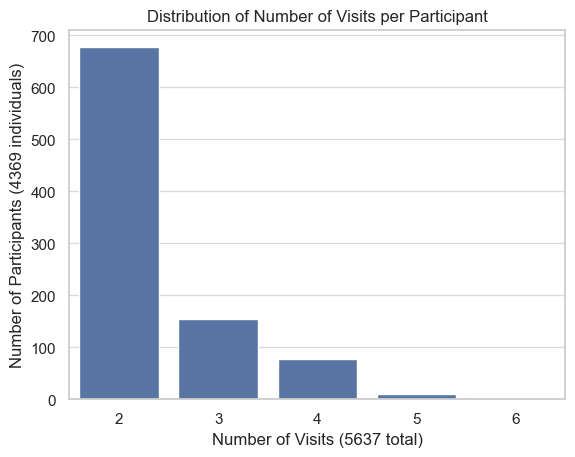

In [ ]:
sns.countplot(x='visit_count', data=duplicate_counts)
plt.title('Distribution of Number of Visits per Participant')
plt.xlabel(f"Number of Visits ({dem.shape[0]} total)")
plt.ylabel(f"Number of Participants ({dem['RID'].nunique()} individuals)")
plt.grid(axis='y', alpha=0.7)
plt.show()

Demographics table might not be the best overview of the visits. Repeat the analysis with the combined dataset, focus only on the gut metabolite cohort.

In [47]:
dem['race'].unique()

array(['5', '6', '4', '-4', '2', '7', '1', '1|5', '3', '1|4', '4|5',
       '2|5', '3|4|5', '1|7', '1|4|5', '2|4', '5|7', '9', '5|8', '8', nan],
      dtype=object)

In [48]:
# Check the unique values in each column before mapping
# Important: no NA in 'sex' and 'year_of_birth'
print(dem['sex'].unique())
print(dem['marital_status'].unique())
print(dem['retired'].unique())
print(dem['home'].unique())
print(dem['ethnicity'].unique())
print(dem['race'].unique())
print(dem['years_of_education'].unique())
print(dem['year_diagnosed_ad'].unique())
print(dem['birth_year'].unique())

[1. 2.]
[ 1.  2.  3.  5.  4.  6. nan]
[ 1.  0. nan  2.]
[ 1.  3.  2. 10.  8.  5.  7.  6.  4.  9. nan]
[ 2.  1.  3. nan]
['5' '6' '4' '-4' '2' '7' '1' '1|5' '3' '1|4' '4|5' '2|5' '3|4|5' '1|7'
 '1|4|5' '2|4' '5|7' '9' '5|8' '8' nan]
[16. 18. 10. 13. 12.  9. 17. 14. 19. 20. 15.  8.  4.  6.  7. 11. nan  5.]
[  nan 2007. 2006. 2009. 2005. 2011. 2008. 2004. 2010. 2019. 1986. 2023.
 2012. 2021. 2017. 1999. 1987. 2003. 2022. 2016. 2013. 2015. 2014. 2018.
 1985. 2020. 2024. 2025. 1980.]
[1931. 1924. 1938. 1925. 1930. 1921. 1927. 1940. 1932. 1933. 1942. 1934.
 1941. 1928. 1922. 1929. 1919. 1939. 1936. 1935. 1926. 1920. 1943. 1918.
 1945. 1923. 1946. 1916. 1944. 1917. 1949. 1937. 1951. 1950. 1948. 1947.
 1915. 1952. 1956. 1954. 1953. 1955. 1957. 1960. 1959. 1961. 1958. 1962.
 1963. 1964. 1965. 1966. 1969. 1971. 1968. 1967. 1970.]


In [49]:
# Recode variable names for clarity using the data dictionary
# at https://adni.loni.usc.edu/data-samples/data-dictionary-search
dem['sex'] = dem['sex'].map({1: 'Male', 2: 'Female', -4: 'Unknown'})
dem['marital_status'] = dem['marital_status'].map({
    1.0: 'Married',
    2.0: 'Widowed',
    3.0: 'Divorced',
    4.0: 'Never Married',
    5.0: 'Unknown',
    6.0: 'Partnership',
    -4.0:'Unknown'
}).fillna('Unknown')

dem['retired'] = dem['retired'].map({
    1.0: 'Yes', 
    0.0: 'No',
    2.0: 'Not applicable',
    -4.0: 'Unknown'
}).fillna('Unknown')

dem['home'] = dem['home'].map({
    1.0: 'House',
    2.0: 'Condo (owned)',
    3.0: 'Apartment (rented)',
    4.0: 'Mobile Home',
    5.0: 'Retirement Community',
    6.0: 'Assisted Living',
    7.0: 'Skilled Nursing Facility',
    8.0: 'Other',
    9.0: 'House',
    10.0: 'House',
    -4.0: 'Unknown'
}).fillna('Unknown')

dem['ethnicity'] = dem['ethnicity'].map({
    1.0:'Hispanic/Latino',
    2.0: 'Not Hispanic',
    3.0: 'Unknown',
    -4.0: 'Unknown'
}).fillna('Unknown')

dem['race_name'] = dem['race'].map({
    '1': 'American Indian or Alaskan Native',
    '2': 'Asian',
    '3': 'Hawaiian or Other Pacific Islander',
    '4': 'Black or African American',
    '5': 'White',
    '6': 'More than one race',
    '7': 'Unknown',
    '8': 'Native Hawaiian',
    '9': 'Other Pacific Islander',
    '-4': 'Unknown',
    '1|5': 'More than one race',
    '1|4': 'More than one race',
    '4|5': 'More than one race',
    '2|5': 'More than one race',
    '3|4|5': 'More than one race',
    '1|7': 'More than one race',
    '1|4|5': 'More than one race',
    '2|4': 'More than one race',
    '5|7': 'More than one race',
    '5|8': 'More than one race'
})

In [50]:
print(dem.shape)
dem.isnull().sum()

(5637, 15)


PHASE                    0
RID                      0
VISCODE                  0
VISCODE2                 0
VISDATE                  2
sex                      0
birth_year               0
marital_status           0
years_of_education      12
retired                  0
home                     0
year_diagnosed_ad     5110
ethnicity                0
race                     1
race_name                1
dtype: int64

In [51]:
dem[dem['race'].isna()]

,PHASE,RID,VISCODE,VISCODE2,VISDATE,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race,race_name
5584,ADNI4,10827,4_sc,sc,2025-06-11,Male,1967.0,Married,NaN,Unknown,Unknown,2025.0,Unknown,NaN,NaN


In [52]:
print(np.sort(dem['birth_year'].unique()))

[1915. 1916. 1917. 1918. 1919. 1920. 1921. 1922. 1923. 1924. 1925. 1926.
 1927. 1928. 1929. 1930. 1931. 1932. 1933. 1934. 1935. 1936. 1937. 1938.
 1939. 1940. 1941. 1942. 1943. 1944. 1945. 1946. 1947. 1948. 1949. 1950.
 1951. 1952. 1953. 1954. 1955. 1956. 1957. 1958. 1959. 1960. 1961. 1962.
 1963. 1964. 1965. 1966. 1967. 1968. 1969. 1970. 1971.]


In [53]:
# print(dem.dtypes)
# Fix data types
dem['VISDATE'] = pd.to_datetime(dem['VISDATE'])
dem['birth_year'] = dem['birth_year'].astype(int)

In [54]:
dem.head()

,PHASE,RID,VISCODE,VISCODE2,VISDATE,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race,race_name
0,ADNI1,2,sc,sc,2005-08-17,Male,1931,Married,16.0,Yes,House,NaN,Not Hispanic,5,White
1,ADNIGO,2,sc,sc,2010-09-22,Male,1931,Widowed,16.0,Yes,House,NaN,Not Hispanic,5,White
2,ADNI2,2,v06,m72,2011-09-19,Male,1931,Widowed,16.0,Yes,House,NaN,Not Hispanic,5,White
3,ADNI1,3,sc,sc,2005-08-18,Male,1924,Married,18.0,Yes,Apartment (rented),NaN,Not Hispanic,5,White
4,ADNI1,4,sc,sc,2005-08-18,Male,1938,Married,10.0,No,House,NaN,Hispanic/Latino,5,White


In [55]:
dem.isnull().sum()

PHASE                    0
RID                      0
VISCODE                  0
VISCODE2                 0
VISDATE                  2
sex                      0
birth_year               0
marital_status           0
years_of_education      12
retired                  0
home                     0
year_diagnosed_ad     5110
ethnicity                0
race                     1
race_name                1
dtype: int64

In [56]:
# dem[dem['RID'] == 2238]

In [57]:
print(dem['race_name'].unique())
dem['race_name'] = dem['race_name'].fillna('Unknown')

['White' 'More than one race' 'Black or African American' 'Unknown'
 'Asian' 'American Indian or Alaskan Native'
 'Hawaiian or Other Pacific Islander' 'Other Pacific Islander'
 'Native Hawaiian' nan]


In [58]:
dem.dtypes

PHASE                         object
RID                            int64
VISCODE                       object
VISCODE2                    category
VISDATE               datetime64[ns]
sex                           object
birth_year                     int64
marital_status                object
years_of_education           float64
retired                       object
home                          object
year_diagnosed_ad            float64
ethnicity                     object
race                          object
race_name                     object
dtype: object

In [59]:
# Fill NAs by looking up the value for each RID
dem['year_diagnosed_ad'] = dem.groupby('RID')['year_diagnosed_ad'].transform('first')

In [60]:
# Check if any RIDs still have inconsistent nulls
inconsistent = dem.groupby('RID')['year_diagnosed_ad'].apply(lambda x: x.isnull().any() and x.notnull().any()).sum()
print(f"Number of RIDs with inconsistent data: {inconsistent}")

Number of RIDs with inconsistent data: 0


In [61]:
dem.isnull().sum()

PHASE                    0
RID                      0
VISCODE                  0
VISCODE2                 0
VISDATE                  2
sex                      0
birth_year               0
marital_status           0
years_of_education      12
retired                  0
home                     0
year_diagnosed_ad     4934
ethnicity                0
race                     1
race_name                0
dtype: int64

In [62]:
# Syntax: df.loc[row_indexer, column_indexer]
dem.loc[dem['year_diagnosed_ad'].isna(), ['VISCODE2', 'RID', 'year_diagnosed_ad']].head()

,VISCODE2,RID,year_diagnosed_ad
0,sc,2,NaN
1,sc,2,NaN
2,m72,2,NaN
3,sc,3,NaN
4,sc,4,NaN


# Diagnosis

The Diagnosis dataset contains longitudinal clinical diagnosis labels (NL, MCI, AD) assigned at each ADNI visit using cognitive tests, imaging, and clinical judgement. This is the primary outcome variable, defining which participants convert from healthy or mildly impaired to Alzheimer's disease over the course of the study.

In [63]:
dx = pd.read_csv('DXSUM_16Oct2025.csv')
inspect_df(dx)

Shape: (15803, 41)
Duplicate rows: 0

--- dtypes & missing values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15803 entries, 0 to 15802
Data columns (total 41 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PHASE                 15803 non-null  object 
 1   PTID                  15803 non-null  object 
 2   RID                   15803 non-null  int64  
 3   VISCODE               15803 non-null  object 
 4   VISCODE2              15790 non-null  object 
 5   EXAMDATE              15694 non-null  object 
 6   DIAGNOSIS             15758 non-null  float64
 7   DXNORM                3868 non-null   float64
 8   DXNODEP               3868 non-null   float64
 9   DXMCI                 3868 non-null   float64
 10  DXMDES                11983 non-null  object 
 11  DXMPTR1               8730 non-null   float64
 12  DXMPTR2               8717 non-null   float64
 13  DXMPTR3               8722 non-null   float64
 14  

In [64]:
data_dict = pd.read_csv("../metadata/DATADIC_28Oct2025.csv")

In [65]:
data_dict.head()

,PHASE,CRFNAME,TBLNAME,FLDNAME,TEXT,TYPE,LENGTH,DD_CRF_VERSION,CODE,UNITS,STATUS,CODE_CHANGES,MAPPING_NOTES
0,ADNI1,ADAS-Cognitive Behavior,ADAS,PTID,Participant ID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ADNI1,ADAS-Cognitive Behavior,ADAS,RID,Participant roster ID,N,38 digits,NaN,NaN,NaN,NaN,NaN,NaN
2,ADNI1,ADAS-Cognitive Behavior,ADAS,VISCODE,Visit code,T,20 characters,NaN,NaN,NaN,NaN,NaN,NaN
3,ADNI1,ADAS-Cognitive Behavior,ADAS,EXAMDATE,Examination Date,D,10,NaN,NaN,NaN,Redacted,NaN,ADAS Item Level and Sub Scores Redacted
4,ADNI1,ADAS-Cognitive Behavior,ADAS,VISDATE,Assessment EXAMDATE when present; otherwise Re...,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
data_dict[data_dict['TBLNAME']=='DXSUM'].head(40)

,PHASE,CRFNAME,TBLNAME,FLDNAME,TEXT,TYPE,LENGTH,DD_CRF_VERSION,CODE,UNITS,STATUS,CODE_CHANGES,MAPPING_NOTES
11024,ADNI1,Diagnostic Summary,DXSUM,PTID,Participant ID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TBLNAME Mapped from PDXCONV to DXSUM
11025,ADNI1,Diagnostic Summary,DXSUM,RID,Participant roster ID,N,38 digits,NaN,NaN,NaN,NaN,NaN,TBLNAME Mapped from PDXCONV to DXSUM
11026,ADNI1,Diagnostic Summary,DXSUM,VISCODE,Visit code,T,20 characters,NaN,NaN,NaN,NaN,NaN,TBLNAME Mapped from PDXCONV to DXSUM
11027,ADNI1,Diagnostic Summary,DXSUM,EXAMDATE,Date Form Completed,D,10,NaN,NaN,NaN,NaN,NaN,TBLNAME Mapped from PDXCONV to DXSUM
11028,ADNI1,Diagnostic Summary,DXSUM,DXCURREN,1. Current Diagnosis,N,1,NaN,1=NL;2=MCI;3=AD,NaN,Mapped,NaN,"Mapped to DIAGNOSIS, excluded from final datas..."
11029,ADNI1,Diagnostic Summary,DXSUM,DXCONV,2. Has there been a conversion or reversion to...,N,1,NaN,1=Yes - Conversion;2=Yes - Reversion; 0=No,NaN,Mapped,NaN,"Mapped to DIAGNOSIS, excluded from final datas..."
11030,ADNI1,Diagnostic Summary,DXSUM,DXCONTYP,"If YES - CONVERSION, choose type",N,1,NaN,1=Normal Control to MCI; 2=Normal Control to A...,NaN,Mapped,NaN,"Mapped to DIAGNOSIS, excluded from final datas..."
11031,ADNI1,Diagnostic Summary,DXSUM,DXREV,"If YES - REVERSION, choose type",N,1,NaN,1=MCI to Normal Control; 2=AD to MCI; 3=AD to ...,NaN,Mapped,NaN,"Mapped to DIAGNOSIS, excluded from final datas..."
11032,ADNI1,Diagnostic Summary,DXSUM,DXNORM,Normal,T,20,NaN,1=Yes,NaN,NaN,NaN,TBLNAME Mapped from PDXCONV to DXSUM
11033,ADNI1,Diagnostic Summary,DXSUM,DXNODEP,Mild Depression,T,20,NaN,1=Yes,NaN,NaN,NaN,TBLNAME Mapped from PDXCONV to DXSUM


'DXCONV' and 'DXCONTY' are supposed to convey, which participants converted and to which diagnosis, but they are not in the dataset, hence I will find out the conversion and its type manually.

In [67]:
dx.columns

Index(['PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'DIAGNOSIS',
       'DXNORM', 'DXNODEP', 'DXMCI', 'DXMDES', 'DXMPTR1', 'DXMPTR2', 'DXMPTR3',
       'DXMPTR4', 'DXMPTR5', 'DXMPTR6', 'DXMDUE', 'DXMOTHET', 'DXDSEV',
       'DXDDUE', 'DXAD', 'DXAPP', 'DXAPROB', 'DXAPOSS', 'DXPARK', 'DXPDES',
       'DXPCOG', 'DXPATYP', 'DXDEP', 'DXOTHDEM', 'DXODES', 'DXCONFID', 'ID',
       'SITEID', 'USERDATE', 'USERDATE2', 'DD_CRF_VERSION_LABEL',
       'LANGUAGE_CODE', 'HAS_QC_ERROR', 'update_stamp'],
      dtype='object')

In [68]:
dx = dx[['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'DIAGNOSIS']]
dx.columns = ['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'diagnosis']

In [69]:
# Are visits already ordered?
print(dx['VISCODE2'].unique())
dx['VISCODE2'].is_monotonic_increasing

['bl' 'm06' 'm12' 'uns1' 'm36' 'm18' 'm24' 'm48' 'm60' 'm72' 'sc' 'm84'
 'm96' 'm108' 'm120' 'm132' 'm54' 'm66' 'm78' 'm126' 'm42' 'm138' 'm144'
 'm90' 'm150' 'm102' 'm156' 'm162' nan 'm30' 'm168' 'm114' 'm174' 'm180'
 'm186' 'm192' 'm198' 'm204' 'm210' 'm216' 'm222' 'm228' 'm234']


False

In [70]:
# Are there many unscheduled exams?
dx[dx['VISCODE2'] == 'uns1']

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,diagnosis
1342,ADNI1,168,uns1,uns1,2007-04-16,1.0


In [71]:
# We will count it to a m12, even if it is a m08 visit
print(dx[dx['RID'] ==  168])
dx.loc[(dx['RID'] == 168) & (dx['VISCODE2'] == 'uns1'), 'VISCODE2'] = 'm12'

      PHASE  RID VISCODE VISCODE2    EXAMDATE  diagnosis
239   ADNI1  168      bl       bl  2006-02-20        2.0
438   ADNI1  168     m06      m06  2006-08-21        1.0
1342  ADNI1  168    uns1     uns1  2007-04-16        1.0


In [72]:
dx[dx['EXAMDATE'].isna()]

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,diagnosis
10272,ADNI3,6102,sc,sc,NaN,3.0
10322,ADNI3,6024,sc,sc,NaN,1.0
10483,ADNI3,6201,sc,sc,NaN,NaN
10588,ADNI3,6245,sc,sc,NaN,NaN
10741,ADNI3,6195,bl,bl,NaN,1.0
11385,ADNI3,6599,sc,sc,NaN,1.0
11386,ADNI3,6628,sc,sc,NaN,1.0
11387,ADNI3,6636,sc,sc,NaN,1.0
11407,ADNI3,6512,bl,bl,NaN,2.0
11547,ADNI3,5294,init,m54,NaN,2.0


In [73]:
dx[dx['RID'] == 2238]

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,diagnosis
4027,ADNIGO,2238,bl,bl,2011-01-27,2.0
4235,ADNIGO,2238,m06,m06,2011-07-14,2.0
5138,ADNI2,2238,v06,m12,2012-01-18,2.0
7111,ADNI2,2238,v11,m24,2013-03-11,2.0
8395,ADNI2,2238,v21,m36,2014-02-10,2.0
9178,ADNI2,2238,v31,m48,2015-04-08,2.0
9640,ADNI2,2238,v41,m60,2016-02-24,2.0
10446,ADNI3,2238,init,m84,2018-01-22,2.0
13549,ADNI3,2238,y1,m96,2019-03-06,2.0
13583,ADNI3,2238,y2,m138,2025-03-18,2.0


In [74]:
(pd.Timestamp('2025-03-18') - pd.Timestamp('2019-03-06')).days / 30.44

72.40473061760841

In [75]:
dx.loc[(dx['RID'] == 2238) & (dx['VISCODE'] == '4_init'), 'EXAMDATE'] = pd.Timestamp('2025-05-01')
dx.loc[(dx['RID'] == 2238) & (dx['VISCODE'] == 'y2'), 'VISCODE2'] = 'm168'


In [76]:
dx = preprocess_adni_df(dx, cols_to_fill=['diagnosis'])
dx.isnull().sum()

c:\Users\katar\Code\HS25_BAT_ADNI_AD\helpers.py:200: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('RID', group_keys=False).apply(impute_group)
c:\Users\katar\Code\HS25_BAT_ADNI_AD\helpers.py:140: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('RID', group_keys=False).apply(_infer_group_dates)


PHASE         0
RID           0
VISCODE       0
VISCODE2     12
EXAMDATE     33
diagnosis    11
dtype: int64

In [77]:
# Order VISCODE2 as categorical
def generate_vis_codes():
    # Create the list with 'm' followed by multiples of 6 from 6 to 240
    visits_6m = [f"m{str(i).zfill(2)}" for i in range(6, 241, 6)]
    return visits_6m

visits_6m = generate_vis_codes()

print(visits_6m)

visit_order = ['sc', 'bl', 'scmri', 'm03'] + visits_6m

# Order VISCODE2 column
dx['VISCODE2'] = pd.Categorical(dx['VISCODE2'], categories=visit_order, ordered=True)

['m06', 'm12', 'm18', 'm24', 'm30', 'm36', 'm42', 'm48', 'm54', 'm60', 'm66', 'm72', 'm78', 'm84', 'm90', 'm96', 'm102', 'm108', 'm114', 'm120', 'm126', 'm132', 'm138', 'm144', 'm150', 'm156', 'm162', 'm168', 'm174', 'm180', 'm186', 'm192', 'm198', 'm204', 'm210', 'm216', 'm222', 'm228', 'm234', 'm240']


In [78]:
dx[dx['VISCODE2'].isna()]

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,diagnosis
4859,ADNI3,1300,y1,NaN,NaT,2
5334,ADNI3,2068,y1,NaN,NaT,2
6528,ADNI3,4100,y4,NaN,NaT,1
8077,ADNI3,4420,y3,NaN,NaT,3
11229,ADNI3,5273,y2,NaN,NaT,2
11572,ADNI3,6082,y1,NaN,NaT,1
12841,ADNI3,6514,y4,NaN,NaT,1
14300,ADNI4,7112,4_init,NaN,2023-11-29,1
14346,ADNI4,10005,4_m24,NaN,2025-09-24,2
14687,ADNI4,10175,4_m12,NaN,2025-09-24,1


In [79]:
# # Performed for all RIDs above to check for missing viscodes2
dx[dx['RID'] == 10005]

# # Find VISCODE2 value when VISCODE and PHASE have certain value
# dx[(dx['VISCODE'] == '4_init') & (dx['PHASE'] == 'ADNI4')]

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,diagnosis
14343,ADNI4,10005,4_sc,sc,2023-09-15,2
14344,ADNI4,10005,4_bl,bl,2023-10-10,2
14345,ADNI4,10005,4_m12,m12,2024-10-15,2
14346,ADNI4,10005,4_m24,NaN,2025-09-24,2


In [80]:
# Manually fix missing VISCODE2 by checking other data per RID
dx.loc[(dx['RID'] == 6082) & (dx['VISCODE2'].isna()), 'VISCODE2'] = 'm12'
dx.loc[(dx['RID'] == 2068) & (dx['VISCODE2'].isna()), 'VISCODE2'] = 'm96'
dx.loc[(dx['RID'] == 5273) & (dx['VISCODE2'].isna()), 'VISCODE2'] = 'm60'
dx.loc[(dx['RID'] == 4100) & (dx['VISCODE2'].isna()), 'VISCODE2'] = 'm126'
dx.loc[(dx['RID'] == 6514) & (dx['VISCODE2'].isna()), 'VISCODE2'] = 'm48'
dx.loc[(dx['RID'] == 4420) & (dx['VISCODE2'].isna()), 'VISCODE2'] = 'm36'
dx.loc[(dx['RID'] == 1300) & (dx['VISCODE2'].isna()), 'VISCODE2'] = 'm132'
dx.loc[(dx['RID'] == 7112) & (dx['VISCODE2'].isna()), 'VISCODE2'] = 'm12'
dx.loc[(dx['RID'] == 6970) & (dx['VISCODE2'].isna()), 'VISCODE2'] = 'm48'
dx.loc[(dx['RID'] == 10417) & (dx['VISCODE2'].isna()), 'VISCODE2'] = 'm36'
dx.loc[(dx['RID'] == 10529) & (dx['VISCODE2'].isna()), 'VISCODE2'] = 'bl'
dx.loc[(dx['RID'] == 10175) & (dx['VISCODE2'].isna()), 'VISCODE2'] = 'm12'
dx.loc[(dx['RID'] == 10005) & (dx['VISCODE2'].isna()), 'VISCODE2'] = 'm24'

In [81]:
dx[dx['VISCODE2'].isna()]

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,diagnosis


In [82]:
for col in dx.columns:
    print(f"{col}:", dx[col].unique())

PHASE: ['ADNI1' 'ADNIGO' 'ADNI2' 'ADNI3' 'ADNI4']
RID: [    2     3     4 ... 10894 10895 10898]
VISCODE: ['bl' 'm06' 'm36' 'm60' 'v06' 'v11' 'v21' 'v41' 'v51' 'init' 'm12' 'm24'
 'm18' 'm48' 'y2' '4_init' '4_m12' 'y1' 'v31' 'y4' 'm72' 'y3' 'uns1' 'y5'
 'v01' 'v03' 'v05' 'sc' '4_m24' '4_sc' '4_bl']
VISCODE2: ['bl', 'm06', 'm36', 'm60', 'm72', ..., 'm66', 'sc', 'm54', 'm42', 'm30']
Length: 41
Categories (44, object): ['sc' < 'bl' < 'scmri' < 'm03' ... 'm222' < 'm228' < 'm234' < 'm240']
EXAMDATE: <DatetimeArray>
['2005-09-29 00:00:00', '2006-03-06 00:00:00', '2008-08-27 00:00:00',
 '2010-09-27 00:00:00', '2011-09-19 00:00:00', '2012-10-04 00:00:00',
 '2013-09-23 00:00:00', '2015-10-20 00:00:00', '2016-10-03 00:00:00',
 '2017-11-01 00:00:00',
 ...
 '2025-09-18 00:00:00', '2025-07-03 00:00:00', '2025-07-11 00:00:00',
 '2025-08-08 00:00:00', '2025-06-01 00:00:00', '2025-08-19 00:00:00',
 '2025-08-02 00:00:00', '2025-08-25 00:00:00', '2025-06-25 00:00:00',
 '2025-10-10 00:00:00']
Length: 434

In [83]:
dx.isnull().sum()

PHASE         0
RID           0
VISCODE       0
VISCODE2      0
EXAMDATE     33
diagnosis    11
dtype: int64

In [84]:
dx.head(10)

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,diagnosis
0,ADNI1,2,bl,bl,2005-09-29,1
1,ADNI1,2,m06,m06,2006-03-06,1
2,ADNI1,2,m36,m36,2008-08-27,1
3,ADNIGO,2,m60,m60,2010-09-27,1
4,ADNI2,2,v06,m72,2011-09-19,1
5,ADNI2,2,v11,m84,2012-10-04,2
6,ADNI2,2,v21,m96,2013-09-23,1
7,ADNI2,2,v41,m120,2015-10-20,1
8,ADNI2,2,v51,m132,2016-10-03,2
9,ADNI3,2,init,m144,2017-11-01,2


In [85]:
dx['diagnosis'].dtype

CategoricalDtype(categories=[1, 2, 3], ordered=True, categories_dtype=int64)

In [86]:
dx.isnull().sum()

PHASE         0
RID           0
VISCODE       0
VISCODE2      0
EXAMDATE     33
diagnosis    11
dtype: int64

In [87]:
dx[dx['EXAMDATE'].isna()]

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,diagnosis
4859,ADNI3,1300,y1,m132,NaT,2
5334,ADNI3,2068,y1,m96,NaT,2
6528,ADNI3,4100,y4,m126,NaT,1
8077,ADNI3,4420,y3,m36,NaT,3
11229,ADNI3,5273,y2,m60,NaT,2
11572,ADNI3,6082,y1,m12,NaT,1
11615,ADNI3,6102,sc,sc,NaT,3
11678,ADNI3,6127,sc,sc,NaT,NaN
11864,ADNI3,6201,sc,sc,NaT,NaN
11996,ADNI3,6245,sc,sc,NaT,NaN


In [88]:
dx[dx['EXAMDATE'].dt.year >= 2026]

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,diagnosis


In [89]:
dx['EXAMDATE'].dtype

dtype('<M8[ns]')

In [90]:
dx = deduce_missing_exam_date(dx)

c:\Users\katar\Code\HS25_BAT_ADNI_AD\helpers.py:140: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('RID', group_keys=False).apply(_infer_group_dates)


In [91]:
dx.shape

(15803, 6)

In [92]:
dx['RID'].nunique()

3788

In [93]:
dx.isnull().sum()

PHASE         0
RID           0
VISCODE       0
VISCODE2      0
EXAMDATE     26
diagnosis    11
dtype: int64

In [94]:
dx.to_pickle('../interim/clean_diagnosis.pkl')

In [95]:
dem.head()

,PHASE,RID,VISCODE,VISCODE2,VISDATE,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race,race_name
0,ADNI1,2,sc,sc,2005-08-17,Male,1931,Married,16.0,Yes,House,NaN,Not Hispanic,5,White
1,ADNIGO,2,sc,sc,2010-09-22,Male,1931,Widowed,16.0,Yes,House,NaN,Not Hispanic,5,White
2,ADNI2,2,v06,m72,2011-09-19,Male,1931,Widowed,16.0,Yes,House,NaN,Not Hispanic,5,White
3,ADNI1,3,sc,sc,2005-08-18,Male,1924,Married,18.0,Yes,Apartment (rented),NaN,Not Hispanic,5,White
4,ADNI1,4,sc,sc,2005-08-18,Male,1938,Married,10.0,No,House,NaN,Hispanic/Latino,5,White


In [96]:
# dem[dem['VISDATE'].dt.year >= 2025].head()

In [97]:
dem.columns

Index(['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'sex', 'birth_year',
       'marital_status', 'years_of_education', 'retired', 'home',
       'year_diagnosed_ad', 'ethnicity', 'race', 'race_name'],
      dtype='object')

In [98]:
dx.head()

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,diagnosis
0,ADNI1,2,bl,bl,2005-09-29,1
1,ADNI1,2,m06,m06,2006-03-06,1
2,ADNI1,2,m36,m36,2008-08-27,1
3,ADNIGO,2,m60,m60,2010-09-27,1
4,ADNI2,2,v06,m72,2011-09-19,1


In [99]:
dem_dx = dx.copy()
dem_dx = pd.merge(
    dx[['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'diagnosis']],
    dem[['PHASE', 'RID', 'VISCODE', 'sex', 'birth_year', 'marital_status',
        'years_of_education', 'retired', 'home',
        'year_diagnosed_ad', 'ethnicity', 'race', 'race_name']],
    on=['RID', 'PHASE', 'VISCODE'],
    how ='left'
)

dem_dx.head(20)

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,diagnosis,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race,race_name
0,ADNI1,2,bl,bl,2005-09-29,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ADNI1,2,m06,m06,2006-03-06,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ADNI1,2,m36,m36,2008-08-27,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ADNIGO,2,m60,m60,2010-09-27,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ADNI2,2,v06,m72,2011-09-19,1,Male,1931.0,Widowed,16.0,Yes,House,NaN,Not Hispanic,5,White
5,ADNI2,2,v11,m84,2012-10-04,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ADNI2,2,v21,m96,2013-09-23,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ADNI2,2,v41,m120,2015-10-20,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,ADNI2,2,v51,m132,2016-10-03,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,ADNI3,2,init,m144,2017-11-01,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [100]:
dem_dx.shape

(15803, 16)

In [101]:
dem_dx[dem_dx['EXAMDATE'].dt.year >= 2026]

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,diagnosis,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race,race_name


In [102]:
dem_dx.isnull().sum()

PHASE                     0
RID                       0
VISCODE                   0
VISCODE2                  0
EXAMDATE                 26
diagnosis                11
sex                   11965
birth_year            11965
marital_status        11965
years_of_education    11968
retired               11965
home                  11965
year_diagnosed_ad     15286
ethnicity             11965
race                  11965
race_name             11965
dtype: int64

In [103]:
dem_dx['VISCODE2'] = pd.Categorical(
    dem_dx['VISCODE2'], 
    categories=visit_order, 
    ordered=True
)

In [104]:
dem_dx.dtypes

PHASE                         object
RID                            int64
VISCODE                       object
VISCODE2                    category
EXAMDATE              datetime64[ns]
diagnosis                   category
sex                           object
birth_year                   float64
marital_status                object
years_of_education           float64
retired                       object
home                          object
year_diagnosed_ad            float64
ethnicity                     object
race                          object
race_name                     object
dtype: object

In [105]:
# Some variable values never change
cols_to_fill = ['sex', 'birth_year', 'marital_status', 'years_of_education', 'retired', 'home', 'ethnicity', 'race', 'race_name']
dem_dx = fill_missing_with_known(dem_dx, cols_to_fill, id_col='RID', 
                                   date_col='VISCODE')

c:\Users\katar\Code\HS25_BAT_ADNI_AD\helpers.py:301: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df.groupby(id_col)[col].transform(lambda x: x.ffill().bfill())


In [106]:
dem_dx.isnull().sum()

PHASE                     0
RID                       0
VISCODE                   0
VISCODE2                  0
EXAMDATE                 26
diagnosis                11
sex                    2199
birth_year             2199
marital_status         2199
years_of_education     2203
retired                2199
home                   2199
year_diagnosed_ad     15286
ethnicity              2199
race                   2199
race_name              2199
dtype: int64

In [107]:
dem_dx['RID'].nunique()

3788

In [108]:
dem_dx[dem_dx['sex'].isna()]['RID'].nunique()

528

The demographic table records demographic details (like sex, race, and education) only at the Screening (sc) or Baseline (bl) visit, leaving them blank for follow-up visits.
Since these variables don't change, we use the firsrt available value to fill in NAs.

In [109]:
# List of columns that are missing demographic data
dem_cols = ['sex', 'birth_year', 'marital_status', 'years_of_education', 
            'retired', 'home', 'ethnicity', 'race', 'race_name']

for col in dem_cols:
    # 1. Create a lookup: Get the first non-null value available for each RID in the dem table
    lookup = dem.groupby('RID')[col].first()
    
    # 2. Fill NaNs in dem_dx by mapping the RID to our lookup values
    dem_dx[col] = dem_dx[col].fillna(dem_dx['RID'].map(lookup))

# Check the results
print(dem_dx.isna().sum())

PHASE                     0
RID                       0
VISCODE                   0
VISCODE2                  0
EXAMDATE                 26
diagnosis                11
sex                       4
birth_year                4
marital_status            4
years_of_education        8
retired                   4
home                      4
year_diagnosed_ad     15286
ethnicity                 4
race                      4
race_name                 4
dtype: int64


In [110]:
dem_dx[dem_dx['birth_year'].isna()]

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,diagnosis,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race,race_name
11293,ADNI2,5291,v01,sc,2013-08-29,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13706,ADNI3,6865,sc,sc,2020-02-03,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14679,ADNI4,10171,4_sc,sc,2024-08-29,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15777,ADNI4,10874,4_sc,sc,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [111]:
# These people only di screening, so we dont have diagnosis, nor continuous data. Drop.
dem_dx.dropna(subset=['birth_year'], inplace=True)

In [112]:
dem_dx.head()

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,diagnosis,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race,race_name
0,ADNI1,2,bl,bl,2005-09-29,1,Male,1931.0,Widowed,16.0,Yes,House,NaN,Not Hispanic,5,White
9,ADNI3,2,init,m144,2017-11-01,2,Male,1931.0,Widowed,16.0,Yes,House,NaN,Not Hispanic,5,White
1,ADNI1,2,m06,m06,2006-03-06,1,Male,1931.0,Widowed,16.0,Yes,House,NaN,Not Hispanic,5,White
2,ADNI1,2,m36,m36,2008-08-27,1,Male,1931.0,Widowed,16.0,Yes,House,NaN,Not Hispanic,5,White
3,ADNIGO,2,m60,m60,2010-09-27,1,Male,1931.0,Widowed,16.0,Yes,House,NaN,Not Hispanic,5,White


In [113]:
dem_dx.isnull().sum()

PHASE                     0
RID                       0
VISCODE                   0
VISCODE2                  0
EXAMDATE                 25
diagnosis                10
sex                       0
birth_year                0
marital_status            0
years_of_education        4
retired                   0
home                      0
year_diagnosed_ad     15282
ethnicity                 0
race                      0
race_name                 0
dtype: int64

In [114]:
dem_dx[dem_dx['diagnosis'].isna()]

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,diagnosis,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race,race_name
11678,ADNI3,6127,sc,sc,NaT,NaN,Male,1955.0,Married,16.0,No,House,2014.0,Not Hispanic,5,White
11864,ADNI3,6201,sc,sc,NaT,NaN,Male,1939.0,Married,12.0,Unknown,Unknown,NaN,Unknown,4,Black or African American
11996,ADNI3,6245,sc,sc,NaT,NaN,Male,1950.0,Divorced,14.0,Yes,Mobile Home,NaN,Not Hispanic,5,White
13708,ADNI3,6868,sc,sc,NaT,NaN,Female,1947.0,Married,16.0,Yes,House,NaN,Not Hispanic,2,Asian
13796,ADNI3,6898,sc,sc,NaT,NaN,Female,1958.0,Married,18.0,No,House,2020.0,Hispanic/Latino,5,White
13974,ADNI3,6968,sc,sc,NaT,NaN,Female,1950.0,Divorced,18.0,Yes,House,NaN,Not Hispanic,5,White
14201,ADNI3,7064,sc,sc,NaT,NaN,Male,1965.0,Married,16.0,No,House,NaN,Hispanic/Latino,5,White
14589,ADNI4,10126,4_sc,sc,NaT,NaN,Female,1962.0,Widowed,14.0,No,Apartment (rented),NaN,Not Hispanic,4,Black or African American
15064,ADNI4,10402,4_sc,sc,NaT,NaN,Male,1953.0,Married,18.0,No,House,NaN,Not Hispanic,2,Asian
15707,ADNI4,10828,4_sc,sc,NaT,NaN,Female,1953.0,Married,18.0,Yes,House,NaN,Not Hispanic,4,Black or African American


In [115]:
dem_dx.dtypes

PHASE                         object
RID                            int64
VISCODE                       object
VISCODE2                    category
EXAMDATE              datetime64[ns]
diagnosis                   category
sex                           object
birth_year                   float64
marital_status                object
years_of_education           float64
retired                       object
home                          object
year_diagnosed_ad            float64
ethnicity                     object
race                          object
race_name                     object
dtype: object

In [116]:
dem_dx['sex'] = dem_dx['sex'].astype('category')
dem_dx['birth_year'] = dem_dx['birth_year'].astype(int)

In [117]:
dem_dx[dem_dx['EXAMDATE'].isna()]

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,diagnosis,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race,race_name
11615,ADNI3,6102,sc,sc,NaT,3,Female,1954,Married,14.0,Yes,House,2013.0,Not Hispanic,5,White
11678,ADNI3,6127,sc,sc,NaT,NaN,Male,1955,Married,16.0,No,House,2014.0,Not Hispanic,5,White
11864,ADNI3,6201,sc,sc,NaT,NaN,Male,1939,Married,12.0,Unknown,Unknown,NaN,Unknown,4,Black or African American
11996,ADNI3,6245,sc,sc,NaT,NaN,Male,1950,Divorced,14.0,Yes,Mobile Home,NaN,Not Hispanic,5,White
12293,ADNI3,6338,sc,sc,NaT,1,Female,1956,Divorced,20.0,Yes,Apartment (rented),NaN,Not Hispanic,4,Black or African American
12811,ADNI3,6506,sc,sc,NaT,1,Female,1948,Married,18.0,Yes,House,NaN,Not Hispanic,5,White
13071,ADNI3,6599,sc,sc,NaT,1,Female,1939,Married,20.0,Yes,House,NaN,Not Hispanic,5,White
13142,ADNI3,6628,sc,sc,NaT,1,Female,1948,Widowed,13.0,Yes,House,NaN,Not Hispanic,5,White
13168,ADNI3,6636,sc,sc,NaT,1,Female,1940,Married,12.0,Yes,House,NaN,Not Hispanic,5,White
13646,ADNI3,6841,sc,sc,NaT,1,Female,1945,Married,14.0,Yes,Mobile Home,NaN,Not Hispanic,5,White


In [118]:
dem_dx[dem_dx['RID'] == 7092]

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,diagnosis,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race,race_name
14273,ADNI4,7092,4_init,m18,2023-10-12,1,Male,1953,Divorced,15.0,Yes,Apartment (rented),NaN,Not Hispanic,4,Black or African American
14274,ADNI4,7092,4_m12,m24,2024-04-12,1,Male,1953,Divorced,16.0,Yes,Apartment (rented),NaN,Not Hispanic,4,Black or African American
14272,ADNI3,7092,bl,bl,2022-07-12,1,Male,1953,Divorced,16.0,Yes,Apartment (rented),NaN,Not Hispanic,4,Black or African American
14271,ADNI3,7092,sc,sc,2022-06-23,1,Male,1953,Divorced,15.0,Yes,Apartment (rented),NaN,Not Hispanic,4,Black or African American


In [119]:
# Estimate the examdate based on VISCODE2 logic
dem_dx_cleaned = dem_dx.copy().groupby('RID', group_keys=False).apply(fill_exam_dates)

C:\Users\katar\AppData\Local\Temp\ipykernel_18864\2010463741.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dem_dx_cleaned = dem_dx.copy().groupby('RID', group_keys=False).apply(fill_exam_dates)


In [120]:
dem_dx_cleaned['EXAMDATE'].isnull().sum()

np.int64(0)

In [121]:
# Write clean df to .pkl to preserve dates and categories
dem_dx_cleaned.to_pickle('../interim/clean_demographics_and_diagnosis.pkl')

# Blood Serum Gut Metabolites

The serum gut metabolite dataset is one of the more compelling finds in this project: ADNI collected blood-based metabolomics data as far back as 2005, at a time when the gut-brain axis was not yet a mainstream focus in AD research. The gut microbiome shapes systemic metabolite levels that can cross the blood-brain barrier and influence neuroinflammation, amyloid clearance, and neurotransmitter synthesis. Ideally we would have direct microbiome cultures (stool metagenomics) to characterise bacterial community composition, but serum metabolite profiles might still offer a meaningful, non-invasive window into gut microbial activity and its downstream effects on brain health.

In [122]:
mtb = pd.read_csv('ADMCGUTMETABOLITESLONG_12_13_21_15Oct2025.csv')
print(list(mtb.columns))
mtb = mtb.drop(columns=['DRAWDATE', 'DRAWTIME', 'VID', 'SAMPLE_ID', 'SAMPLE_ID', 'update_stamp'])
mtb.shape

['RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'DRAWDATE', 'SAMPLE_ID', 'VID', 'DRAWTIME', 'L_HISTIDINE', 'L_LYSINE', 'L_SERINE', 'BETA_ALANINE', 'L_ALANINE', 'L_TYROSINE', 'L_ASPARAGINE', 'L_ASPARTIC_ACID', 'HIPPURIC_ACID', 'L_MALIC_ACID', 'ADIPIC_ACID', 'INDOLEACETIC_ACID', 'X3_INDOLEPROPIONIC_ACID', 'X3_METHYL_2_OXOVALERIC_ACID', 'GLYCINE', 'GLYCERIC_ACID', 'L_PROLINE', 'L_ALPHA_AMINOBUTYRIC_ACID', 'GLYCOLIC_ACID', 'P_CRESOL_SULFATE', 'PYROGLUTAMIC_ACID', 'L_VALINE', 'L_METHIONINE', 'L_LEUCINE', 'L_TRYPTOPHAN', 'CIS_ACONITIC_ACID', 'METHYLSUCCINIC_ACID', 'ISOCITRIC_ACID', 'CITRIC_ACID', 'OXOGLUTARIC_ACID', 'C1_0', 'X3_HYDROXYBUTYRIC_ACID', 'C2_0', 'C3_0', 'X3_HYDROXYISOVALERIC_ACID', 'X2_HYDROXYBUTYRIC_ACID', 'ISOBUTYRIC_ACID', 'C4_0', 'SUCCINIC_ACID', 'C5_0', 'SUBERIC_ACID', 'X__2_METHYLPENTANOIC_ACID', 'C6_0', 'C7_0', 'C8_0', 'C11_1_CIS_10', 'C10_0', 'C9_0', 'C11_0', 'C12_0', 'C13_0', 'C20_5_CIS_5_8_11_14_17', 'C15_0', 'C18_3_CIS_9_12_15', 'C18_3_CIS_6_9_12', 'C14_0', 'C22_6_CIS_4_7_1

(4228, 108)

In [123]:
mtb.replace(-4, np.nan, inplace=True)
mtb.isnull().sum()

RID                            0
VISCODE                        0
VISCODE2                       0
EXAMDATE                       0
L_HISTIDINE                    0
L_LYSINE                       0
L_SERINE                       0
BETA_ALANINE                   0
L_ALANINE                      0
L_TYROSINE                     0
L_ASPARAGINE                   0
L_ASPARTIC_ACID                0
HIPPURIC_ACID                  0
L_MALIC_ACID                   0
ADIPIC_ACID                    0
INDOLEACETIC_ACID              0
X3_INDOLEPROPIONIC_ACID        0
X3_METHYL_2_OXOVALERIC_ACID    0
GLYCINE                        0
GLYCERIC_ACID                  0
L_PROLINE                      0
L_ALPHA_AMINOBUTYRIC_ACID      0
GLYCOLIC_ACID                  0
P_CRESOL_SULFATE               0
PYROGLUTAMIC_ACID              0
L_VALINE                       0
L_METHIONINE                   0
L_LEUCINE                      0
L_TRYPTOPHAN                   0
CIS_ACONITIC_ACID              0
METHYLSUCC

In [124]:
inspect_df(mtb)

Shape: (4228, 108)
Duplicate rows: 0

--- dtypes & missing values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4228 entries, 0 to 4227
Columns: 108 entries, RID to BUDCA
dtypes: float64(104), int64(1), object(3)
memory usage: 3.5+ MB
None

--- first 5 rows ---
   RID VISCODE VISCODE2    EXAMDATE  L_HISTIDINE  L_LYSINE  L_SERINE  \
0    2     m60      m60  2010-09-22      73.1667   176.469   102.573   
1    2     v06      m72  2011-09-19      67.0264   173.763   122.532   
2    2     v11      m84  2012-09-26      73.3142   148.650   181.544   
3    2     v21      m96  2013-09-09      72.1448   191.245   200.232   
4    3      bl       bl  2005-09-12      99.4952   261.459   102.660   

   BETA_ALANINE  L_ALANINE  L_TYROSINE  L_ASPARAGINE  L_ASPARTIC_ACID  \
0       3.53337    564.544     73.3012      15.08310          7.38450   
1       4.27834    423.965     66.0988       6.94917          7.39533   
2       5.53140    456.931     74.8690      22.80730         11.95250   
3    

In [125]:
mtb[mtb['UDCA'].isna()]

,RID,VISCODE,VISCODE2,EXAMDATE,L_HISTIDINE,L_LYSINE,L_SERINE,BETA_ALANINE,L_ALANINE,L_TYROSINE,L_ASPARAGINE,L_ASPARTIC_ACID,HIPPURIC_ACID,L_MALIC_ACID,ADIPIC_ACID,INDOLEACETIC_ACID,X3_INDOLEPROPIONIC_ACID,X3_METHYL_2_OXOVALERIC_ACID,GLYCINE,GLYCERIC_ACID,L_PROLINE,L_ALPHA_AMINOBUTYRIC_ACID,GLYCOLIC_ACID,P_CRESOL_SULFATE,PYROGLUTAMIC_ACID,L_VALINE,L_METHIONINE,L_LEUCINE,L_TRYPTOPHAN,CIS_ACONITIC_ACID,METHYLSUCCINIC_ACID,ISOCITRIC_ACID,CITRIC_ACID,OXOGLUTARIC_ACID,C1_0,X3_HYDROXYBUTYRIC_ACID,C2_0,C3_0,X3_HYDROXYISOVALERIC_ACID,X2_HYDROXYBUTYRIC_ACID,ISOBUTYRIC_ACID,C4_0,SUCCINIC_ACID,C5_0,SUBERIC_ACID,X__2_METHYLPENTANOIC_ACID,C6_0,C7_0,C8_0,C11_1_CIS_10,C10_0,C9_0,C11_0,C12_0,C13_0,C20_5_CIS_5_8_11_14_17,C15_0,C18_3_CIS_9_12_15,C18_3_CIS_6_9_12,C14_0,C22_6_CIS_4_7_10_13_16_19,C20_2_CIS_11_14,C16_1_CIS_9,C20_4_CIS_5_8_11_14,C22_5_CIS_7_10_13_16_19,C22_5_CIS_4_7_10_13_16,C18_2_CIS_9_12,C17_0,C20_3_CIS_8_11_14,C17_1_CIS_10,C19_2_CIS_10_13,C16_0,C22_4_CIS_7_10_13_16,C18_1_CIS_9,C18_0,X12_KETOLCA,X3_DHCA,X7_KETOLCA,X7_DHCA,ALLOLCA,APOCA,CA,CDCA,DCA,DEHYDROLCA,GCA,GCDCA,GDCA,GHCA,GHDCA,GLCA,GUDCA,HCA,HDCA,ISOLCA,LCA,LCA_3S,MUROCA,NORCA,NORDCA,TCA,TCDCA,TDCA,TUDCA,TAMCA,UCA,UDCA,BUDCA
108,54,bl,bl,2005-12-16,65.2786,98.8404,166.454,4.01692,297.003,63.4946,14.0749,12.5072,7.49129,3.25749,0.318591,0.671633,0.724044,22.7279,547.439,3.44189,142.649,0.022172,3.05658,64.9902,58.6869,329.513,14.1186,95.6389,56.811,35.9446,0.088224,3.02087,63.7409,13.8514,231.978,587.532,35.5746,4.45585,0.144131,2.63704,0.371454,0.342927,3.99444,0.201406,0.109551,0.127615,0.516545,0.282112,2.05839,0.401344,2.54562,0.784589,0.097698,4.13732,0.277838,1.08145,2.00966,18.6156,4.55191,34.4649,9.67377,9.61472,35.8061,19.4803,2.55694,0.455123,153.046,55.3443,3.38901,4.77076,0.108006,223.772,4.78437,286.042,239.16,20.7621,0.49206,0.895999,3.87979,4.9451,3.2,33.7,18.6059,343.602,3.11259,277.303,718.712,609.568,12.5186,1.92203,21.4652,22.2904,16.0439,34.9458,12.5753,13.2756,4.63262,1.17174,4.26273,3.20336,108.313,202.676,231.454,1.1,14.3,1.72484,NaN,19.2


In [126]:
mtb[mtb['RID'] == 54]

,RID,VISCODE,VISCODE2,EXAMDATE,L_HISTIDINE,L_LYSINE,L_SERINE,BETA_ALANINE,L_ALANINE,L_TYROSINE,L_ASPARAGINE,L_ASPARTIC_ACID,HIPPURIC_ACID,L_MALIC_ACID,ADIPIC_ACID,INDOLEACETIC_ACID,X3_INDOLEPROPIONIC_ACID,X3_METHYL_2_OXOVALERIC_ACID,GLYCINE,GLYCERIC_ACID,L_PROLINE,L_ALPHA_AMINOBUTYRIC_ACID,GLYCOLIC_ACID,P_CRESOL_SULFATE,PYROGLUTAMIC_ACID,L_VALINE,L_METHIONINE,L_LEUCINE,L_TRYPTOPHAN,CIS_ACONITIC_ACID,METHYLSUCCINIC_ACID,ISOCITRIC_ACID,CITRIC_ACID,OXOGLUTARIC_ACID,C1_0,X3_HYDROXYBUTYRIC_ACID,C2_0,C3_0,X3_HYDROXYISOVALERIC_ACID,X2_HYDROXYBUTYRIC_ACID,ISOBUTYRIC_ACID,C4_0,SUCCINIC_ACID,C5_0,SUBERIC_ACID,X__2_METHYLPENTANOIC_ACID,C6_0,C7_0,C8_0,C11_1_CIS_10,C10_0,C9_0,C11_0,C12_0,C13_0,C20_5_CIS_5_8_11_14_17,C15_0,C18_3_CIS_9_12_15,C18_3_CIS_6_9_12,C14_0,C22_6_CIS_4_7_10_13_16_19,C20_2_CIS_11_14,C16_1_CIS_9,C20_4_CIS_5_8_11_14,C22_5_CIS_7_10_13_16_19,C22_5_CIS_4_7_10_13_16,C18_2_CIS_9_12,C17_0,C20_3_CIS_8_11_14,C17_1_CIS_10,C19_2_CIS_10_13,C16_0,C22_4_CIS_7_10_13_16,C18_1_CIS_9,C18_0,X12_KETOLCA,X3_DHCA,X7_KETOLCA,X7_DHCA,ALLOLCA,APOCA,CA,CDCA,DCA,DEHYDROLCA,GCA,GCDCA,GDCA,GHCA,GHDCA,GLCA,GUDCA,HCA,HDCA,ISOLCA,LCA,LCA_3S,MUROCA,NORCA,NORDCA,TCA,TCDCA,TDCA,TUDCA,TAMCA,UCA,UDCA,BUDCA
108,54,bl,bl,2005-12-16,65.2786,98.8404,166.4540,4.01692,297.003,63.4946,14.0749,12.50720,7.49129,3.25749,0.318591,0.671633,0.724044,22.7279,547.4390,3.44189,142.649,0.022172,3.05658,64.9902,58.6869,329.513,14.1186,95.6389,56.8110,35.9446,0.088224,3.02087,63.7409,13.85140,231.9780,587.532,35.5746,4.45585,0.144131,2.63704,0.371454,0.342927,3.99444,0.201406,0.109551,0.127615,0.516545,0.282112,2.058390,0.401344,2.54562,0.784589,0.097698,4.13732,0.277838,1.081450,2.009660,18.61560,4.55191,34.4649,9.67377,9.61472,35.8061,19.48030,2.55694,0.455123,153.046,55.3443,3.38901,4.77076,0.108006,223.772,4.78437,286.042,239.160,20.7621,0.492060,0.895999,3.87979,4.9451,3.2,33.7,18.6059,343.602,3.11259,277.3030,718.712,609.568,12.51860,1.922030,21.46520,22.2904,16.0439,34.9458,12.5753,13.2756,4.63262,1.17174,4.26273,3.20336,108.3130,202.6760,231.45400,1.1,14.3,1.724840,NaN,19.2
109,54,m12,m12,2007-01-09,82.0904,157.7040,134.8650,2.06120,423.419,61.7938,28.5283,11.92940,4.36070,3.21513,0.299120,0.839338,0.232132,31.2945,68.2725,3.85675,157.777,0.094100,5.85697,48.9857,62.8053,279.616,23.4752,120.0590,39.9728,39.5233,0.102948,5.85272,108.0830,7.84025,270.4920,393.156,45.1653,15.57150,0.134935,2.07796,0.705155,0.330051,5.39026,0.299439,0.027293,0.062781,0.743573,0.301073,1.760230,0.375088,1.53602,0.397471,0.121710,3.25940,0.272926,1.066220,2.475980,13.03880,3.65171,32.8161,6.95108,7.97067,26.8968,15.72000,1.96215,1.812010,131.643,87.2621,2.80560,3.84086,0.099736,264.116,3.43601,249.175,308.074,33.9023,0.808527,0.227953,3.69793,13.2656,2.1,25.6,22.5191,493.428,4.91784,300.8860,345.569,271.438,15.47080,1.850850,22.87490,26.0859,25.1675,25.8423,28.2042,25.8051,2.85938,1.00569,8.20054,6.26289,100.3280,57.5442,61.43120,0.9,14.8,0.393481,2.3,19.2
110,54,m24,m24,2007-12-28,85.4034,213.1910,99.2768,4.06476,440.001,68.1277,57.1196,5.13352,8.40033,3.64246,0.333662,1.037720,0.688749,21.8166,1399.6600,2.25731,250.319,0.255573,4.05760,47.0890,26.9564,275.781,22.8932,84.1609,43.4476,45.5956,0.114860,2.41236,74.3729,9.62898,86.5136,131.103,31.9015,3.56713,0.078813,1.22763,0.412734,0.381821,2.31726,0.493245,0.002238,0.266353,0.668075,0.191483,0.928623,0.291575,1.33629,0.375711,0.031737,2.41177,0.179009,0.417909,0.884885,7.43784,1.92724,16.7234,4.25169,4.97193,15.8787,7.35813,1.13048,0.972257,107.878,31.2596,1.31207,2.15447,0.066426,163.511,1.98263,195.084,145.568,19.0427,1.181380,2.259750,11.63940,3.0563,5.6,297.6,286.7380,577.316,3.65290,74.6668,255.688,149.083,5.09741,0.569492,6.45306,25.4261,40.2648,24.3739,16.4714,24.5679,8.17050,2.16538,7.89271,3.54511,13.4608,13.1707,9.88721,0.5,3.0,0.788903,18.8,14.1


In metabolomics, missing values often occur because the metabolite concentration is below the instrument’s limit of detection (LOD) rather than truly absent. Many papers treat these missing values as very small concentrations instead of random missing data. A widely used approach is: 

$\text{Imputed value} = \frac{\text{minimum detected value}}{2}$

In [127]:
# impute missing UDCA value
min_val = mtb['UDCA'].min(skipna=True)
mtb['UDCA'] = mtb['UDCA'].fillna(min_val / 2)

In [128]:
# post-imputation
mtb[mtb['RID'] == 54]

,RID,VISCODE,VISCODE2,EXAMDATE,L_HISTIDINE,L_LYSINE,L_SERINE,BETA_ALANINE,L_ALANINE,L_TYROSINE,L_ASPARAGINE,L_ASPARTIC_ACID,HIPPURIC_ACID,L_MALIC_ACID,ADIPIC_ACID,INDOLEACETIC_ACID,X3_INDOLEPROPIONIC_ACID,X3_METHYL_2_OXOVALERIC_ACID,GLYCINE,GLYCERIC_ACID,L_PROLINE,L_ALPHA_AMINOBUTYRIC_ACID,GLYCOLIC_ACID,P_CRESOL_SULFATE,PYROGLUTAMIC_ACID,L_VALINE,L_METHIONINE,L_LEUCINE,L_TRYPTOPHAN,CIS_ACONITIC_ACID,METHYLSUCCINIC_ACID,ISOCITRIC_ACID,CITRIC_ACID,OXOGLUTARIC_ACID,C1_0,X3_HYDROXYBUTYRIC_ACID,C2_0,C3_0,X3_HYDROXYISOVALERIC_ACID,X2_HYDROXYBUTYRIC_ACID,ISOBUTYRIC_ACID,C4_0,SUCCINIC_ACID,C5_0,SUBERIC_ACID,X__2_METHYLPENTANOIC_ACID,C6_0,C7_0,C8_0,C11_1_CIS_10,C10_0,C9_0,C11_0,C12_0,C13_0,C20_5_CIS_5_8_11_14_17,C15_0,C18_3_CIS_9_12_15,C18_3_CIS_6_9_12,C14_0,C22_6_CIS_4_7_10_13_16_19,C20_2_CIS_11_14,C16_1_CIS_9,C20_4_CIS_5_8_11_14,C22_5_CIS_7_10_13_16_19,C22_5_CIS_4_7_10_13_16,C18_2_CIS_9_12,C17_0,C20_3_CIS_8_11_14,C17_1_CIS_10,C19_2_CIS_10_13,C16_0,C22_4_CIS_7_10_13_16,C18_1_CIS_9,C18_0,X12_KETOLCA,X3_DHCA,X7_KETOLCA,X7_DHCA,ALLOLCA,APOCA,CA,CDCA,DCA,DEHYDROLCA,GCA,GCDCA,GDCA,GHCA,GHDCA,GLCA,GUDCA,HCA,HDCA,ISOLCA,LCA,LCA_3S,MUROCA,NORCA,NORDCA,TCA,TCDCA,TDCA,TUDCA,TAMCA,UCA,UDCA,BUDCA
108,54,bl,bl,2005-12-16,65.2786,98.8404,166.4540,4.01692,297.003,63.4946,14.0749,12.50720,7.49129,3.25749,0.318591,0.671633,0.724044,22.7279,547.4390,3.44189,142.649,0.022172,3.05658,64.9902,58.6869,329.513,14.1186,95.6389,56.8110,35.9446,0.088224,3.02087,63.7409,13.85140,231.9780,587.532,35.5746,4.45585,0.144131,2.63704,0.371454,0.342927,3.99444,0.201406,0.109551,0.127615,0.516545,0.282112,2.058390,0.401344,2.54562,0.784589,0.097698,4.13732,0.277838,1.081450,2.009660,18.61560,4.55191,34.4649,9.67377,9.61472,35.8061,19.48030,2.55694,0.455123,153.046,55.3443,3.38901,4.77076,0.108006,223.772,4.78437,286.042,239.160,20.7621,0.492060,0.895999,3.87979,4.9451,3.2,33.7,18.6059,343.602,3.11259,277.3030,718.712,609.568,12.51860,1.922030,21.46520,22.2904,16.0439,34.9458,12.5753,13.2756,4.63262,1.17174,4.26273,3.20336,108.3130,202.6760,231.45400,1.1,14.3,1.724840,0.05,19.2
109,54,m12,m12,2007-01-09,82.0904,157.7040,134.8650,2.06120,423.419,61.7938,28.5283,11.92940,4.36070,3.21513,0.299120,0.839338,0.232132,31.2945,68.2725,3.85675,157.777,0.094100,5.85697,48.9857,62.8053,279.616,23.4752,120.0590,39.9728,39.5233,0.102948,5.85272,108.0830,7.84025,270.4920,393.156,45.1653,15.57150,0.134935,2.07796,0.705155,0.330051,5.39026,0.299439,0.027293,0.062781,0.743573,0.301073,1.760230,0.375088,1.53602,0.397471,0.121710,3.25940,0.272926,1.066220,2.475980,13.03880,3.65171,32.8161,6.95108,7.97067,26.8968,15.72000,1.96215,1.812010,131.643,87.2621,2.80560,3.84086,0.099736,264.116,3.43601,249.175,308.074,33.9023,0.808527,0.227953,3.69793,13.2656,2.1,25.6,22.5191,493.428,4.91784,300.8860,345.569,271.438,15.47080,1.850850,22.87490,26.0859,25.1675,25.8423,28.2042,25.8051,2.85938,1.00569,8.20054,6.26289,100.3280,57.5442,61.43120,0.9,14.8,0.393481,2.30,19.2
110,54,m24,m24,2007-12-28,85.4034,213.1910,99.2768,4.06476,440.001,68.1277,57.1196,5.13352,8.40033,3.64246,0.333662,1.037720,0.688749,21.8166,1399.6600,2.25731,250.319,0.255573,4.05760,47.0890,26.9564,275.781,22.8932,84.1609,43.4476,45.5956,0.114860,2.41236,74.3729,9.62898,86.5136,131.103,31.9015,3.56713,0.078813,1.22763,0.412734,0.381821,2.31726,0.493245,0.002238,0.266353,0.668075,0.191483,0.928623,0.291575,1.33629,0.375711,0.031737,2.41177,0.179009,0.417909,0.884885,7.43784,1.92724,16.7234,4.25169,4.97193,15.8787,7.35813,1.13048,0.972257,107.878,31.2596,1.31207,2.15447,0.066426,163.511,1.98263,195.084,145.568,19.0427,1.181380,2.259750,11.63940,3.0563,5.6,297.6,286.7380,577.316,3.65290,74.6668,255.688,149.083,5.09741,0.569492,6.45306,25.4261,40.2648,24.3739,16.4714,24.5679,8.17050,2.16538,7.89271,3.54511,13.4608,13.1707,9.88721,0.5,3.0,0.788903,18.80,14.1


In [129]:
mtb[mtb['RID'] == 54][['CDCA', 'UDCA']] # CDCA can be converted into UDCA by intestinal bacteria.

,CDCA,UDCA
108,18.6059,0.05
109,22.5191,2.30
110,286.7380,18.80


The imputed value is plausible, as UDCA levels are usually lower as the CDCA levels (secondary bile acid is made from the primary bile acid by bacteria and is thus lower.)

In [130]:
mtb.columns.to_list()

['RID',
 'VISCODE',
 'VISCODE2',
 'EXAMDATE',
 'L_HISTIDINE',
 'L_LYSINE',
 'L_SERINE',
 'BETA_ALANINE',
 'L_ALANINE',
 'L_TYROSINE',
 'L_ASPARAGINE',
 'L_ASPARTIC_ACID',
 'HIPPURIC_ACID',
 'L_MALIC_ACID',
 'ADIPIC_ACID',
 'INDOLEACETIC_ACID',
 'X3_INDOLEPROPIONIC_ACID',
 'X3_METHYL_2_OXOVALERIC_ACID',
 'GLYCINE',
 'GLYCERIC_ACID',
 'L_PROLINE',
 'L_ALPHA_AMINOBUTYRIC_ACID',
 'GLYCOLIC_ACID',
 'P_CRESOL_SULFATE',
 'PYROGLUTAMIC_ACID',
 'L_VALINE',
 'L_METHIONINE',
 'L_LEUCINE',
 'L_TRYPTOPHAN',
 'CIS_ACONITIC_ACID',
 'METHYLSUCCINIC_ACID',
 'ISOCITRIC_ACID',
 'CITRIC_ACID',
 'OXOGLUTARIC_ACID',
 'C1_0',
 'X3_HYDROXYBUTYRIC_ACID',
 'C2_0',
 'C3_0',
 'X3_HYDROXYISOVALERIC_ACID',
 'X2_HYDROXYBUTYRIC_ACID',
 'ISOBUTYRIC_ACID',
 'C4_0',
 'SUCCINIC_ACID',
 'C5_0',
 'SUBERIC_ACID',
 'X__2_METHYLPENTANOIC_ACID',
 'C6_0',
 'C7_0',
 'C8_0',
 'C11_1_CIS_10',
 'C10_0',
 'C9_0',
 'C11_0',
 'C12_0',
 'C13_0',
 'C20_5_CIS_5_8_11_14_17',
 'C15_0',
 'C18_3_CIS_9_12_15',
 'C18_3_CIS_6_9_12',
 'C14_0',
 

In [131]:
visit_order[:10]

['sc', 'bl', 'scmri', 'm03', 'm06', 'm12', 'm18', 'm24', 'm30', 'm36']

In [132]:
mtb['VISCODE2'] = pd.Categorical(mtb['VISCODE2'], categories=visit_order, ordered=True)
dx['EXAMDATE'] = pd.to_datetime(dx['EXAMDATE'], errors='coerce')
mtb.dtypes

RID                               int64
VISCODE                          object
VISCODE2                       category
EXAMDATE                         object
L_HISTIDINE                     float64
L_LYSINE                        float64
L_SERINE                        float64
BETA_ALANINE                    float64
L_ALANINE                       float64
L_TYROSINE                      float64
L_ASPARAGINE                    float64
L_ASPARTIC_ACID                 float64
HIPPURIC_ACID                   float64
L_MALIC_ACID                    float64
ADIPIC_ACID                     float64
INDOLEACETIC_ACID               float64
X3_INDOLEPROPIONIC_ACID         float64
X3_METHYL_2_OXOVALERIC_ACID     float64
GLYCINE                         float64
GLYCERIC_ACID                   float64
L_PROLINE                       float64
L_ALPHA_AMINOBUTYRIC_ACID       float64
GLYCOLIC_ACID                   float64
P_CRESOL_SULFATE                float64
PYROGLUTAMIC_ACID               float64


In [133]:
dem_dx_cleaned['EXAMDATE'] = pd.to_datetime(dem_dx_cleaned['EXAMDATE'])
mtb['EXAMDATE'] = pd.to_datetime(mtb['EXAMDATE'])
dem_dx_cleaned.isnull().sum()

PHASE                     0
RID                       0
VISCODE                   0
VISCODE2                  0
EXAMDATE                  0
diagnosis                 0
sex                       0
birth_year                0
marital_status            0
years_of_education        4
retired                   0
home                      0
year_diagnosed_ad     15260
ethnicity                 0
race                      0
race_name                 0
dtype: int64

In [134]:
dem_dx_cleaned[dem_dx_cleaned['EXAMDATE'].isna()]

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,diagnosis,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race,race_name


In [135]:
# # Apply to dataset
# dem_dx_cleaned['EXAMDATE'] = dem_dx_cleaned.apply(
#     lambda row: infer_examdate(row, dem_dx_cleaned),
#     axis=1
# )

In [136]:
dem_subset = dem_dx_cleaned[
    ['EXAMDATE','RID','VISCODE2','diagnosis','sex','birth_year','year_diagnosed_ad']
]

dem_subset.isnull().sum()

EXAMDATE                 0
RID                      0
VISCODE2                 0
diagnosis                0
sex                      0
birth_year               0
year_diagnosed_ad    15260
dtype: int64

In [137]:
dem_subset = dem_subset.sort_values(['EXAMDATE','RID','VISCODE2'])
mtb = mtb.sort_values(['EXAMDATE','RID','VISCODE2'])

mtb_merged_with_dem_dx = pd.merge_asof(
    mtb,
    dem_subset,
    on='EXAMDATE',
    by=['RID','VISCODE2'],
    direction='nearest',
    tolerance=pd.Timedelta("90D")
)

In [138]:
print(len(mtb))
print(len(mtb_merged_with_dem_dx))

4228
4228


In [139]:
mtb_merged_with_dem_dx.isnull().sum()

RID                               0
VISCODE                           0
VISCODE2                          0
EXAMDATE                          0
L_HISTIDINE                       0
L_LYSINE                          0
L_SERINE                          0
BETA_ALANINE                      0
L_ALANINE                         0
L_TYROSINE                        0
L_ASPARAGINE                      0
L_ASPARTIC_ACID                   0
HIPPURIC_ACID                     0
L_MALIC_ACID                      0
ADIPIC_ACID                       0
INDOLEACETIC_ACID                 0
X3_INDOLEPROPIONIC_ACID           0
X3_METHYL_2_OXOVALERIC_ACID       0
GLYCINE                           0
GLYCERIC_ACID                     0
L_PROLINE                         0
L_ALPHA_AMINOBUTYRIC_ACID         0
GLYCOLIC_ACID                     0
P_CRESOL_SULFATE                  0
PYROGLUTAMIC_ACID                 0
L_VALINE                          0
L_METHIONINE                      0
L_LEUCINE                   

In [140]:
cols_to_fill = ['sex', 'birth_year']
mtb_merged_with_dem_dx = fill_missing_with_known(
    mtb_merged_with_dem_dx, 
    cols_to_fill, 
    id_col='RID', 
    date_col='VISCODE'
    )

In [141]:
partially_missing_rids = (
    mtb_merged_with_dem_dx[mtb_merged_with_dem_dx['diagnosis']
    .isna()]['RID']
    .astype(int)
    .unique()
    .tolist()
)

In [142]:
mtb_merged_with_dem_dx = fill_partially_missing_values(
    mtb_merged_with_dem_dx, 
    partially_missing_rids
    )

In [143]:
mtb_merged_with_dem_dx[mtb_merged_with_dem_dx['diagnosis'].isna()].head(20)

,RID,VISCODE,VISCODE2,EXAMDATE,L_HISTIDINE,L_LYSINE,L_SERINE,BETA_ALANINE,L_ALANINE,L_TYROSINE,L_ASPARAGINE,L_ASPARTIC_ACID,HIPPURIC_ACID,L_MALIC_ACID,ADIPIC_ACID,INDOLEACETIC_ACID,X3_INDOLEPROPIONIC_ACID,X3_METHYL_2_OXOVALERIC_ACID,GLYCINE,GLYCERIC_ACID,L_PROLINE,L_ALPHA_AMINOBUTYRIC_ACID,GLYCOLIC_ACID,P_CRESOL_SULFATE,PYROGLUTAMIC_ACID,L_VALINE,L_METHIONINE,L_LEUCINE,L_TRYPTOPHAN,CIS_ACONITIC_ACID,METHYLSUCCINIC_ACID,ISOCITRIC_ACID,CITRIC_ACID,OXOGLUTARIC_ACID,C1_0,X3_HYDROXYBUTYRIC_ACID,C2_0,C3_0,X3_HYDROXYISOVALERIC_ACID,X2_HYDROXYBUTYRIC_ACID,ISOBUTYRIC_ACID,C4_0,SUCCINIC_ACID,C5_0,SUBERIC_ACID,X__2_METHYLPENTANOIC_ACID,C6_0,C7_0,C8_0,C11_1_CIS_10,C10_0,C9_0,C11_0,C12_0,C13_0,C20_5_CIS_5_8_11_14_17,C15_0,C18_3_CIS_9_12_15,C18_3_CIS_6_9_12,C14_0,C22_6_CIS_4_7_10_13_16_19,C20_2_CIS_11_14,C16_1_CIS_9,C20_4_CIS_5_8_11_14,C22_5_CIS_7_10_13_16_19,C22_5_CIS_4_7_10_13_16,C18_2_CIS_9_12,C17_0,C20_3_CIS_8_11_14,C17_1_CIS_10,C19_2_CIS_10_13,C16_0,C22_4_CIS_7_10_13_16,C18_1_CIS_9,C18_0,X12_KETOLCA,X3_DHCA,X7_KETOLCA,X7_DHCA,ALLOLCA,APOCA,CA,CDCA,DCA,DEHYDROLCA,GCA,GCDCA,GDCA,GHCA,GHDCA,GLCA,GUDCA,HCA,HDCA,ISOLCA,LCA,LCA_3S,MUROCA,NORCA,NORDCA,TCA,TCDCA,TDCA,TUDCA,TAMCA,UCA,UDCA,BUDCA,diagnosis,sex,birth_year,year_diagnosed_ad
2159,55,m48,m48,2010-11-11,83.2360,288.109,134.198,4.69739,585.224,80.1219,57.66370,11.12310,11.44280,4.68051,0.246940,0.721246,3.934100,55.1394,817.6760,2.76800,318.144,0.009484,4.69942,72.5048,61.1910,412.939,31.6118,185.7260,76.8893,44.2269,0.138434,3.705490,84.3475,12.82720,89.6701,141.8580,69.9332,4.976270,0.096413,0.871442,0.417913,0.399601,2.50943,0.948021,0.022034,0.588780,0.378587,0.087038,4.668180,0.252984,4.027270,0.635603,0.045354,8.014910,0.194030,4.119420,0.958091,6.810510,1.356090,17.29690,17.82960,7.085850,18.65340,11.544600,4.258340,0.424633,102.5750,26.7961,2.153470,2.685050,0.080074,161.8860,3.597510,201.7220,124.7350,15.01650,1.10345,1.862090,4.486010,3.205000,19.8,11.2,22.35830,157.19300,8.518670,696.4470,935.007,653.12900,10.53650,3.559320,112.934000,357.55000,22.3334,13.80210,25.09310,20.97720,3.50078,0.767577,11.86880,1.710700,186.22200,297.25200,273.82200,12.4,10.5,0.381340,19.7,238.5,NaN,Male,1930.0,NaN
340,107,bl,bl,2006-08-28,86.8449,228.094,157.247,4.91095,396.282,67.6293,22.66430,8.40228,6.49722,2.05065,0.181952,0.735865,0.854601,29.0974,1565.6500,2.43020,124.133,0.388226,2.87284,12.5977,47.1948,251.001,26.7901,117.7470,67.1012,32.4542,0.063182,0.930455,37.8242,7.13942,179.8950,81.6719,24.5045,0.383883,0.062703,0.496302,0.236745,0.103121,1.58207,0.194312,0.015455,0.101039,0.211010,0.033442,0.639223,0.297515,0.815294,0.223742,0.014187,2.185220,0.102975,1.312460,0.872670,7.836980,1.890480,14.42810,7.64248,3.466400,9.80528,10.495000,1.792860,0.697704,100.3680,20.3469,1.237180,1.304890,0.086609,156.9740,1.739370,168.5360,134.8310,7.10195,1.10000,2.134880,1.030570,2.335700,2.6,37.5,38.12170,123.26400,0.880352,294.7450,971.645,358.28600,30.61870,1.779660,11.375700,423.19400,23.4412,4.11127,14.60670,4.18282,1.14246,0.077946,8.41564,1.830450,16.91790,45.18430,28.79960,2.2,5.6,0.234674,36.0,122.8,NaN,Female,1945.0,NaN
2227,112,m60,m60,2011-01-26,111.4850,291.704,150.305,4.24013,445.799,83.6207,37.62130,9.56657,2.45630,1.58915,1.421100,0.600199,1.680550,30.5716,555.5980,1.97907,149.678,0.071855,3.34051,30.3336,34.9338,245.129,31.3914,159.4130,75.8676,28.5535,0.097568,1.316050,44.7775,4.52915,140.9010,187.8510,29.7274,0.058476,0.168256,1.636850,0.670031,0.350086,3.09844,0.810906,0.028049,0.494773,0.435761,0.126696,1.041710,0.329433,0.798812,0.495391,0.033813,1.761220,0.148141,1.151350,1.012030,9.645930,2.291430,15.20530,6.86910,5.177930,13.85350,12.586700,1.772940,0.750212,115.1820,20.8568,1.558450,1.678770,0.094811,127.6060,2.163350,191.9990,135.9780,2.49852,1.50000,0.402703,0.848705,4.572580,1.2,31.4,26.52960,7.26606,0.186228,82.6990,179.337,3.65004,16.16690,0.640678,0.838834,17.96000,23.1210,1.17465,4.50679,2.06639,3.45523,0.651074,2.12870,1.500000,12.43800,18.05220,1.40000,0.5,0.8,0.081418

In [144]:
mtb_merged_with_dem_dx.sort_values(by=['RID', 'VISCODE2'])
mtb_merged_with_dem_dx['diagnosis'] = mtb_merged_with_dem_dx.groupby('RID')['diagnosis'].transform(lambda x: x.bfill())

In [145]:
missing_mtb_data = mtb_merged_with_dem_dx[mtb_merged_with_dem_dx['birth_year'].isna()]

In [146]:
missing_mtb_data

,RID,VISCODE,VISCODE2,EXAMDATE,L_HISTIDINE,L_LYSINE,L_SERINE,BETA_ALANINE,L_ALANINE,L_TYROSINE,L_ASPARAGINE,L_ASPARTIC_ACID,HIPPURIC_ACID,L_MALIC_ACID,ADIPIC_ACID,INDOLEACETIC_ACID,X3_INDOLEPROPIONIC_ACID,X3_METHYL_2_OXOVALERIC_ACID,GLYCINE,GLYCERIC_ACID,L_PROLINE,L_ALPHA_AMINOBUTYRIC_ACID,GLYCOLIC_ACID,P_CRESOL_SULFATE,PYROGLUTAMIC_ACID,L_VALINE,L_METHIONINE,L_LEUCINE,L_TRYPTOPHAN,CIS_ACONITIC_ACID,METHYLSUCCINIC_ACID,ISOCITRIC_ACID,CITRIC_ACID,OXOGLUTARIC_ACID,C1_0,X3_HYDROXYBUTYRIC_ACID,C2_0,C3_0,X3_HYDROXYISOVALERIC_ACID,X2_HYDROXYBUTYRIC_ACID,ISOBUTYRIC_ACID,C4_0,SUCCINIC_ACID,C5_0,SUBERIC_ACID,X__2_METHYLPENTANOIC_ACID,C6_0,C7_0,C8_0,C11_1_CIS_10,C10_0,C9_0,C11_0,C12_0,C13_0,C20_5_CIS_5_8_11_14_17,C15_0,C18_3_CIS_9_12_15,C18_3_CIS_6_9_12,C14_0,C22_6_CIS_4_7_10_13_16_19,C20_2_CIS_11_14,C16_1_CIS_9,C20_4_CIS_5_8_11_14,C22_5_CIS_7_10_13_16_19,C22_5_CIS_4_7_10_13_16,C18_2_CIS_9_12,C17_0,C20_3_CIS_8_11_14,C17_1_CIS_10,C19_2_CIS_10_13,C16_0,C22_4_CIS_7_10_13_16,C18_1_CIS_9,C18_0,X12_KETOLCA,X3_DHCA,X7_KETOLCA,X7_DHCA,ALLOLCA,APOCA,CA,CDCA,DCA,DEHYDROLCA,GCA,GCDCA,GDCA,GHCA,GHDCA,GLCA,GUDCA,HCA,HDCA,ISOLCA,LCA,LCA_3S,MUROCA,NORCA,NORDCA,TCA,TCDCA,TDCA,TUDCA,TAMCA,UCA,UDCA,BUDCA,diagnosis,sex,birth_year,year_diagnosed_ad
2939,2193,v06,m12,2012-05-07,111.8670,214.859,171.4140,6.68544,733.313,110.7060,38.1312,14.76030,2.822380,6.54914,0.380002,2.030050,0.723446,76.1251,671.224,4.746730,396.995,0.230808,5.61926,113.34700,91.8407,544.950,35.5857,232.6220,101.7880,85.0425,0.170624,3.111400,118.7260,16.03970,170.656,201.2370,31.0872,3.88366,0.357736,2.68037,0.539186,0.389524,4.56844,0.475473,0.038040,0.966095,0.679863,0.177663,2.54964,0.263538,2.01367,0.255625,0.079900,5.20360,0.198665,2.24516,1.202080,9.82552,2.87887,29.6484,9.78542,6.08600,23.20280,13.8655,2.100560,1.534520,113.3550,39.8672,2.98003,3.226890,0.081942,197.642,3.10164,206.926,166.097,195.74000,2.62796,10.50040,4.495120,17.416700,8.63925,18.0818,134.5780,1179.3800,10.808100,89.8334,320.080,695.8890,1.88491,1.075820,108.58500,39.2566,26.31640,12.00080,65.56820,35.74760,35.81170,1.795550,4.27680,28.15970,13.69220,43.90850,75.52260,0.853274,2.077100,1.866440,89.2907,196.2050,NaN,NaN,NaN,NaN
2259,2315,bl,bl,2011-03-21,87.7385,283.313,131.4410,6.96476,535.922,116.0440,38.7059,7.36866,13.393500,3.32998,0.473601,0.872284,0.740534,32.4883,504.664,3.467830,310.663,0.038597,5.67174,13.73370,49.1132,306.871,28.2377,144.1700,74.1876,44.8454,0.068181,3.576580,58.0919,14.98150,192.489,65.0759,29.4836,2.88506,0.196246,1.90986,0.808751,0.468848,5.27354,0.294477,0.071557,0.690183,0.539110,0.281248,1.68106,0.122260,2.78778,0.467118,0.167331,6.94189,0.494908,3.92288,1.215330,8.83216,2.75453,27.1710,9.59625,5.61995,21.84970,14.3484,2.117740,1.138340,109.3830,38.4212,2.32590,2.438790,0.083870,189.423,2.44133,201.781,221.196,10.92640,1.78509,3.10257,0.573799,1.505450,19.28410,105.7640,98.0449,265.7890,0.752553,223.2380,197.939,169.5770,6.19327,0.213947,3.45625,51.2471,14.70200,5.45486,7.86586,13.42000,1.69600,0.736395,5.52449,2.52763,60.59980,39.69870,25.84900,2.096720,10.085600,0.827130,48.6101,128.6750,NaN,NaN,NaN,NaN
2882,2315,v06,m12,2012-04-12,97.1212,167.760,90.2632,5.63681,544.436,87.6889,28.1744,5.89848,1.250610,1.66361,0.132207,1.468830,0.850309,34.9833,831.050,2.342900,212.207,0.102924,4.68691,8.25781,55.5325,301.116,24.0885,129.7010,100.0280,35.1250,0.176319,4.781790,47.2194,6.52874,207.662,46.0753,32.3481,3.49326,0.408597,2.53152,0.887045,0.667410,3.47438,0.568926,0.008778,0.822322,0.785936,0.233082,1.62652,0.580742,2.08145,0.337493,0.120651,5.96428,0.356771,3.68000,0.741786,3.24196,1.77778,15.0347,4.21671,2.80489,10.45220,10.3070,0.952393,0.579091,71.7968,15.1604,1.45077,0.988296,0.051254,159.858,1.71904,139.652,120.679,6.89463,1.45869,3.40805,0.115292,0.911105,7.17157,188.7130,219.5450,208.7110,0.960807,99.6069,309.446,136.1210,4.83601,0.278230,3.09470,46.3880,19.31300,6.46219,3.73152,6.13261,1.65725,0.349568,5.55810,1.83207,23.70990,40.25970,16.59220,1.746170,8.557130,0.696736

In [147]:
# List the columns you want to repair
cols_to_fix = ['sex', 'birth_year']

for col in cols_to_fix:
    # groupby RID and use transform to fill every row with the first valid entry found
    mtb_merged_with_dem_dx[col] = (
        mtb_merged_with_dem_dx.groupby('RID')[col]
        .transform(lambda x: x.ffill().bfill())
    )


In [148]:
mtb_merged_with_dem_dx[mtb_merged_with_dem_dx['RID'] == 2193]

,RID,VISCODE,VISCODE2,EXAMDATE,L_HISTIDINE,L_LYSINE,L_SERINE,BETA_ALANINE,L_ALANINE,L_TYROSINE,L_ASPARAGINE,L_ASPARTIC_ACID,HIPPURIC_ACID,L_MALIC_ACID,ADIPIC_ACID,INDOLEACETIC_ACID,X3_INDOLEPROPIONIC_ACID,X3_METHYL_2_OXOVALERIC_ACID,GLYCINE,GLYCERIC_ACID,L_PROLINE,L_ALPHA_AMINOBUTYRIC_ACID,GLYCOLIC_ACID,P_CRESOL_SULFATE,PYROGLUTAMIC_ACID,L_VALINE,L_METHIONINE,L_LEUCINE,L_TRYPTOPHAN,CIS_ACONITIC_ACID,METHYLSUCCINIC_ACID,ISOCITRIC_ACID,CITRIC_ACID,OXOGLUTARIC_ACID,C1_0,X3_HYDROXYBUTYRIC_ACID,C2_0,C3_0,X3_HYDROXYISOVALERIC_ACID,X2_HYDROXYBUTYRIC_ACID,ISOBUTYRIC_ACID,C4_0,SUCCINIC_ACID,C5_0,SUBERIC_ACID,X__2_METHYLPENTANOIC_ACID,C6_0,C7_0,C8_0,C11_1_CIS_10,C10_0,C9_0,C11_0,C12_0,C13_0,C20_5_CIS_5_8_11_14_17,C15_0,C18_3_CIS_9_12_15,C18_3_CIS_6_9_12,C14_0,C22_6_CIS_4_7_10_13_16_19,C20_2_CIS_11_14,C16_1_CIS_9,C20_4_CIS_5_8_11_14,C22_5_CIS_7_10_13_16_19,C22_5_CIS_4_7_10_13_16,C18_2_CIS_9_12,C17_0,C20_3_CIS_8_11_14,C17_1_CIS_10,C19_2_CIS_10_13,C16_0,C22_4_CIS_7_10_13_16,C18_1_CIS_9,C18_0,X12_KETOLCA,X3_DHCA,X7_KETOLCA,X7_DHCA,ALLOLCA,APOCA,CA,CDCA,DCA,DEHYDROLCA,GCA,GCDCA,GDCA,GHCA,GHDCA,GLCA,GUDCA,HCA,HDCA,ISOLCA,LCA,LCA_3S,MUROCA,NORCA,NORDCA,TCA,TCDCA,TDCA,TUDCA,TAMCA,UCA,UDCA,BUDCA,diagnosis,sex,birth_year,year_diagnosed_ad
2939,2193,v06,m12,2012-05-07,111.867,214.859,171.414,6.68544,733.313,110.706,38.1312,14.7603,2.82238,6.54914,0.380002,2.03005,0.723446,76.1251,671.224,4.74673,396.995,0.230808,5.61926,113.347,91.8407,544.95,35.5857,232.622,101.788,85.0425,0.170624,3.1114,118.726,16.0397,170.656,201.237,31.0872,3.88366,0.357736,2.68037,0.539186,0.389524,4.56844,0.475473,0.03804,0.966095,0.679863,0.177663,2.54964,0.263538,2.01367,0.255625,0.0799,5.2036,0.198665,2.24516,1.20208,9.82552,2.87887,29.6484,9.78542,6.086,23.2028,13.8655,2.10056,1.53452,113.355,39.8672,2.98003,3.22689,0.081942,197.642,3.10164,206.926,166.097,195.74,2.62796,10.5004,4.49512,17.4167,8.63925,18.0818,134.578,1179.38,10.8081,89.8334,320.08,695.889,1.88491,1.07582,108.585,39.2566,26.3164,12.0008,65.5682,35.7476,35.8117,1.79555,4.2768,28.1597,13.6922,43.9085,75.5226,0.853274,2.0771,1.86644,89.2907,196.205,NaN,NaN,NaN,NaN


In [149]:
# 1. Create a clean lookup table from dem_dx_cleaned
# We drop duplicates to ensure we have one unique row per RID
lookup = dem_dx_cleaned.dropna(subset=['sex', 'birth_year']).drop_duplicates('RID')
lookup_map = lookup.set_index('RID')

# 2. Fill missing 'sex'
mtb_merged_with_dem_dx['sex'] = mtb_merged_with_dem_dx['sex'].fillna(
    mtb_merged_with_dem_dx['RID'].map(lookup_map['sex'])
)

# 3. Fill missing 'birth_year'
mtb_merged_with_dem_dx['birth_year'] = mtb_merged_with_dem_dx['birth_year'].fillna(
    mtb_merged_with_dem_dx['RID'].map(lookup_map['birth_year'])
)

# 4. Final Check
missing_after = mtb_merged_with_dem_dx[['sex', 'birth_year']].isnull().sum()
print("Missing values after update:")
print(missing_after)

Missing values after update:
sex           0
birth_year    0
dtype: int64


In [150]:
mtb_merged_with_dem_dx.isnull().sum()

RID                               0
VISCODE                           0
VISCODE2                          0
EXAMDATE                          0
L_HISTIDINE                       0
L_LYSINE                          0
L_SERINE                          0
BETA_ALANINE                      0
L_ALANINE                         0
L_TYROSINE                        0
L_ASPARAGINE                      0
L_ASPARTIC_ACID                   0
HIPPURIC_ACID                     0
L_MALIC_ACID                      0
ADIPIC_ACID                       0
INDOLEACETIC_ACID                 0
X3_INDOLEPROPIONIC_ACID           0
X3_METHYL_2_OXOVALERIC_ACID       0
GLYCINE                           0
GLYCERIC_ACID                     0
L_PROLINE                         0
L_ALPHA_AMINOBUTYRIC_ACID         0
GLYCOLIC_ACID                     0
P_CRESOL_SULFATE                  0
PYROGLUTAMIC_ACID                 0
L_VALINE                          0
L_METHIONINE                      0
L_LEUCINE                   

In [151]:
mtb_merged_with_dem_dx[mtb_merged_with_dem_dx['diagnosis'].isnull()]

,RID,VISCODE,VISCODE2,EXAMDATE,L_HISTIDINE,L_LYSINE,L_SERINE,BETA_ALANINE,L_ALANINE,L_TYROSINE,L_ASPARAGINE,L_ASPARTIC_ACID,HIPPURIC_ACID,L_MALIC_ACID,ADIPIC_ACID,INDOLEACETIC_ACID,X3_INDOLEPROPIONIC_ACID,X3_METHYL_2_OXOVALERIC_ACID,GLYCINE,GLYCERIC_ACID,L_PROLINE,L_ALPHA_AMINOBUTYRIC_ACID,GLYCOLIC_ACID,P_CRESOL_SULFATE,PYROGLUTAMIC_ACID,L_VALINE,L_METHIONINE,L_LEUCINE,L_TRYPTOPHAN,CIS_ACONITIC_ACID,METHYLSUCCINIC_ACID,ISOCITRIC_ACID,CITRIC_ACID,OXOGLUTARIC_ACID,C1_0,X3_HYDROXYBUTYRIC_ACID,C2_0,C3_0,X3_HYDROXYISOVALERIC_ACID,X2_HYDROXYBUTYRIC_ACID,ISOBUTYRIC_ACID,C4_0,SUCCINIC_ACID,C5_0,SUBERIC_ACID,X__2_METHYLPENTANOIC_ACID,C6_0,C7_0,C8_0,C11_1_CIS_10,C10_0,C9_0,C11_0,C12_0,C13_0,C20_5_CIS_5_8_11_14_17,C15_0,C18_3_CIS_9_12_15,C18_3_CIS_6_9_12,C14_0,C22_6_CIS_4_7_10_13_16_19,C20_2_CIS_11_14,C16_1_CIS_9,C20_4_CIS_5_8_11_14,C22_5_CIS_7_10_13_16_19,C22_5_CIS_4_7_10_13_16,C18_2_CIS_9_12,C17_0,C20_3_CIS_8_11_14,C17_1_CIS_10,C19_2_CIS_10_13,C16_0,C22_4_CIS_7_10_13_16,C18_1_CIS_9,C18_0,X12_KETOLCA,X3_DHCA,X7_KETOLCA,X7_DHCA,ALLOLCA,APOCA,CA,CDCA,DCA,DEHYDROLCA,GCA,GCDCA,GDCA,GHCA,GHDCA,GLCA,GUDCA,HCA,HDCA,ISOLCA,LCA,LCA_3S,MUROCA,NORCA,NORDCA,TCA,TCDCA,TDCA,TUDCA,TAMCA,UCA,UDCA,BUDCA,diagnosis,sex,birth_year,year_diagnosed_ad
2939,2193,v06,m12,2012-05-07,111.8670,214.859,171.4140,6.68544,733.313,110.7060,38.1312,14.76030,2.822380,6.54914,0.380002,2.030050,0.723446,76.1251,671.224,4.746730,396.995,0.230808,5.61926,113.34700,91.8407,544.950,35.5857,232.6220,101.7880,85.0425,0.170624,3.111400,118.7260,16.03970,170.656,201.2370,31.0872,3.88366,0.357736,2.68037,0.539186,0.389524,4.56844,0.475473,0.038040,0.966095,0.679863,0.177663,2.54964,0.263538,2.01367,0.255625,0.079900,5.20360,0.198665,2.24516,1.202080,9.82552,2.87887,29.6484,9.78542,6.08600,23.20280,13.8655,2.100560,1.534520,113.3550,39.8672,2.98003,3.226890,0.081942,197.642,3.10164,206.926,166.097,195.74000,2.62796,10.50040,4.495120,17.416700,8.63925,18.0818,134.5780,1179.3800,10.808100,89.8334,320.080,695.8890,1.88491,1.075820,108.58500,39.2566,26.31640,12.00080,65.56820,35.74760,35.81170,1.795550,4.27680,28.15970,13.69220,43.90850,75.52260,0.853274,2.077100,1.866440,89.2907,196.2050,NaN,Male,1935.0,NaN
2259,2315,bl,bl,2011-03-21,87.7385,283.313,131.4410,6.96476,535.922,116.0440,38.7059,7.36866,13.393500,3.32998,0.473601,0.872284,0.740534,32.4883,504.664,3.467830,310.663,0.038597,5.67174,13.73370,49.1132,306.871,28.2377,144.1700,74.1876,44.8454,0.068181,3.576580,58.0919,14.98150,192.489,65.0759,29.4836,2.88506,0.196246,1.90986,0.808751,0.468848,5.27354,0.294477,0.071557,0.690183,0.539110,0.281248,1.68106,0.122260,2.78778,0.467118,0.167331,6.94189,0.494908,3.92288,1.215330,8.83216,2.75453,27.1710,9.59625,5.61995,21.84970,14.3484,2.117740,1.138340,109.3830,38.4212,2.32590,2.438790,0.083870,189.423,2.44133,201.781,221.196,10.92640,1.78509,3.10257,0.573799,1.505450,19.28410,105.7640,98.0449,265.7890,0.752553,223.2380,197.939,169.5770,6.19327,0.213947,3.45625,51.2471,14.70200,5.45486,7.86586,13.42000,1.69600,0.736395,5.52449,2.52763,60.59980,39.69870,25.84900,2.096720,10.085600,0.827130,48.6101,128.6750,NaN,Female,1942.0,NaN
2882,2315,v06,m12,2012-04-12,97.1212,167.760,90.2632,5.63681,544.436,87.6889,28.1744,5.89848,1.250610,1.66361,0.132207,1.468830,0.850309,34.9833,831.050,2.342900,212.207,0.102924,4.68691,8.25781,55.5325,301.116,24.0885,129.7010,100.0280,35.1250,0.176319,4.781790,47.2194,6.52874,207.662,46.0753,32.3481,3.49326,0.408597,2.53152,0.887045,0.667410,3.47438,0.568926,0.008778,0.822322,0.785936,0.233082,1.62652,0.580742,2.08145,0.337493,0.120651,5.96428,0.356771,3.68000,0.741786,3.24196,1.77778,15.0347,4.21671,2.80489,10.45220,10.3070,0.952393,0.579091,71.7968,15.1604,1.45077,0.988296,0.051254,159.858,1.71904,139.652,120.679,6.89463,1.45869,3.40805,0.115292,0.911105,7.17157,188.7130,219.5450,208.7110,0.960807,99.6069,309.446,136.1210,4.83601,0.278230,3.09470,46.3880,19.31300,6.46219,3.73152,6.13261,1.65725,0.349568,5.55810,1.83207,23.70990,40.25970,16.59220,1.746170,8.55713

In [152]:
dem_dx_cleaned = dem_dx_cleaned.sort_values(['RID', 'EXAMDATE'])

for rid in mtb_merged_with_dem_dx[mtb_merged_with_dem_dx['diagnosis'].isnull()]['RID'].unique():
    print(f"RID: {rid}")
    print(dem_dx_cleaned[dem_dx_cleaned['RID'] == rid][['EXAMDATE', 'VISCODE2', 'diagnosis']])

RID: 2193
       EXAMDATE VISCODE2 diagnosis
5626 2011-04-05       bl         2
5627 2011-09-13      m06         2
5628 2013-10-09      m12         2
RID: 2315
       EXAMDATE VISCODE2 diagnosis
5871 2011-07-15       bl         2
5872 2012-01-18      m06         2
5873 2013-10-09      m12         2
5874 2015-07-21      m48         2
5875 2016-11-04      m60         2
5876 2017-10-25      m78         1
5877 2020-10-21     m114         2
5878 2022-08-15     m132         2
RID: 2316
       EXAMDATE VISCODE2 diagnosis
5879 2011-07-15       bl         2
5880 2012-01-19      m06         2
5881 2013-10-09      m12         3
5882 2015-10-09      m48         3
RID: 4174
       EXAMDATE VISCODE2 diagnosis
6841 2011-08-11       sc         1
6842 2012-01-18       bl         1
6843 2012-03-21      m06         1
6844 2013-10-09      m12         1
RID: 4417
       EXAMDATE VISCODE2 diagnosis
8052 2011-12-06       sc         2
8053 2012-02-10       bl         2
8054 2012-08-31      m06         2
8055 

In [153]:
# 2193
target_rid = 2193
diagnosis = 2

mtb_merged_with_dem_dx.loc[
    (mtb_merged_with_dem_dx['RID'] == target_rid) & 
    (mtb_merged_with_dem_dx['diagnosis'].isnull()), 
    'diagnosis'
] = diagnosis

In [154]:
# 2315
target_rid = 2315
diagnosis = 2

mtb_merged_with_dem_dx.loc[
    (mtb_merged_with_dem_dx['RID'] == target_rid) & 
    (mtb_merged_with_dem_dx['diagnosis'].isnull()), 
    'diagnosis'
] = diagnosis

In [155]:
# 2316
target_rid = 2316
diagnosis = 2

mtb_merged_with_dem_dx.loc[
    (mtb_merged_with_dem_dx['RID'] == target_rid) & 
    (mtb_merged_with_dem_dx['diagnosis'].isnull()), 
    'diagnosis'
] = diagnosis

In [156]:
# 4174
target_rid = 4174
diagnosis = 1

mtb_merged_with_dem_dx.loc[
    (mtb_merged_with_dem_dx['RID'] == target_rid) & 
    (mtb_merged_with_dem_dx['diagnosis'].isnull()), 
    'diagnosis'
] = diagnosis

In [157]:
# 4417
target_rid = 4417
diagnosis = 2

mtb_merged_with_dem_dx.loc[
    (mtb_merged_with_dem_dx['RID'] == target_rid) & 
    (mtb_merged_with_dem_dx['diagnosis'].isnull()), 
    'diagnosis'
] = diagnosis

In [158]:
mtb_merged_with_dem_dx.isnull().sum()[mtb_merged_with_dem_dx.isnull().sum() > 0]

year_diagnosed_ad    4166
dtype: int64

In [159]:
pwd

'c:\\Users\\katar\\Code\\HS25_BAT_ADNI_AD\\data\\raw'

In [160]:
# not scaled or transformed
mtb_merged_with_dem_dx.to_pickle('../interim/clean_metabolites_and_diagnosis.pkl')

In [161]:
mtb_merged_with_dem_dx['diagnosis'].isna().sum()

np.int64(0)

In [162]:
mtb_merged_with_dem_dx[mtb_merged_with_dem_dx['RID'] == 2193]

,RID,VISCODE,VISCODE2,EXAMDATE,L_HISTIDINE,L_LYSINE,L_SERINE,BETA_ALANINE,L_ALANINE,L_TYROSINE,L_ASPARAGINE,L_ASPARTIC_ACID,HIPPURIC_ACID,L_MALIC_ACID,ADIPIC_ACID,INDOLEACETIC_ACID,X3_INDOLEPROPIONIC_ACID,X3_METHYL_2_OXOVALERIC_ACID,GLYCINE,GLYCERIC_ACID,L_PROLINE,L_ALPHA_AMINOBUTYRIC_ACID,GLYCOLIC_ACID,P_CRESOL_SULFATE,PYROGLUTAMIC_ACID,L_VALINE,L_METHIONINE,L_LEUCINE,L_TRYPTOPHAN,CIS_ACONITIC_ACID,METHYLSUCCINIC_ACID,ISOCITRIC_ACID,CITRIC_ACID,OXOGLUTARIC_ACID,C1_0,X3_HYDROXYBUTYRIC_ACID,C2_0,C3_0,X3_HYDROXYISOVALERIC_ACID,X2_HYDROXYBUTYRIC_ACID,ISOBUTYRIC_ACID,C4_0,SUCCINIC_ACID,C5_0,SUBERIC_ACID,X__2_METHYLPENTANOIC_ACID,C6_0,C7_0,C8_0,C11_1_CIS_10,C10_0,C9_0,C11_0,C12_0,C13_0,C20_5_CIS_5_8_11_14_17,C15_0,C18_3_CIS_9_12_15,C18_3_CIS_6_9_12,C14_0,C22_6_CIS_4_7_10_13_16_19,C20_2_CIS_11_14,C16_1_CIS_9,C20_4_CIS_5_8_11_14,C22_5_CIS_7_10_13_16_19,C22_5_CIS_4_7_10_13_16,C18_2_CIS_9_12,C17_0,C20_3_CIS_8_11_14,C17_1_CIS_10,C19_2_CIS_10_13,C16_0,C22_4_CIS_7_10_13_16,C18_1_CIS_9,C18_0,X12_KETOLCA,X3_DHCA,X7_KETOLCA,X7_DHCA,ALLOLCA,APOCA,CA,CDCA,DCA,DEHYDROLCA,GCA,GCDCA,GDCA,GHCA,GHDCA,GLCA,GUDCA,HCA,HDCA,ISOLCA,LCA,LCA_3S,MUROCA,NORCA,NORDCA,TCA,TCDCA,TDCA,TUDCA,TAMCA,UCA,UDCA,BUDCA,diagnosis,sex,birth_year,year_diagnosed_ad
2939,2193,v06,m12,2012-05-07,111.867,214.859,171.414,6.68544,733.313,110.706,38.1312,14.7603,2.82238,6.54914,0.380002,2.03005,0.723446,76.1251,671.224,4.74673,396.995,0.230808,5.61926,113.347,91.8407,544.95,35.5857,232.622,101.788,85.0425,0.170624,3.1114,118.726,16.0397,170.656,201.237,31.0872,3.88366,0.357736,2.68037,0.539186,0.389524,4.56844,0.475473,0.03804,0.966095,0.679863,0.177663,2.54964,0.263538,2.01367,0.255625,0.0799,5.2036,0.198665,2.24516,1.20208,9.82552,2.87887,29.6484,9.78542,6.086,23.2028,13.8655,2.10056,1.53452,113.355,39.8672,2.98003,3.22689,0.081942,197.642,3.10164,206.926,166.097,195.74,2.62796,10.5004,4.49512,17.4167,8.63925,18.0818,134.578,1179.38,10.8081,89.8334,320.08,695.889,1.88491,1.07582,108.585,39.2566,26.3164,12.0008,65.5682,35.7476,35.8117,1.79555,4.2768,28.1597,13.6922,43.9085,75.5226,0.853274,2.0771,1.86644,89.2907,196.205,2,Male,1935.0,NaN


In [163]:
mtb_merged_with_dem_dx['RID'].nunique()

1274

In [164]:
MTB_PARTICIPANT_RIDS = list(mtb_merged_with_dem_dx['RID'].unique())

# Cognitive Tests

1. ADAS-Cog:
- Alzheimer's Disease Assessment Scale - Cognitive
- assesses cognitive function in areas like memory, language, and orientation, with higher scores indicating greater dysfunction, used as an index of global cognition in response to antidementia therapies
- two versions: score from 0 to 85 (TOTAL13) or 0-70 (TOTSCORE), with higher scores indicating greater cognitive dysfunction (it's used in clinical research to track changes over time, not for a simple diagnosis)

2. CDR:
- Clinical Dementia Rating
- evaluating memory, orientation, judgment and problem solving, community affairs, home and hobbies, and personal care
- ratings from 0 to 5, where 0 means no dementia, 0.5 indicates mild cognitive impairment (MCI), and higher scores represent increasing severity

3. GDS:
- Geriatric Depression Scale
- a score of 0-4 is normal, 5-8 is mild depression, 9-11 is moderate depression, and 12-15 is severe depression

4. MMSE:
-  Mini-Mental State Exam
- 30-point test of cognitive function,
- score of 25 or higher normal, 24 or lower cognitive impairment, with scores decreasing as severity increases (18-23 indicates mild impairment, while scores of 11-20 and 0-10 suggest moderate and severe impairment)

5. MOCA:
- Montreal Cognitive Assessment
- include short-term memory, executive function, attention, focus, and more
- normal score is 26 or higher out of a possible 30

6. NEUROBAT:
- Neuropsychological Battery
- 33 neuropsychological tests to assess skills in adults with neurocognitive dysfunction
- multiple assessments, including: Logical Memory, Rey Auditory Verbal Learning Test, Clock Drawing, Clock Copying, Category Fluency, Trail Making Test, Boston Naming Test, ANART, and Digit Span. At any given visit, only a subset of those tests are administered.

    a) Logical Memory - Immediate Recall: LMSTORY, LIMMTOTAL, LIMMEND

    b) Logical Memory - Delayed Recall: LDELBEGIN, LDELTOTAL, LDELCUE.

    c) Rey Auditory Verbal Learning Test: AVTOT1, AVERR1, AVTOT2, AVERR2, AVTOT3, AVERR3, AVTOT4, AVERR4, AVTOT5, AVERR5, AVTOT6, AVERR6, AVTOTB, AVERRB, AVENDED

    d) Rey Auditory Verbal Learning Test - Delayed: AVDELBEGAN, AVDEL30MIN, AVDELERR1, AVDELTOT, AVDELERR2
    Rey verbal learning test is a useful tool for differential diagnosis in the preclinical phase of Alzheimer's disease: comparison with MCI and normal aging. (Estevez-Gonzalez et al. 2003)

    e) Clock Drawing: CLOCKCIRC, CLOCKSYM, CLOCKNUM, CLOCKHAND, CLOCKTIME, CLOCKSCOR

    f) Clock Copying: COPYCIRC, COPYSYM, COPYNUM, COPYHAND, COPYTIME, COPYSCOR

    g) Category Fluency (Vegetables ADNI1 only): CATANIMSC, CATANPERS, CATANINTR, CATVEGESC, CATVGPERS, CATVGINTR

    h) Trail Making Test: TRAASCOR, TRAAERRCOM, TRAAERROM, TRABSCOR, TRABERRCOM, TRABERROM

    i) Boston Naming Test (Spanish version provided in ADNIGO/2): BNTND, BNTSPONT, BNTSTIM, BNTCSTIM, BNTPHON, BNTCPHON, BNTTOTAL

    j) American National Adult Reading Test (ANART): ANARTND, ANARTERR

    k) Digit Span (ADNI1 only): DSPANFOR, DSPANFLTH, DSPANBAC, DSPANBLTH

In [167]:
# ADAS
ada = pd.read_csv('ADAS_15Oct2025.csv', low_memory=False)
# MOcA
moc = pd.read_csv('MOCA_16Oct2025.csv', low_memory=False)
# CDR
cdr = pd.read_csv('CDR_15Oct2025.csv', low_memory=False)
#GDSCALE
gds = pd.read_csv('GDSCALE_15Oct2025.csv', low_memory=False)
# MMSE
mms = pd.read_csv('MMSE_15Oct2025.csv', low_memory=False)
# NEUROBAT
nbt = pd.read_csv('NEUROBAT_16Oct2025.csv', low_memory=False)

## ADAS-Cog
Higher = worse   

Dementia Suggestion: A Global CDR of 1.0 or higher typically indicates dementia.   
    - 0: Healthy   
    - 0.5: "Very Mild" (Often the threshold for MCI)   
    - 1.0: Mild Dementia  
    - 2.0: Moderate Dementia  
    - 3.0: Severe Dementia   

ADAS-Cog is the "gold standard" for research sensitivity. The ADAS-Cog or CDR Sum of Boxes (CDR-SB) usually provides the "spread" needed to find that earlier signal.

In [168]:
print(ada.shape)
print(ada.columns)
ada.head()

(12834, 16)
Index(['PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'TOTSCORE',
       'TOTAL13', 'ID', 'SITEID', 'USERDATE', 'USERDATE2',
       'DD_CRF_VERSION_LABEL', 'LANGUAGE_CODE', 'HAS_QC_ERROR',
       'update_stamp'],
      dtype='object')


,PHASE,PTID,RID,VISCODE,VISCODE2,VISDATE,TOTSCORE,TOTAL13,ID,SITEID,USERDATE,USERDATE2,DD_CRF_VERSION_LABEL,LANGUAGE_CODE,HAS_QC_ERROR,update_stamp
0,ADNI1,041_S_1412,1412,m12,m12,2008-07-28,10.33,16.33,16500125,20,2014-08-20,NaN,NaN,NaN,NaN,2014-08-20 00:00:00.0
1,ADNI1,041_S_1412,1412,m06,m06,2008-02-05,10.33,19.33,16500123,20,2014-08-20,NaN,NaN,NaN,NaN,2014-08-20 00:00:00.0
2,ADNI1,041_S_1412,1412,bl,bl,2007-07-30,13.67,17.67,16500121,20,2014-08-20,NaN,NaN,NaN,NaN,2014-08-20 00:00:00.0
3,ADNI1,041_S_1411,1411,m06,m06,2008-03-25,8.00,17.00,16500119,20,2014-08-20,NaN,NaN,NaN,NaN,2014-08-20 00:00:00.0
4,ADNI1,041_S_1411,1411,bl,bl,2007-08-08,8.67,13.67,16500117,20,2014-08-20,NaN,NaN,NaN,NaN,2014-08-20 00:00:00.0


In [169]:
ada[ada['TOTSCORE'] < 0]

,PHASE,PTID,RID,VISCODE,VISCODE2,VISDATE,TOTSCORE,TOTAL13,ID,SITEID,USERDATE,USERDATE2,DD_CRF_VERSION_LABEL,LANGUAGE_CODE,HAS_QC_ERROR,update_stamp


In [170]:
# Keep only RID of our subjects
ada = ada[ada['RID'].isin(MTB_PARTICIPANT_RIDS)]

In [171]:
ada.isnull().sum()

PHASE                      0
PTID                       0
RID                        0
VISCODE                    0
VISCODE2                   7
VISDATE                    8
TOTSCORE                  89
TOTAL13                  175
ID                         0
SITEID                     0
USERDATE                   0
USERDATE2               6448
DD_CRF_VERSION_LABEL    8453
LANGUAGE_CODE           8453
HAS_QC_ERROR            8453
update_stamp               0
dtype: int64

In [172]:
ada.dtypes

PHASE                    object
PTID                     object
RID                       int64
VISCODE                  object
VISCODE2                 object
VISDATE                  object
TOTSCORE                float64
TOTAL13                 float64
ID                        int64
SITEID                    int64
USERDATE                 object
USERDATE2                object
DD_CRF_VERSION_LABEL     object
LANGUAGE_CODE            object
HAS_QC_ERROR            float64
update_stamp             object
dtype: object

In [173]:
ada.dropna(subset=['TOTSCORE'], inplace=True)

In [174]:
ada['EXAMDATE'] = ada['VISDATE']

In [175]:
ada[ada['EXAMDATE'].isna()]

,PHASE,PTID,RID,VISCODE,VISCODE2,VISDATE,TOTSCORE,TOTAL13,ID,SITEID,USERDATE,USERDATE2,DD_CRF_VERSION_LABEL,LANGUAGE_CODE,HAS_QC_ERROR,update_stamp,EXAMDATE
4286,ADNIGO,031_S_0830,830,m60,m60,NaN,11.67,20.67,848,21,2011-09-23,NaN,NaN,NaN,NaN,2025-05-15 17:03:57.0,NaN


In [176]:
ada[ada['RID'] == 830]

,PHASE,PTID,RID,VISCODE,VISCODE2,VISDATE,TOTSCORE,TOTAL13,ID,SITEID,USERDATE,USERDATE2,DD_CRF_VERSION_LABEL,LANGUAGE_CODE,HAS_QC_ERROR,update_stamp,EXAMDATE
1529,ADNI1,031_S_0830,830,m36,m36,2009-09-21,13.33,20.33,16497067,15,2014-08-20,NaN,NaN,NaN,NaN,2014-08-20 00:00:00.0,2009-09-21
1530,ADNI1,031_S_0830,830,m24,m24,2008-09-25,10.67,15.67,16497065,15,2014-08-20,NaN,NaN,NaN,NaN,2014-08-20 00:00:00.0,2008-09-25
1531,ADNI1,031_S_0830,830,m18,m18,2008-03-24,9.67,17.67,16497063,15,2014-08-20,NaN,NaN,NaN,NaN,2014-08-20 00:00:00.0,2008-03-24
1532,ADNI1,031_S_0830,830,m12,m12,2007-09-17,9.00,15.00,16497061,15,2014-08-20,NaN,NaN,NaN,NaN,2014-08-20 00:00:00.0,2007-09-17
1533,ADNI1,031_S_0830,830,m06,m06,2007-04-03,12.00,19.00,16497059,15,2014-08-20,NaN,NaN,NaN,NaN,2014-08-20 00:00:00.0,2007-04-03
1534,ADNI1,031_S_0830,830,bl,bl,2006-09-21,11.00,18.00,16497057,15,2014-08-20,NaN,NaN,NaN,NaN,2014-08-20 00:00:00.0,2006-09-21
3954,ADNIGO,031_S_0830,830,m48,m48,2010-09-23,14.00,23.00,178,21,2010-10-18,2011-02-28,NaN,NaN,NaN,2012-11-16 09:32:21.0,2010-09-23
4286,ADNIGO,031_S_0830,830,m60,m60,NaN,11.67,20.67,848,21,2011-09-23,NaN,NaN,NaN,NaN,2025-05-15 17:03:57.0,NaN
4547,ADNI2,031_S_0830,830,v06,m60,2011-09-22,11.67,20.67,412,21,2011-09-23,2011-12-08,NaN,NaN,NaN,2025-05-15 17:03:57.0,2011-09-22


In [177]:
# Create a mask for the specific row(s)
mask = (ada['RID'] == 830) & (ada['EXAMDATE'].isna())

# Drop the rows matching that mask
ada = ada.drop(ada[mask].index)

In [178]:
ada['EXAMDATE'] = pd.to_datetime(ada['EXAMDATE'])

In [179]:
ada['VISCODE2'] = pd.Categorical(ada['VISCODE2'], categories=visit_order, ordered=True)

In [180]:
ada[ada['VISCODE2'].isna()]

,PHASE,PTID,RID,VISCODE,VISCODE2,VISDATE,TOTSCORE,TOTAL13,ID,SITEID,USERDATE,USERDATE2,DD_CRF_VERSION_LABEL,LANGUAGE_CODE,HAS_QC_ERROR,update_stamp,EXAMDATE


In [181]:
ada.isnull().sum()

PHASE                      0
PTID                       0
RID                        0
VISCODE                    0
VISCODE2                   0
VISDATE                    0
TOTSCORE                   0
TOTAL13                   86
ID                         0
SITEID                     0
USERDATE                   0
USERDATE2               6415
DD_CRF_VERSION_LABEL    8368
LANGUAGE_CODE           8368
HAS_QC_ERROR            8368
update_stamp               0
EXAMDATE                   0
dtype: int64

In [182]:
ada = ada[['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'TOTSCORE']]

In [183]:
ada.dtypes

PHASE               object
RID                  int64
VISCODE             object
VISCODE2          category
EXAMDATE    datetime64[ns]
TOTSCORE           float64
dtype: object

In [184]:
# Prepare to make VISCODE2 categorical
in_visit_order = ada[ada['VISCODE2'].isin(visit_order)]['VISCODE2'].unique()
not_in_visit_order = ada[~ada['VISCODE2'].isin(visit_order)]['VISCODE2'].unique()
print(in_visit_order)
print(not_in_visit_order)

['m12', 'm06', 'bl', 'm24', 'm36', ..., 'm210', 'm216', 'm222', 'm228', 'm234']
Length: 38
Categories (44, object): ['sc' < 'bl' < 'scmri' < 'm03' ... 'm222' < 'm228' < 'm234' < 'm240']
[], Categories (44, object): ['sc' < 'bl' < 'scmri' < 'm03' ... 'm222' < 'm228' < 'm234' < 'm240']


In [185]:
ada['VISCODE2'].cat.categories.tolist()

['sc',
 'bl',
 'scmri',
 'm03',
 'm06',
 'm12',
 'm18',
 'm24',
 'm30',
 'm36',
 'm42',
 'm48',
 'm54',
 'm60',
 'm66',
 'm72',
 'm78',
 'm84',
 'm90',
 'm96',
 'm102',
 'm108',
 'm114',
 'm120',
 'm126',
 'm132',
 'm138',
 'm144',
 'm150',
 'm156',
 'm162',
 'm168',
 'm174',
 'm180',
 'm186',
 'm192',
 'm198',
 'm204',
 'm210',
 'm216',
 'm222',
 'm228',
 'm234',
 'm240']

In [186]:
# Over all phases?
ada['PHASE'].unique()

array(['ADNI1', 'ADNIGO', 'ADNI2', 'ADNI3', 'ADNI4'], dtype=object)

In [187]:
ada.isnull().sum()

PHASE       0
RID         0
VISCODE     0
VISCODE2    0
EXAMDATE    0
TOTSCORE    0
dtype: int64

In [188]:
dem_dx.columns

Index(['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'diagnosis', 'sex',
       'birth_year', 'marital_status', 'years_of_education', 'retired', 'home',
       'year_diagnosed_ad', 'ethnicity', 'race', 'race_name'],
      dtype='object')

In [189]:
subset = dem_dx[['PHASE', 'RID', 'VISCODE2', 'diagnosis', 'sex','birth_year']]

ada_dx_dem = pd.merge(
    ada,
    subset,
    on=['RID', 'VISCODE2', 'PHASE'],
    how='left'
)

In [190]:
ada_dx_dem.isnull().sum()

PHASE          0
RID            0
VISCODE        0
VISCODE2       0
EXAMDATE       0
TOTSCORE       0
diagnosis     16
sex           16
birth_year    16
dtype: int64

In [191]:
ada_dx_dem.shape

(8476, 9)

In [192]:
ada_dx_dem.columns

Index(['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'TOTSCORE',
       'diagnosis', 'sex', 'birth_year'],
      dtype='object')

In [193]:
partially_missing_rids = (
    ada_dx_dem[ada_dx_dem['diagnosis']
    .isna()]['RID']
    .astype(int)
    .unique()
    .tolist()
)

In [194]:
ada_dx_dem = fill_partially_missing_values(
    ada_dx_dem, 
    partially_missing_rids
    )

In [195]:


cols_to_fill = ['sex', 'birth_year']
ada_dx_dem = fill_missing_with_known(
    ada_dx_dem, 
    cols_to_fill, 
    id_col='RID', 
    date_col='EXAMDATE'
    )

In [196]:
ada_dx_dem.isnull().sum()

PHASE         0
RID           0
VISCODE       0
VISCODE2      0
EXAMDATE      0
TOTSCORE      0
diagnosis     1
sex           0
birth_year    0
dtype: int64

In [197]:
ada_dx_dem[ada_dx_dem['diagnosis'].isna()]

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,TOTSCORE,diagnosis,sex,birth_year
7563,ADNI2,4198,tau,m60,2016-09-20,7.0,NaN,Female,1933.0


In [198]:
ada_dx_dem[ada_dx_dem['RID'] == 4198]

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,TOTSCORE,diagnosis,sex,birth_year
4312,ADNI2,4198,v03,bl,2011-09-20,3.33,1,Female,1933.0
4829,ADNI2,4198,v05,m06,2012-03-28,3.67,1,Female,1933.0
5388,ADNI2,4198,v11,m12,2012-09-06,4.33,1,Female,1933.0
6239,ADNI2,4198,v21,m24,2013-09-24,3.33,1,Female,1933.0
7230,ADNI2,4198,v41,m48,2015-09-15,7.33,1,Female,1933.0
7563,ADNI2,4198,tau,m60,2016-09-20,7.00,NaN,Female,1933.0
7772,ADNI3,4198,init,m72,2017-09-29,11.00,2,Female,1933.0
7887,ADNI3,4198,y1,m84,2018-11-08,12.67,2,Female,1933.0


In [199]:
ada_dx_dem = ada_dx_dem.fillna({'diagnosis': 1})

In [200]:
# Write clean df to .pkl to preserve dates and categories
ada_dx_dem.to_pickle('../interim/clean_adas_dem_dx.pkl')

## Mini Mental State Examination (MMSE) - available through all phases

24-30 = healthy

20–23: Mild Impairment   
10–19: Moderate Impairment   
<10: Severe Impairment   

In [201]:
# Keep only RID of our subjects
mms = mms[mms['RID'].isin(MTB_PARTICIPANT_RIDS)]

In [202]:
print(mms.shape)
print(mms.dtypes)
mms.head()

(8573, 58)
PHASE                    object
PTID                     object
RID                       int64
VISCODE                  object
VISCODE2                 object
VISDATE                  object
DONE                    float64
NDREASON                float64
SOURCE                  float64
MMDATE                  float64
MMYEAR                  float64
MMMONTH                 float64
MMDAY                   float64
MMSEASON                float64
MMHOSPIT                float64
MMFLOOR                 float64
MMCITY                  float64
MMAREA                  float64
MMSTATE                 float64
WORDLIST                float64
WORD1                   float64
WORD2                   float64
WORD3                   float64
MMTRIALS                float64
MMD                     float64
MML                     float64
MMR                     float64
MMO                     float64
MMW                     float64
MMLTR1                   object
MMLTR2                   obje

,PHASE,PTID,RID,VISCODE,VISCODE2,VISDATE,DONE,NDREASON,SOURCE,MMDATE,MMYEAR,MMMONTH,MMDAY,MMSEASON,MMHOSPIT,MMFLOOR,MMCITY,MMAREA,MMSTATE,WORDLIST,WORD1,WORD2,WORD3,MMTRIALS,MMD,MML,MMR,MMO,MMW,MMLTR1,MMLTR2,MMLTR3,MMLTR4,MMLTR5,MMLTR6,MMLTR7,WORLDSCORE,WORD1DL,WORD2DL,WORD3DL,MMWATCH,MMPENCIL,MMREPEAT,MMHAND,MMFOLD,MMONFLR,MMREAD,MMWRITE,MMDRAW,MMSCORE,ID,SITEID,USERDATE,USERDATE2,DD_CRF_VERSION_LABEL,LANGUAGE_CODE,HAS_QC_ERROR,update_stamp
0,ADNI1,011_S_0002,2,sc,sc,2005-08-17,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,28.0,10,107,2005-08-17,NaN,NaN,NaN,NaN,2024-08-22 07:18:34.0
2,ADNI1,011_S_0003,3,sc,sc,2005-08-18,NaN,NaN,NaN,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,20.0,14,107,2005-08-18,NaN,NaN,NaN,NaN,2024-08-22 07:18:34.0
3,ADNI1,022_S_0004,4,sc,sc,2005-08-18,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,27.0,16,10,2005-08-18,NaN,NaN,NaN,NaN,2024-08-22 07:18:34.0
4,ADNI1,011_S_0005,5,sc,sc,2005-08-23,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,29.0,18,107,2005-08-23,NaN,NaN,NaN,NaN,2024-08-22 07:18:34.0
6,ADNI1,022_S_0007,7,sc,sc,2005-08-25,NaN,NaN,NaN,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,20.0,22,10,2005-08-29,NaN,NaN,NaN,NaN,2024-08-22 07:18:34.0


In [203]:
mms.isnull().sum()

PHASE                      0
PTID                       0
RID                        0
VISCODE                    0
VISCODE2                   7
VISDATE                    9
DONE                    7654
NDREASON                8543
SOURCE                  8308
MMDATE                    56
MMYEAR                    55
MMMONTH                   56
MMDAY                     55
MMSEASON                  55
MMHOSPIT                  55
MMFLOOR                   55
MMCITY                    55
MMAREA                    55
MMSTATE                   55
WORDLIST                4189
WORD1                     57
WORD2                     57
WORD3                     57
MMTRIALS                 936
MMD                      946
MML                      946
MMR                      946
MMO                      946
MMW                      946
MMLTR1                  7690
MMLTR2                  7690
MMLTR3                  7691
MMLTR4                  7696
MMLTR5                  7741
MMLTR6        

In [204]:
mms[mms['MMSCORE'].isna()].head()

,PHASE,PTID,RID,VISCODE,VISCODE2,VISDATE,DONE,NDREASON,SOURCE,MMDATE,MMYEAR,MMMONTH,MMDAY,MMSEASON,MMHOSPIT,MMFLOOR,MMCITY,MMAREA,MMSTATE,WORDLIST,WORD1,WORD2,WORD3,MMTRIALS,MMD,MML,MMR,MMO,MMW,MMLTR1,MMLTR2,MMLTR3,MMLTR4,MMLTR5,MMLTR6,MMLTR7,WORLDSCORE,WORD1DL,WORD2DL,WORD3DL,MMWATCH,MMPENCIL,MMREPEAT,MMHAND,MMFOLD,MMONFLR,MMREAD,MMWRITE,MMDRAW,MMSCORE,ID,SITEID,USERDATE,USERDATE2,DD_CRF_VERSION_LABEL,LANGUAGE_CODE,HAS_QC_ERROR,update_stamp
4635,ADNIGO,141_S_1052,1052,m48,m48,2010-10-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,766,56,2011-01-13,NaN,NaN,NaN,NaN,2013-03-22 15:23:03.0
4783,ADNIGO,141_S_1378,1378,m36,m36,2010-10-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1062,56,2011-04-13,NaN,NaN,NaN,NaN,2013-03-22 15:23:03.0
4848,ADNIGO,128_S_0135,135,m48,m48,2010-09-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1192,48,2011-05-20,NaN,NaN,NaN,NaN,2013-03-22 15:23:03.0
4964,ADNIGO,003_S_0907,907,m48,m48,2010-12-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1428,2,2012-01-12,NaN,NaN,NaN,NaN,2013-03-22 15:23:03.0
4966,ADNIGO,127_S_0622,622,m60,m60,2011-07-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1472,47,2012-03-26,NaN,NaN,NaN,NaN,2013-03-22 15:23:03.0


In [205]:
mms.dropna(subset=['MMSCORE'], inplace=True)

In [206]:
# VISDATE dtype
mms['VISDATE'] = pd.to_datetime(mms['VISDATE'], errors='coerce')

# Order VISCODE2 column
mms = mms.copy()  # Ensure it’s a new copy
mms['VISCODE2'] = pd.Categorical(mms['VISCODE2'], categories=visit_order, ordered=True)

In [207]:
print(mms.columns)

mms = mms[['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'MMDATE', 
            'MMYEAR', 'MMMONTH', 'MMDAY', 'MMSEASON', 'MMHOSPIT', 'MMFLOOR', 
            'MMCITY', 'MMAREA', 'MMSTATE', 'WORD1', 'WORD2', 
            'WORD3', 'MMD', 'MML', 'MMR', 'MMO', 'MMW', 'MMLTR1', 
            'MMLTR2', 'MMLTR3', 'MMLTR4', 'MMLTR5', 'MMLTR6', 'MMLTR7', 
            'WORLDSCORE', 'WORD1DL', 'WORD2DL', 'WORD3DL', 'MMWATCH', 
            'MMPENCIL', 'MMREPEAT', 'MMHAND', 'MMFOLD', 'MMONFLR', 'MMREAD', 
            'MMWRITE', 'MMDRAW', 'MMSCORE']]

Index(['PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'DONE',
       'NDREASON', 'SOURCE', 'MMDATE', 'MMYEAR', 'MMMONTH', 'MMDAY',
       'MMSEASON', 'MMHOSPIT', 'MMFLOOR', 'MMCITY', 'MMAREA', 'MMSTATE',
       'WORDLIST', 'WORD1', 'WORD2', 'WORD3', 'MMTRIALS', 'MMD', 'MML', 'MMR',
       'MMO', 'MMW', 'MMLTR1', 'MMLTR2', 'MMLTR3', 'MMLTR4', 'MMLTR5',
       'MMLTR6', 'MMLTR7', 'WORLDSCORE', 'WORD1DL', 'WORD2DL', 'WORD3DL',
       'MMWATCH', 'MMPENCIL', 'MMREPEAT', 'MMHAND', 'MMFOLD', 'MMONFLR',
       'MMREAD', 'MMWRITE', 'MMDRAW', 'MMSCORE', 'ID', 'SITEID', 'USERDATE',
       'USERDATE2', 'DD_CRF_VERSION_LABEL', 'LANGUAGE_CODE', 'HAS_QC_ERROR',
       'update_stamp'],
      dtype='object')


In [208]:
mms.shape

(8524, 44)

In [209]:
mms.isna().sum()

PHASE            0
RID              0
VISCODE          0
VISCODE2         0
VISDATE          2
MMDATE          10
MMYEAR           9
MMMONTH         10
MMDAY            9
MMSEASON         9
MMHOSPIT         9
MMFLOOR          9
MMCITY           9
MMAREA           9
MMSTATE          9
WORD1           10
WORD2           10
WORD3           10
MMD            899
MML            899
MMR            899
MMO            899
MMW            899
MMLTR1        7641
MMLTR2        7641
MMLTR3        7642
MMLTR4        7647
MMLTR5        7692
MMLTR6        8502
MMLTR7        8505
WORLDSCORE    7640
WORD1DL          9
WORD2DL          9
WORD3DL          9
MMWATCH          9
MMPENCIL        10
MMREPEAT        10
MMHAND          11
MMFOLD          11
MMONFLR         11
MMREAD          11
MMWRITE         10
MMDRAW          12
MMSCORE          0
dtype: int64

In [210]:
mms['EXAMDATE'] = mms['VISDATE']

In [211]:
mms_clean = mms[['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'MMSCORE']]
mms_clean.isna().sum()

PHASE       0
RID         0
VISCODE     0
VISCODE2    0
EXAMDATE    2
MMSCORE     0
dtype: int64

In [212]:
mms_clean[mms_clean['EXAMDATE'].isna()]

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,MMSCORE
4927,ADNIGO,830,m60,m60,NaT,25.0
9830,ADNI2,4555,v31,m36,NaT,30.0


In [213]:
mms_clean[mms_clean['RID'] == 4555]

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,MMSCORE
5812,ADNI2,4555,v01,sc,2012-02-17,28.0
6942,ADNI2,4555,v05,m06,2012-11-07,30.0
7654,ADNI2,4555,v11,m12,2013-05-14,30.0
8669,ADNI2,4555,v21,m24,2014-03-20,30.0
9830,ADNI2,4555,v31,m36,NaT,30.0
10036,ADNI2,4555,v41,m48,2016-04-22,30.0


In [214]:
mask = (mms_clean['RID'] == 4555) & (mms_clean['EXAMDATE'].isna())
mms_clean.loc[mask, 'EXAMDATE'] = pd.to_datetime('2015-03-20')

In [215]:
mms_clean.dropna(subset=['EXAMDATE'], inplace=True)

C:\Users\katar\AppData\Local\Temp\ipykernel_18864\871860368.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mms_clean.dropna(subset=['EXAMDATE'], inplace=True)


In [216]:
# Drop those who failed screening
mms_clean = mms_clean[mms_clean['VISCODE'] != 'f']
mms_clean.shape

(8523, 6)

In [217]:
mms_dem_dx = pd.merge(
    mms_clean,
    subset,
    on=['PHASE', 'VISCODE2', 'RID'],
    how='left'
) 

In [218]:
mms_dem_dx.head()

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,MMSCORE,diagnosis,sex,birth_year
0,ADNI1,2,sc,sc,2005-08-17,28.0,NaN,NaN,NaN
1,ADNI1,3,sc,sc,2005-08-18,20.0,NaN,NaN,NaN
2,ADNI1,4,sc,sc,2005-08-18,27.0,NaN,NaN,NaN
3,ADNI1,5,sc,sc,2005-08-23,29.0,NaN,NaN,NaN
4,ADNI1,7,sc,sc,2005-08-25,20.0,NaN,NaN,NaN


In [219]:
mms_dem_dx.isnull().sum()

PHASE           0
RID             0
VISCODE         0
VISCODE2        0
EXAMDATE        0
MMSCORE         0
diagnosis     862
sex           862
birth_year    862
dtype: int64

In [220]:
partially_missing_rids = (
    mms_dem_dx[mms_dem_dx['diagnosis']
    .isna()]['RID']
    .astype(int)
    .unique()
    .tolist()
)

mms_dem_dx = fill_partially_missing_values(
    mms_dem_dx, 
    partially_missing_rids
    )

cols_to_fill = ['sex', 'birth_year']
mms_dem_dx = fill_missing_with_known(
    mms_dem_dx, 
    cols_to_fill, 
    id_col='RID', 
    date_col='EXAMDATE'
    )

In [221]:
mms_dem_dx.dtypes

PHASE                 object
RID                    int64
VISCODE               object
VISCODE2            category
EXAMDATE      datetime64[ns]
MMSCORE              float64
diagnosis           category
sex                 category
birth_year           float64
dtype: object

In [222]:
mms_dem_dx = mms_dem_dx.sort_values(by=['RID', 'EXAMDATE'])
mms_dem_dx['diagnosis'] = mms_dem_dx.groupby('RID')['diagnosis'].ffill()

In [223]:
mms_clean.to_pickle('../interim/clean_mmse_dem_dx.pkl')

## Clinical Dementia Rating (CDR)

0 = healthy

Global Clinical Dementia Rating (CDR) is a key 5-point scale (0–3) used to stage dementia severity:   
(0=none, 0.5=questionable, 1=mild, 2=moderate, 3=severe).

In [224]:
%cd data/raw

[WinError 3] The system cannot find the path specified: 'data/raw'
c:\Users\katar\Code\HS25_BAT_ADNI_AD


In [225]:
# CDR
cdr = pd.read_csv('CDR_15Oct2025.csv', low_memory=False)

In [226]:
# Keep only participants who have metabolites
cdr = cdr[cdr['RID'].isin(MTB_PARTICIPANT_RIDS)]

In [227]:
cdr.head()

,PHASE,PTID,RID,VISCODE,VISCODE2,VISDATE,CDSOURCE,CDVERSION,SPID,CDMEMORY,CDORIENT,CDJUDGE,CDCOMMUN,CDHOME,CDCARE,CDGLOBAL,CDRSB,ID,SITEID,USERDATE,USERDATE2,DD_CRF_VERSION_LABEL,LANGUAGE_CODE,HAS_QC_ERROR,update_stamp
0,ADNI1,011_S_0002,2,sc,sc,2005-08-17,1.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,107,2005-08-17,2009-10-05,NaN,NaN,NaN,2009-10-05 00:00:00.0
1,ADNI1,011_S_0003,3,sc,sc,2005-08-18,1.0,NaN,NaN,1.0,1.0,1.0,1.0,0.5,0.0,1.0,4.5,10,107,2005-08-18,2009-10-05,NaN,NaN,NaN,2009-10-05 00:00:00.0
2,ADNI1,022_S_0004,4,sc,sc,2005-08-18,1.0,NaN,NaN,0.5,0.0,0.5,0.0,0.0,0.0,0.5,1.0,12,10,2005-08-18,2009-10-05,NaN,NaN,NaN,2009-10-05 00:00:00.0
3,ADNI1,011_S_0005,5,sc,sc,2005-08-23,1.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14,107,2005-08-23,2009-10-05,NaN,NaN,NaN,2009-10-05 00:00:00.0
4,ADNI1,022_S_0007,7,sc,sc,2005-08-25,1.0,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,6.0,16,10,2005-08-25,2009-10-05,NaN,NaN,NaN,2009-10-05 00:00:00.0


In [228]:
cdr['CDGLOBAL'].unique()

array([ 0. ,  1. ,  0.5, -1. ,  2. ,  3. ,  nan])

In [229]:
# -1 is NaN
cdr['CDGLOBAL'] = cdr['CDGLOBAL'].replace(-1, np.nan)

In [230]:
cdr.isnull().sum()

PHASE                      0
PTID                       0
RID                        0
VISCODE                    0
VISCODE2                   3
VISDATE                    4
CDSOURCE                  83
CDVERSION               4238
SPID                    7843
CDMEMORY                  36
CDORIENT                  36
CDJUDGE                   36
CDCOMMUN                  37
CDHOME                    37
CDCARE                    36
CDGLOBAL                 131
CDRSB                    130
ID                         0
SITEID                     0
USERDATE                   0
USERDATE2               3928
DD_CRF_VERSION_LABEL    8681
LANGUAGE_CODE           8681
HAS_QC_ERROR            8681
update_stamp               0
dtype: int64

In [231]:
cdr.columns[-8:]

Index(['ID', 'SITEID', 'USERDATE', 'USERDATE2', 'DD_CRF_VERSION_LABEL',
       'LANGUAGE_CODE', 'HAS_QC_ERROR', 'update_stamp'],
      dtype='object')

In [232]:
cdr.drop(columns=(list(cdr.columns[-8:]) + ['CDSOURCE', 'CDVERSION', 'SPID']), inplace=True)

In [233]:
cdr[cdr['CDGLOBAL'].isna()].head()

,PHASE,PTID,RID,VISCODE,VISCODE2,VISDATE,CDMEMORY,CDORIENT,CDJUDGE,CDCOMMUN,CDHOME,CDCARE,CDGLOBAL,CDRSB
770,ADNI1,035_S_0048,48,m06,m06,2006-06-15,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,NaN,NaN
951,ADNI1,013_S_0575,575,m36,m36,2009-10-12,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,NaN,NaN
2591,ADNI1,041_S_0898,898,m12,m12,2007-11-12,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,NaN,NaN
2660,ADNI1,012_S_1212,1212,m06,m06,2007-07-24,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,NaN,NaN
2782,ADNI1,013_S_1276,1276,m06,m06,2007-10-30,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,NaN,NaN


In [234]:
cdr[cdr['CDRSB'].isna()].shape

(130, 14)

In [235]:
cdr.dropna(subset=['CDGLOBAL'], inplace=True)

In [236]:
# CDRSB=CDMEMORY+CDORIENT+CDJUDGE+CDCOMMUN+CDHOME+CDCARE
CDR_COMPONENTS = ['CDMEMORY', 'CDORIENT', 'CDJUDGE', 'CDCOMMUN', 'CDHOME', 'CDCARE']

cdrsb_computed = cdr[CDR_COMPONENTS].sum(axis=1)
missing_mask = cdr['CDRSB'].isna() & cdr[CDR_COMPONENTS].notna().all(axis=1) # only calculate if all 6 values are available
cdr.loc[missing_mask, 'CDRSB'] = cdrsb_computed[missing_mask]


In [237]:
%pwd

'c:\\Users\\katar\\Code\\HS25_BAT_ADNI_AD\\data\\raw'

In [238]:
cdr[cdr['CDRSB'] <0 ]

,PHASE,PTID,RID,VISCODE,VISCODE2,VISDATE,CDMEMORY,CDORIENT,CDJUDGE,CDCOMMUN,CDHOME,CDCARE,CDGLOBAL,CDRSB


In [239]:
cdr = cdr[['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'CDRSB', 'CDGLOBAL']]

In [240]:
cdr.head()

,PHASE,RID,VISCODE,VISCODE2,VISDATE,CDRSB,CDGLOBAL
0,ADNI1,2,sc,sc,2005-08-17,0.0,0.0
1,ADNI1,3,sc,sc,2005-08-18,4.5,1.0
2,ADNI1,4,sc,sc,2005-08-18,1.0,0.5
3,ADNI1,5,sc,sc,2005-08-23,0.0,0.0
4,ADNI1,7,sc,sc,2005-08-25,6.0,1.0


In [241]:
cdr.isnull().sum()

PHASE       0
RID         0
VISCODE     0
VISCODE2    2
VISDATE     3
CDRSB       0
CDGLOBAL    0
dtype: int64

In [242]:
cdr[cdr['VISCODE2'].isna()]

,PHASE,RID,VISCODE,VISCODE2,VISDATE,CDRSB,CDGLOBAL
10659,ADNI3,2119,y1,NaN,NaN,2.5,0.5
13012,ADNI3,4414,y1,NaN,NaN,13.0,2.0


In [243]:
cdr[cdr['RID'] == 2119]

,PHASE,RID,VISCODE,VISCODE2,VISDATE,CDRSB,CDGLOBAL
4307,ADNIGO,2119,sc,sc,2010-09-28,1.0,0.5
4629,ADNIGO,2119,m06,m06,2011-04-28,1.0,0.5
5200,ADNI2,2119,v06,m12,2011-10-24,1.0,0.5
6601,ADNI2,2119,v11,m24,2012-10-22,1.5,0.5
8005,ADNI2,2119,v21,m36,2013-10-24,0.5,0.5
9356,ADNI2,2119,v41,m60,2015-10-28,2.0,0.5
9968,ADNI3,2119,init,m78,2017-06-13,1.0,0.5
10659,ADNI3,2119,y1,NaN,NaN,2.5,0.5


In [244]:
# how long doe eit take from init to first year? more like 6m or 12 m?
cdr[(cdr['VISCODE'] == 'init') & (cdr['PHASE'] == 'ADNI3')].head(10)

,PHASE,RID,VISCODE,VISCODE2,VISDATE,CDRSB,CDGLOBAL
9877,ADNI3,2219,init,m72,2017-01-24,2.5,0.5
9878,ADNI3,2245,init,m72,2017-01-04,2.0,0.5
9879,ADNI3,4214,init,m66,2017-02-13,0.0,0.0
9880,ADNI3,4302,init,m60,2017-01-25,5.0,1.0
9892,ADNI3,74,init,m132,2017-01-17,0.0,0.0
9893,ADNI3,4410,init,m60,2017-02-21,0.0,0.0
9894,ADNI3,1280,init,m120,2017-03-02,0.0,0.0
9895,ADNI3,4266,init,m66,2017-03-03,1.0,0.5
9896,ADNI3,1261,init,m120,2017-03-14,2.0,0.5
9898,ADNI3,377,init,m132,2017-03-13,1.0,0.5


In [245]:
cdr[cdr['RID'] == 4214] # Takes 12 m

,PHASE,RID,VISCODE,VISCODE2,VISDATE,CDRSB,CDGLOBAL
5040,ADNI2,4214,v01,sc,2011-08-24,1.0,0.5
5772,ADNI2,4214,v05,m06,2012-04-02,0.0,0.0
6543,ADNI2,4214,v11,m12,2012-10-01,0.5,0.0
7925,ADNI2,4214,v21,m24,2013-10-16,0.5,0.0
8829,ADNI2,4214,v31,m36,2014-10-20,0.5,0.0
9352,ADNI2,4214,v41,m48,2015-10-16,0.0,0.0
9879,ADNI3,4214,init,m66,2017-02-13,0.0,0.0
10839,ADNI3,4214,y1,m84,2018-09-26,0.0,0.0
11014,ADNI3,4214,y2,m90,2019-01-30,0.0,0.0
12038,ADNI3,4214,y4,m114,2021-03-10,0.0,0.0


In [246]:
# Are these dates available in registry?
reg[reg['RID'].isin([2119, 4414])]

,PHASE,PTID,RID,VISCODE,VISCODE2,EXAMDATE,RGCONDCT,VISTYPE,RGSTATUS,RGREASON,RGSOURCE,RGRESCRN,RGPREVID,CHANGTR,CGTRACK,CGTRACK2,PTSTATUS,PTTYPE,ID,SITEID,USERDATE,USERDATE2,DD_CRF_VERSION_LABEL,LANGUAGE_CODE,HAS_QC_ERROR,update_stamp
7777,ADNIGO,032_S_2119,2119,sc,sc,2010-09-28,NaN,1.0,NaN,NaN,NaN,NaN,-4,0.0,NaN,NaN,1.0,NaN,648,22,2010-09-28,NaN,NaN,NaN,NaN,2012-11-16 09:43:30.0
7830,ADNIGO,032_S_2119,2119,scmri,scmri,2010-10-05,NaN,1.0,NaN,NaN,NaN,NaN,-4,0.0,NaN,NaN,1.0,NaN,760,22,2010-10-08,NaN,NaN,NaN,NaN,2012-11-16 09:43:30.0
7895,ADNIGO,032_S_2119,2119,bl,bl,2010-10-25,NaN,1.0,NaN,NaN,NaN,NaN,-4,0.0,NaN,NaN,1.0,NaN,892,22,2010-10-25,NaN,NaN,NaN,NaN,2012-11-16 09:43:30.0
8154,ADNIGO,032_S_2119,2119,m03,m03,2010-12-14,NaN,1.0,NaN,NaN,NaN,NaN,-4,0.0,NaN,NaN,1.0,NaN,1412,22,2010-12-16,NaN,NaN,NaN,NaN,2012-11-16 09:43:30.0
8639,ADNIGO,032_S_2119,2119,m06,m06,2011-04-28,NaN,1.0,NaN,NaN,NaN,NaN,-4,0.0,NaN,NaN,1.0,NaN,2404,22,2011-04-30,NaN,NaN,NaN,NaN,2012-11-16 09:43:31.0
10063,ADNI2,032_S_2119,2119,v06,m12,2011-10-24,NaN,1.0,1.0,NaN,3.0,NaN,-4,NaN,NaN,NaN,NaN,NaN,1796,22,2011-10-24,NaN,NaN,NaN,NaN,2023-06-09 14:56:42.0
11037,ADNI2,035_S_4414,4414,v01,sc,2012-02-22,NaN,1.0,1.0,NaN,3.0,0.0,-4,NaN,NaN,NaN,NaN,NaN,3768,24,2012-02-27,NaN,NaN,NaN,NaN,2023-06-09 14:56:42.0
11262,ADNI2,035_S_4414,4414,v02,scmri,2012-03-19,NaN,1.0,1.0,NaN,3.0,NaN,-4,NaN,NaN,NaN,1.0,NaN,4218,24,2012-03-22,NaN,NaN,NaN,NaN,2023-06-09 14:56:42.0
11560,ADNI2,035_S_4414,4414,v03,bl,2012-04-06,NaN,1.0,1.0,NaN,3.0,NaN,-4,NaN,NaN,NaN,1.0,NaN,4816,24,2012-04-24,NaN,NaN,NaN,NaN,2023-06-09 14:56:42.0
11961,ADNI2,032_S_2119,2119,v07,m18,2012-05-01,NaN,1.0,1.0,NaN,3.0,NaN,-4,NaN,NaN,NaN,1.0,NaN,5618,22,2012-06-06,NaN,NaN,NaN,NaN,2023-06-09 14:56:42.0


In [247]:
cdr.loc[(cdr['RID'] == 2119) & (cdr['VISCODE2'].isna()), 'VISCODE2'] = 'm90' # 12 m from m78 at init
cdr.loc[(cdr['RID'] == 4414) & (cdr['VISCODE2'].isna()), 'VISCODE2'] = 'm78'

In [248]:
cdr.isnull().sum()

PHASE       0
RID         0
VISCODE     0
VISCODE2    0
VISDATE     3
CDRSB       0
CDGLOBAL    0
dtype: int64

In [249]:
cdr[cdr['VISDATE'].isna()]

,PHASE,RID,VISCODE,VISCODE2,VISDATE,CDRSB,CDGLOBAL
4259,ADNIGO,830,m60,m60,NaN,4.0,0.5
10659,ADNI3,2119,y1,m90,NaN,2.5,0.5
13012,ADNI3,4414,y1,m78,NaN,13.0,2.0


In [250]:
reg[reg['RID'].isin([830])]

,PHASE,PTID,RID,VISCODE,VISCODE2,EXAMDATE,RGCONDCT,VISTYPE,RGSTATUS,RGREASON,RGSOURCE,RGRESCRN,RGPREVID,CHANGTR,CGTRACK,CGTRACK2,PTSTATUS,PTTYPE,ID,SITEID,USERDATE,USERDATE2,DD_CRF_VERSION_LABEL,LANGUAGE_CODE,HAS_QC_ERROR,update_stamp
1248,ADNI1,031_S_0830,830,sc,sc,2006-08-17,-4.0,NaN,NaN,-4.0,NaN,0.0,-4,NaN,NaN,NaN,NaN,NaN,2564,15,2006-08-17,NaN,NaN,NaN,NaN,2006-08-17 00:00:00.0
1457,ADNI1,031_S_0830,830,bl,bl,2006-09-21,1.0,NaN,NaN,-4.0,NaN,-4.0,-4,NaN,NaN,NaN,NaN,NaN,2986,15,2006-09-21,NaN,NaN,NaN,NaN,2006-09-21 00:00:00.0
2708,ADNI1,031_S_0830,830,m06,m06,2007-04-03,1.0,NaN,NaN,-4.0,NaN,-4.0,-4,NaN,NaN,NaN,NaN,NaN,5500,15,2007-04-03,NaN,NaN,NaN,NaN,2007-04-03 00:00:00.0
3545,ADNI1,031_S_0830,830,m12,m12,2007-09-17,1.0,NaN,NaN,-4.0,NaN,-4.0,-4,NaN,NaN,NaN,NaN,NaN,7176,15,2007-09-17,NaN,NaN,NaN,NaN,2007-09-17 00:00:00.0
4369,ADNI1,031_S_0830,830,m18,m18,2008-03-24,1.0,NaN,NaN,-4.0,NaN,-4.0,-4,NaN,NaN,NaN,NaN,NaN,8826,15,2008-03-24,NaN,NaN,NaN,NaN,2008-03-24 00:00:00.0
5153,ADNI1,031_S_0830,830,m24,m24,2008-09-25,1.0,NaN,NaN,-4.0,NaN,-4.0,-4,NaN,NaN,NaN,NaN,NaN,10396,15,2008-09-25,NaN,NaN,NaN,NaN,2008-09-25 00:00:00.0
5875,ADNI1,031_S_0830,830,m30,m30,2009-04-13,1.0,NaN,NaN,-4.0,NaN,-4.0,-4,NaN,NaN,NaN,NaN,NaN,11842,15,2009-04-13,NaN,NaN,NaN,NaN,2009-04-13 00:00:00.0
6439,ADNI1,031_S_0830,830,m36,m36,2009-09-21,1.0,NaN,NaN,-4.0,NaN,-4.0,-4,NaN,NaN,NaN,NaN,NaN,13002,15,2009-10-22,NaN,NaN,NaN,NaN,2009-10-22 00:00:00.0
6813,ADNI1,031_S_0830,830,m42,m42,2010-03-30,1.0,NaN,NaN,-4.0,NaN,-4.0,-4,NaN,NaN,NaN,NaN,NaN,13760,15,2010-03-30,NaN,NaN,NaN,NaN,2010-03-30 00:00:00.0
7784,ADNIGO,031_S_0830,830,sc,sc,2010-09-23,NaN,1.0,NaN,NaN,NaN,NaN,-4,0.0,NaN,NaN,1.0,NaN,662,21,2010-09-28,2010-09-28,NaN,NaN,NaN,2012-11-16 09:43:30.0


In [251]:
cdr.loc[(cdr['RID'] == 830) & (cdr['VISDATE'].isna()), 'VISDATE'] = '2014-07-06' # from reg 'USERDATE

In [252]:
cdr[cdr['RID'] == 4414]

,PHASE,RID,VISCODE,VISCODE2,VISDATE,CDRSB,CDGLOBAL
5603,ADNI2,4414,v01,sc,2012-02-22,2.5,0.5
6169,ADNI2,4414,v05,m06,2012-09-18,3.5,0.5
8465,ADNI2,4414,v21,m24,2014-03-24,4.5,1.0
9124,ADNI2,4414,v31,m36,2015-04-08,5.0,1.0
9742,ADNI2,4414,v41,m48,2016-06-10,6.0,1.0
13011,ADNI3,4414,init,m66,2017-10-04,10.0,2.0
13012,ADNI3,4414,y1,m78,NaN,13.0,2.0


In [253]:
cdr.loc[(cdr['RID'] == 2119) & (cdr['VISDATE'].isna()), 'VISDATE'] = '2018-06-13'
cdr.loc[(cdr['RID'] == 4414) & (cdr['VISDATE'].isna()), 'VISDATE'] = '2018-10-16' # deducted from reg['USERDATE']

In [254]:
cdr['VISDATE'].dtype

dtype('O')

In [255]:
cdr['VISDATE'] = pd.to_datetime(cdr['VISDATE']).dt.date

In [256]:
subset.head()

,PHASE,RID,VISCODE2,diagnosis,sex,birth_year
0,ADNI1,2,bl,1,Male,1931
9,ADNI3,2,m144,2,Male,1931
1,ADNI1,2,m06,1,Male,1931
2,ADNI1,2,m36,1,Male,1931
3,ADNIGO,2,m60,1,Male,1931


In [257]:
cdr.head()

,PHASE,RID,VISCODE,VISCODE2,VISDATE,CDRSB,CDGLOBAL
0,ADNI1,2,sc,sc,2005-08-17,0.0,0.0
1,ADNI1,3,sc,sc,2005-08-18,4.5,1.0
2,ADNI1,4,sc,sc,2005-08-18,1.0,0.5
3,ADNI1,5,sc,sc,2005-08-23,0.0,0.0
4,ADNI1,7,sc,sc,2005-08-25,6.0,1.0


In [258]:
cdr_dem_dx = pd.merge(
    cdr,
    subset, # demographic data
    on = ['PHASE', 'VISCODE2', 'RID'],
    how='left'
)

In [259]:
cdr_dem_dx.head()

,PHASE,RID,VISCODE,VISCODE2,VISDATE,CDRSB,CDGLOBAL,diagnosis,sex,birth_year
0,ADNI1,2,sc,sc,2005-08-17,0.0,0.0,NaN,NaN,NaN
1,ADNI1,3,sc,sc,2005-08-18,4.5,1.0,NaN,NaN,NaN
2,ADNI1,4,sc,sc,2005-08-18,1.0,0.5,NaN,NaN,NaN
3,ADNI1,5,sc,sc,2005-08-23,0.0,0.0,NaN,NaN,NaN
4,ADNI1,7,sc,sc,2005-08-25,6.0,1.0,NaN,NaN,NaN


In [260]:
partially_missing_rids = (
    cdr_dem_dx[cdr_dem_dx['diagnosis']
    .isna()]['RID']
    .astype(int)
    .unique()
    .tolist()
)

cdr_dem_dx = fill_partially_missing_values(
    cdr_dem_dx, 
    partially_missing_rids
    )

cols_to_fill = ['sex', 'birth_year']
cdr_dem_dx = fill_missing_with_known(
    cdr_dem_dx, 
    cols_to_fill, 
    id_col='RID', 
    date_col='VISDATE'
    )

In [261]:
cdr_dem_dx.isnull().sum()

PHASE          0
RID            0
VISCODE        0
VISCODE2       0
VISDATE        0
CDRSB          0
CDGLOBAL       0
diagnosis     38
sex            0
birth_year     0
dtype: int64

In [262]:
cdr_dem_dx['VISDATE'] = pd.to_datetime(cdr_dem_dx['VISDATE'], errors='coerce')

In [263]:
cdr_dem_dx = cdr_dem_dx.sort_values(by=['RID', 'VISDATE'])
cdr_dem_dx['diagnosis'] = cdr_dem_dx.groupby('RID')['diagnosis'].ffill()

In [264]:
cdr_dem_dx.isnull().sum()

PHASE         0
RID           0
VISCODE       0
VISCODE2      0
VISDATE       0
CDRSB         0
CDGLOBAL      0
diagnosis     0
sex           0
birth_year    0
dtype: int64

In [265]:
cdr_dem_dx.to_pickle('../interim/clean_cdr_dem_dx.pkl')

## GDS

The **GDS (Geriatric Depression Scale) dataset** records self-reported depressive symptom scores across ADNI visits. Depression is a known risk factor and early indicator in AD (inflammation hypothesis); including GDS allows us to control for mood-related confounders when modelling cognitive decline and metabolite associations.

In [266]:
gds.head()

,PHASE,PTID,RID,VISCODE,VISCODE2,VISDATE,SOURCE,GDUNABL,GDSATIS,GDDROP,GDEMPTY,GDBORED,GDSPIRIT,GDAFRAID,GDHAPPY,GDHELP,GDHOME,GDMEMORY,GDALIVE,GDWORTH,GDENERGY,GDHOPE,GDBETTER,GDTOTAL,ID,SITEID,USERDATE,USERDATE2,DD_CRF_VERSION_LABEL,LANGUAGE_CODE,HAS_QC_ERROR,update_stamp
0,ADNI1,011_S_0002,2,sc,sc,2005-08-17,1.0,-4.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,6,107,2005-08-17,NaN,NaN,NaN,NaN,2005-08-17 00:00:00.0
1,ADNI1,011_S_0003,3,sc,sc,2005-08-18,1.0,-4.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,8,107,2005-08-18,NaN,NaN,NaN,NaN,2005-08-18 00:00:00.0
2,ADNI1,022_S_0004,4,sc,sc,2005-08-18,1.0,-4.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,3.0,10,10,2005-08-18,NaN,NaN,NaN,NaN,2005-08-18 00:00:00.0
3,ADNI1,011_S_0005,5,sc,sc,2005-08-23,1.0,-4.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,12,107,2005-08-23,NaN,NaN,NaN,NaN,2005-08-23 00:00:00.0
4,ADNI1,022_S_0007,7,sc,sc,2005-08-25,1.0,-4.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,14,10,2005-08-25,NaN,NaN,NaN,NaN,2005-08-25 00:00:00.0


In [267]:
gds.isnull().sum()

PHASE                       0
PTID                        0
RID                         0
VISCODE                     0
VISCODE2                   10
VISDATE                     7
SOURCE                     89
GDUNABL                    71
GDSATIS                   203
GDDROP                    203
GDEMPTY                   204
GDBORED                   204
GDSPIRIT                  204
GDAFRAID                  202
GDHAPPY                   204
GDHELP                    202
GDHOME                    207
GDMEMORY                  209
GDALIVE                   208
GDWORTH                   205
GDENERGY                  202
GDHOPE                    204
GDBETTER                  209
GDTOTAL                   224
ID                          0
SITEID                      0
USERDATE                    0
USERDATE2                8674
DD_CRF_VERSION_LABEL    12147
LANGUAGE_CODE           12147
HAS_QC_ERROR            12147
update_stamp                0
dtype: int64

In [268]:
gds.columns.to_list()

['PHASE',
 'PTID',
 'RID',
 'VISCODE',
 'VISCODE2',
 'VISDATE',
 'SOURCE',
 'GDUNABL',
 'GDSATIS',
 'GDDROP',
 'GDEMPTY',
 'GDBORED',
 'GDSPIRIT',
 'GDAFRAID',
 'GDHAPPY',
 'GDHELP',
 'GDHOME',
 'GDMEMORY',
 'GDALIVE',
 'GDWORTH',
 'GDENERGY',
 'GDHOPE',
 'GDBETTER',
 'GDTOTAL',
 'ID',
 'SITEID',
 'USERDATE',
 'USERDATE2',
 'DD_CRF_VERSION_LABEL',
 'LANGUAGE_CODE',
 'HAS_QC_ERROR',
 'update_stamp']

In [269]:
cols_to_drop = [
 'SOURCE',
 'ID',
 'SITEID',
 'USERDATE',
 'USERDATE2',
 'DD_CRF_VERSION_LABEL',
 'LANGUAGE_CODE',
 'HAS_QC_ERROR',
 'update_stamp'
 ]

gds.drop(columns=cols_to_drop, inplace=True)

print(gds.dtypes)
gds.dropna(subset=['GDTOTAL'], inplace=True)
gds.isnull().sum()

PHASE        object
PTID         object
RID           int64
VISCODE      object
VISCODE2     object
VISDATE      object
GDUNABL     float64
GDSATIS     float64
GDDROP      float64
GDEMPTY     float64
GDBORED     float64
GDSPIRIT    float64
GDAFRAID    float64
GDHAPPY     float64
GDHELP      float64
GDHOME      float64
GDMEMORY    float64
GDALIVE     float64
GDWORTH     float64
GDENERGY    float64
GDHOPE      float64
GDBETTER    float64
GDTOTAL     float64
dtype: object


PHASE       0
PTID        0
RID         0
VISCODE     0
VISCODE2    5
VISDATE     2
GDUNABL     0
GDSATIS     0
GDDROP      1
GDEMPTY     1
GDBORED     2
GDSPIRIT    2
GDAFRAID    0
GDHAPPY     1
GDHELP      0
GDHOME      4
GDMEMORY    4
GDALIVE     4
GDWORTH     2
GDENERGY    0
GDHOPE      0
GDBETTER    5
GDTOTAL     0
dtype: int64

In [270]:
# gds.to_pickle('clean_gds.pkl')

## Montreal Cognitive Assessment (MoCA)

The **MoCA dataset** captures scores from the Montreal Cognitive Assessment, a rapid screening tool sensitive to mild cognitive impairment (scores below 26 suggest MCI, max 30). MoCA is available across all ADNI phases and complements MMSE by being more sensitive to early executive function and memory deficits.

In [271]:
# Montreal Cognitive Assessment (MoCA) available through all phases
moc.columns

Index(['PHASE', 'PTID', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'TRAILS',
       'CUBE', 'CLOCKCON', 'CLOCKNO', 'CLOCKHAN', 'LION', 'RHINO', 'CAMEL',
       'IMMT1W1', 'IMMT1W2', 'IMMT1W3', 'IMMT1W4', 'IMMT1W5', 'IMMT2W1',
       'IMMT2W2', 'IMMT2W3', 'IMMT2W4', 'IMMT2W5', 'DIGFOR', 'DIGBACK',
       'LETTERS', 'SERIAL1', 'SERIAL2', 'SERIAL3', 'SERIAL4', 'SERIAL5',
       'REPEAT1', 'REPEAT2', 'FFLUENCY', 'ABSTRAN', 'ABSMEAS', 'DELW1',
       'DELW2', 'DELW3', 'DELW4', 'DELW5', 'DATE', 'MONTH', 'YEAR', 'DAY',
       'PLACE', 'CITY', 'MOCA', 'SOURCE', 'ID', 'SITEID', 'USERDATE',
       'USERDATE2', 'DD_CRF_VERSION_LABEL', 'LANGUAGE_CODE', 'HAS_QC_ERROR',
       'update_stamp'],
      dtype='object')

In [272]:
print(moc.shape)
moc = moc[['PHASE','RID', 'VISCODE', 'VISCODE2', 'VISDATE', 'TRAILS',
       'CUBE', 'CLOCKCON', 'CLOCKNO', 'CLOCKHAN', 'LION', 'RHINO', 'CAMEL',
       'IMMT1W1', 'IMMT1W2', 'IMMT1W3', 'IMMT1W4', 'IMMT1W5', 'IMMT2W1',
       'IMMT2W2', 'IMMT2W3', 'IMMT2W4', 'IMMT2W5', 'DIGFOR', 'DIGBACK',
       'LETTERS', 'SERIAL1', 'SERIAL2', 'SERIAL3', 'SERIAL4', 'SERIAL5',
       'REPEAT1', 'REPEAT2', 'FFLUENCY', 'ABSTRAN', 'ABSMEAS', 'DELW1',
       'DELW2', 'DELW3', 'DELW4', 'DELW5', 'DATE', 'MONTH', 'YEAR', 'DAY',
       'PLACE', 'CITY', 'MOCA']]
moc.head()

(8931, 58)


,PHASE,RID,VISCODE,VISCODE2,VISDATE,TRAILS,CUBE,CLOCKCON,CLOCKNO,CLOCKHAN,LION,RHINO,CAMEL,IMMT1W1,IMMT1W2,IMMT1W3,IMMT1W4,IMMT1W5,IMMT2W1,IMMT2W2,IMMT2W3,IMMT2W4,IMMT2W5,DIGFOR,DIGBACK,LETTERS,SERIAL1,SERIAL2,SERIAL3,SERIAL4,SERIAL5,REPEAT1,REPEAT2,FFLUENCY,ABSTRAN,ABSMEAS,DELW1,DELW2,DELW3,DELW4,DELW5,DATE,MONTH,YEAR,DAY,PLACE,CITY,MOCA
0,ADNIGO,292,m48,m48,2010-04-21,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,5.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,NaN
1,ADNIGO,1326,m36,m36,2010-05-12,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,NaN
2,ADNIGO,376,m48,m48,2010-05-14,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,0.0,0.0,0.0,2.0,3.0,0.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
3,ADNIGO,1117,m36,m36,2010-06-24,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,11.0,1.0,0.0,3.0,3.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0,1.0,1.0,NaN
4,ADNIGO,618,m48,m48,2010-06-25,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,12.0,1.0,1.0,2.0,1.0,3.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN


In [273]:
moc.isnull().sum()

PHASE          0
RID            0
VISCODE        0
VISCODE2       6
VISDATE        7
TRAILS       136
CUBE         138
CLOCKCON     147
CLOCKNO      150
CLOCKHAN     150
LION         128
RHINO        129
CAMEL        128
IMMT1W1      152
IMMT1W2      151
IMMT1W3      155
IMMT1W4      151
IMMT1W5      139
IMMT2W1      161
IMMT2W2      150
IMMT2W3      155
IMMT2W4      157
IMMT2W5      146
DIGFOR       128
DIGBACK      131
LETTERS      149
SERIAL1      156
SERIAL2      176
SERIAL3      185
SERIAL4      189
SERIAL5      192
REPEAT1      130
REPEAT2      132
FFLUENCY     143
ABSTRAN      147
ABSMEAS      150
DELW1        160
DELW2        153
DELW3        159
DELW4        164
DELW5        158
DATE         140
MONTH        139
YEAR         140
DAY          142
PLACE        141
CITY         141
MOCA        5255
dtype: int64

In [274]:
moc[moc['VISCODE2'].isna()]

,PHASE,RID,VISCODE,VISCODE2,VISDATE,TRAILS,CUBE,CLOCKCON,CLOCKNO,CLOCKHAN,LION,RHINO,CAMEL,IMMT1W1,IMMT1W2,IMMT1W3,IMMT1W4,IMMT1W5,IMMT2W1,IMMT2W2,IMMT2W3,IMMT2W4,IMMT2W5,DIGFOR,DIGBACK,LETTERS,SERIAL1,SERIAL2,SERIAL3,SERIAL4,SERIAL5,REPEAT1,REPEAT2,FFLUENCY,ABSTRAN,ABSMEAS,DELW1,DELW2,DELW3,DELW4,DELW5,DATE,MONTH,YEAR,DAY,PLACE,CITY,MOCA
6146,ADNI3,6082,y1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6374,ADNI3,2068,y1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6424,ADNI3,5273,y2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8388,ADNI4,6970,4_init,NaN,2024-10-08,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,11.0,0.0,1.0,3.0,3.0,2.0,2.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,18.0
8605,ADNI4,10529,4_bl,NaN,2025-04-17,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,24.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,30.0
8918,ADNI4,10005,4_m24,NaN,2025-09-24,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,21.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,27.0


In [275]:
print(moc[moc['RID'] == 6082][['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'VISDATE']])
print(moc[moc['RID'] == 2068][['PHASE', 'RID', 'VISCODE', 'VISCODE2','VISDATE']])
print(moc[moc['RID'] == 5273][['PHASE', 'RID', 'VISCODE', 'VISCODE2','VISDATE']])
print(dem[dem['RID'] == 5273][['PHASE', 'RID', 'VISCODE', 'VISDATE']])

      PHASE   RID VISCODE VISCODE2     VISDATE
5343  ADNI3  6082      bl       bl  2017-10-20
6146  ADNI3  6082      y1      NaN         NaN
       PHASE   RID VISCODE VISCODE2     VISDATE
58    ADNIGO  2068      bl       bl  2010-10-04
303   ADNIGO  2068     m06      m06  2011-04-21
707    ADNI2  2068     v06      m12  2011-10-11
1954   ADNI2  2068     v11      m24  2012-10-17
3226   ADNI2  2068     v21      m36  2013-10-24
4097   ADNI2  2068     v31      m48  2014-11-05
5352   ADNI3  2068    init      m84  2017-10-16
6374   ADNI3  2068      y1      NaN         NaN
      PHASE   RID VISCODE VISCODE2     VISDATE
3064  ADNI2  5273     v03       bl  2013-08-20
3622  ADNI2  5273     v05      m06  2014-02-19
4003  ADNI2  5273     v11      m12  2014-08-29
4504  ADNI2  5273     v21      m24  2015-08-26
5004  ADNI2  5273     v31      m36  2016-08-25
6424  ADNI3  5273      y2      NaN         NaN
      PHASE   RID VISCODE    VISDATE
3307  ADNI2  5273     v01 2013-07-29


In [276]:
# Manually fix missing VISCODE2 by checking other data per RID
moc.loc[(moc['RID'] == 6082) & (moc['VISCODE2'].isna()), 'VISCODE2'] = 'm12'
moc.loc[(moc['RID'] == 2068) & (moc['VISCODE2'].isna()), 'VISCODE2'] = 'm96'
moc.loc[(moc['RID'] == 5273) & (moc['VISCODE2'].isna()), 'VISCODE2'] = 'm90'
moc.loc[(moc['RID'] == 6970) & (moc['VISCODE2'].isna()), 'VISCODE2'] = 'm42'
moc.loc[(moc['RID'] == 10529) & (moc['VISCODE2'].isna()), 'VISCODE2'] = 'bl'
moc.loc[(moc['RID'] == 10005) & (moc['VISCODE2'].isna()), 'VISCODE2'] = 'm24'

In [277]:
moc.isnull().sum(0)

PHASE          0
RID            0
VISCODE        0
VISCODE2       0
VISDATE        7
TRAILS       136
CUBE         138
CLOCKCON     147
CLOCKNO      150
CLOCKHAN     150
LION         128
RHINO        129
CAMEL        128
IMMT1W1      152
IMMT1W2      151
IMMT1W3      155
IMMT1W4      151
IMMT1W5      139
IMMT2W1      161
IMMT2W2      150
IMMT2W3      155
IMMT2W4      157
IMMT2W5      146
DIGFOR       128
DIGBACK      131
LETTERS      149
SERIAL1      156
SERIAL2      176
SERIAL3      185
SERIAL4      189
SERIAL5      192
REPEAT1      130
REPEAT2      132
FFLUENCY     143
ABSTRAN      147
ABSMEAS      150
DELW1        160
DELW2        153
DELW3        159
DELW4        164
DELW5        158
DATE         140
MONTH        139
YEAR         140
DAY          142
PLACE        141
CITY         141
MOCA        5255
dtype: int64

In [278]:
moc[moc['TRAILS'].isna()].head()

,PHASE,RID,VISCODE,VISCODE2,VISDATE,TRAILS,CUBE,CLOCKCON,CLOCKNO,CLOCKHAN,LION,RHINO,CAMEL,IMMT1W1,IMMT1W2,IMMT1W3,IMMT1W4,IMMT1W5,IMMT2W1,IMMT2W2,IMMT2W3,IMMT2W4,IMMT2W5,DIGFOR,DIGBACK,LETTERS,SERIAL1,SERIAL2,SERIAL3,SERIAL4,SERIAL5,REPEAT1,REPEAT2,FFLUENCY,ABSTRAN,ABSMEAS,DELW1,DELW2,DELW3,DELW4,DELW5,DATE,MONTH,YEAR,DAY,PLACE,CITY,MOCA
75,ADNIGO,2106,bl,bl,2010-10-13,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,6.0,1.0,1.0,2.0,3.0,2.0,3.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
104,ADNIGO,869,m48,m48,2010-11-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
457,ADNIGO,2210,m06,m06,2011-09-12,NaN,1.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,12.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
469,ADNIGO,622,m60,m60,2011-07-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
566,ADNI2,552,v06,m60,2011-06-17,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,NaN,NaN,11.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,NaN,NaN,0.0,0.0,3.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


It is impossible to say if the NAN are supposed to be 0.0 or truly NaN, or this are just answers that were too easy for the candidateand they were skipped?

In [279]:
print(moc.shape)
# Drop rows where all values are NaN in columns from 5 to the second-to-last column
moc.dropna(subset=moc.columns[5:-1], how='all', inplace=True)
print(moc.shape)

(8931, 48)
(8813, 48)


In [280]:
moc_clean = moc.dropna(subset=moc.columns[5:-1], how='any')
moc_clean.shape

(8560, 48)

In [281]:
moc_clean.tail()

,PHASE,RID,VISCODE,VISCODE2,VISDATE,TRAILS,CUBE,CLOCKCON,CLOCKNO,CLOCKHAN,LION,RHINO,CAMEL,IMMT1W1,IMMT1W2,IMMT1W3,IMMT1W4,IMMT1W5,IMMT2W1,IMMT2W2,IMMT2W3,IMMT2W4,IMMT2W5,DIGFOR,DIGBACK,LETTERS,SERIAL1,SERIAL2,SERIAL3,SERIAL4,SERIAL5,REPEAT1,REPEAT2,FFLUENCY,ABSTRAN,ABSMEAS,DELW1,DELW2,DELW3,DELW4,DELW5,DATE,MONTH,YEAR,DAY,PLACE,CITY,MOCA
8926,ADNI4,10006,4_m24,m24,2025-10-02,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,18.0,1.0,1.0,3.0,3.0,2.0,3.0,3.0,1.0,1.0,1.0,1.0,0.0,1.0,24.0
8927,ADNI4,6885,4_m12,m60,2025-10-10,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,19.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,0.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
8928,ADNI4,6958,4_m12,m48,2025-10-01,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,14.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,28.0
8929,ADNI4,6961,4_m12,m54,2025-10-14,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,7.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,0.0,1.0,24.0
8930,ADNI4,4637,4_m24,m162,2025-10-09,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.0,0.0,0.0,0.0,3.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,7.0


In [282]:
moc_clean.isnull().sum(0)

PHASE          0
RID            0
VISCODE        0
VISCODE2       0
VISDATE        4
TRAILS         0
CUBE           0
CLOCKCON       0
CLOCKNO        0
CLOCKHAN       0
LION           0
RHINO          0
CAMEL          0
IMMT1W1        0
IMMT1W2        0
IMMT1W3        0
IMMT1W4        0
IMMT1W5        0
IMMT2W1        0
IMMT2W2        0
IMMT2W3        0
IMMT2W4        0
IMMT2W5        0
DIGFOR         0
DIGBACK        0
LETTERS        0
SERIAL1        0
SERIAL2        0
SERIAL3        0
SERIAL4        0
SERIAL5        0
REPEAT1        0
REPEAT2        0
FFLUENCY       0
ABSTRAN        0
ABSMEAS        0
DELW1          0
DELW2          0
DELW3          0
DELW4          0
DELW5          0
DATE           0
MONTH          0
YEAR           0
DAY            0
PLACE          0
CITY           0
MOCA        4970
dtype: int64

In [283]:
# VISDATE dtype
moc_clean['VISDATE'] = pd.to_datetime(moc_clean['VISDATE'], errors='coerce')

C:\Users\katar\AppData\Local\Temp\ipykernel_18864\3296839378.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  moc_clean['VISDATE'] = pd.to_datetime(moc_clean['VISDATE'], errors='coerce')


In [284]:
moc_clean.head()

,PHASE,RID,VISCODE,VISCODE2,VISDATE,TRAILS,CUBE,CLOCKCON,CLOCKNO,CLOCKHAN,LION,RHINO,CAMEL,IMMT1W1,IMMT1W2,IMMT1W3,IMMT1W4,IMMT1W5,IMMT2W1,IMMT2W2,IMMT2W3,IMMT2W4,IMMT2W5,DIGFOR,DIGBACK,LETTERS,SERIAL1,SERIAL2,SERIAL3,SERIAL4,SERIAL5,REPEAT1,REPEAT2,FFLUENCY,ABSTRAN,ABSMEAS,DELW1,DELW2,DELW3,DELW4,DELW5,DATE,MONTH,YEAR,DAY,PLACE,CITY,MOCA
0,ADNIGO,292,m48,m48,2010-04-21,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,5.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,NaN
1,ADNIGO,1326,m36,m36,2010-05-12,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,NaN
2,ADNIGO,376,m48,m48,2010-05-14,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,0.0,0.0,0.0,2.0,3.0,0.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
3,ADNIGO,1117,m36,m36,2010-06-24,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,11.0,1.0,0.0,3.0,3.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0,1.0,1.0,NaN
4,ADNIGO,618,m48,m48,2010-06-25,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,12.0,1.0,1.0,2.0,1.0,3.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN


In [285]:
# Write clean df to .pkl to preserve dates and categories
moc_clean.to_pickle('../interim/clean_moca.pkl')

## PET Amyloid Tabular Data

The **PET Amyloid dataset** contains region-level SUVRs and volumes from amyloid PET scans covering cortical and subcortical regions. Each row is one participant–visit combination. Amyloid PET is considered the gold-standard biomarker for detecting amyloid plaques, a hallmark of preclinical and clinical Alzheimer's disease.

In [287]:
amy_pet = load_and_preprocess_pet_data()
amy_pet.head()

,ACCUMBENS_AREA_SUVR,ACCUMBENS_AREA_VOLUME,AMYGDALA_SUVR,AMYGDALA_VOLUME,AMYLOID_STATUS,AMYLOID_STATUS_COMPOSITE_REF,BRAINSTEM_SUVR,BRAINSTEM_VOLUME,CAUDATE_SUVR,CAUDATE_VOLUME,CC_ANTERIOR_SUVR,CC_ANTERIOR_VOLUME,CC_CENTRAL_SUVR,CC_CENTRAL_VOLUME,CC_MID_ANTERIOR_SUVR,CC_MID_ANTERIOR_VOLUME,CC_MID_POSTERIOR_SUVR,CC_MID_POSTERIOR_VOLUME,CC_POSTERIOR_SUVR,CC_POSTERIOR_VOLUME,CENTILOIDS,CEREBELLUM_CORTEX_SUVR,CEREBELLUM_CORTEX_VOLUME,CEREBELLUM_WHITE_MATTER_SUVR,CEREBELLUM_WHITE_MATTER_VOLUME,CEREBRAL_WHITE_MATTER_SUVR,CEREBRAL_WHITE_MATTER_VOLUME,CHOROID_PLEXUS_SUVR,CHOROID_PLEXUS_VOLUME,COMPOSITE_REF_SUVR,COMPOSITE_REF_VOLUME,CSF_SUVR,CSF_VOLUME,CTX_BANKSSTS_SUVR,CTX_BANKSSTS_VOLUME,CTX_CAUDALANTERIORCINGULATE_SUVR,CTX_CAUDALANTERIORCINGULATE_VOLUME,CTX_CAUDALMIDDLEFRONTAL_SUVR,CTX_CAUDALMIDDLEFRONTAL_VOLUME,CTX_CUNEUS_SUVR,CTX_CUNEUS_VOLUME,CTX_ENTORHINAL_SUVR,CTX_ENTORHINAL_VOLUME,CTX_FRONTALPOLE_SUVR,CTX_FRONTALPOLE_VOLUME,CTX_FUSIFORM_SUVR,CTX_FUSIFORM_VOLUME,CTX_INFERIORPARIETAL_SUVR,CTX_INFERIORPARIETAL_VOLUME,CTX_INFERIORTEMPORAL_SUVR,CTX_INFERIORTEMPORAL_VOLUME,CTX_INSULA_SUVR,CTX_INSULA_VOLUME,CTX_ISTHMUSCINGULATE_SUVR,CTX_ISTHMUSCINGULATE_VOLUME,CTX_LATERALOCCIPITAL_SUVR,CTX_LATERALOCCIPITAL_VOLUME,CTX_LATERALORBITOFRONTAL_SUVR,CTX_LATERALORBITOFRONTAL_VOLUME,CTX_LH_BANKSSTS_SUVR,CTX_LH_BANKSSTS_VOLUME,CTX_LH_CAUDALANTERIORCINGULATE_SUVR,CTX_LH_CAUDALANTERIORCINGULATE_VOLUME,CTX_LH_CAUDALMIDDLEFRONTAL_SUVR,CTX_LH_CAUDALMIDDLEFRONTAL_VOLUME,CTX_LH_CUNEUS_SUVR,CTX_LH_CUNEUS_VOLUME,CTX_LH_ENTORHINAL_SUVR,CTX_LH_ENTORHINAL_VOLUME,CTX_LH_FRONTALPOLE_SUVR,CTX_LH_FRONTALPOLE_VOLUME,CTX_LH_FUSIFORM_SUVR,CTX_LH_FUSIFORM_VOLUME,CTX_LH_INFERIORPARIETAL_SUVR,CTX_LH_INFERIORPARIETAL_VOLUME,CTX_LH_INFERIORTEMPORAL_SUVR,CTX_LH_INFERIORTEMPORAL_VOLUME,CTX_LH_INSULA_SUVR,CTX_LH_INSULA_VOLUME,CTX_LH_ISTHMUSCINGULATE_SUVR,CTX_LH_ISTHMUSCINGULATE_VOLUME,CTX_LH_LATERALOCCIPITAL_SUVR,CTX_LH_LATERALOCCIPITAL_VOLUME,CTX_LH_LATERALORBITOFRONTAL_SUVR,CTX_LH_LATERALORBITOFRONTAL_VOLUME,CTX_LH_LINGUAL_SUVR,CTX_LH_LINGUAL_VOLUME,CTX_LH_MEDIALORBITOFRONTAL_SUVR,CTX_LH_MEDIALORBITOFRONTAL_VOLUME,CTX_LH_MIDDLETEMPORAL_SUVR,CTX_LH_MIDDLETEMPORAL_VOLUME,CTX_LH_PARACENTRAL_SUVR,CTX_LH_PARACENTRAL_VOLUME,CTX_LH_PARAHIPPOCAMPAL_SUVR,CTX_LH_PARAHIPPOCAMPAL_VOLUME,CTX_LH_PARSOPERCULARIS_SUVR,CTX_LH_PARSOPERCULARIS_VOLUME,CTX_LH_PARSORBITALIS_SUVR,CTX_LH_PARSORBITALIS_VOLUME,CTX_LH_PARSTRIANGULARIS_SUVR,CTX_LH_PARSTRIANGULARIS_VOLUME,CTX_LH_PERICALCARINE_SUVR,CTX_LH_PERICALCARINE_VOLUME,CTX_LH_POSTCENTRAL_SUVR,CTX_LH_POSTCENTRAL_VOLUME,CTX_LH_POSTERIORCINGULATE_SUVR,CTX_LH_POSTERIORCINGULATE_VOLUME,CTX_LH_PRECENTRAL_SUVR,CTX_LH_PRECENTRAL_VOLUME,CTX_LH_PRECUNEUS_SUVR,CTX_LH_PRECUNEUS_VOLUME,CTX_LH_ROSTRALANTERIORCINGULATE_SUVR,CTX_LH_ROSTRALANTERIORCINGULATE_VOLUME,CTX_LH_ROSTRALMIDDLEFRONTAL_SUVR,CTX_LH_ROSTRALMIDDLEFRONTAL_VOLUME,CTX_LH_SUPERIORFRONTAL_SUVR,CTX_LH_SUPERIORFRONTAL_VOLUME,CTX_LH_SUPERIORPARIETAL_SUVR,CTX_LH_SUPERIORPARIETAL_VOLUME,CTX_LH_SUPERIORTEMPORAL_SUVR,CTX_LH_SUPERIORTEMPORAL_VOLUME,CTX_LH_SUPRAMARGINAL_SUVR,CTX_LH_SUPRAMARGINAL_VOLUME,CTX_LH_TEMPORALPOLE_SUVR,CTX_LH_TEMPORALPOLE_VOLUME,CTX_LH_TRANSVERSETEMPORAL_SUVR,CTX_LH_TRANSVERSETEMPORAL_VOLUME,CTX_LINGUAL_SUVR,CTX_LINGUAL_VOLUME,CTX_MEDIALORBITOFRONTAL_SUVR,CTX_MEDIALORBITOFRONTAL_VOLUME,CTX_MIDDLETEMPORAL_SUVR,CTX_MIDDLETEMPORAL_VOLUME,CTX_PARACENTRAL_SUVR,CTX_PARACENTRAL_VOLUME,CTX_PARAHIPPOCAMPAL_SUVR,CTX_PARAHIPPOCAMPAL_VOLUME,CTX_PARSOPERCULARIS_SUVR,CTX_PARSOPERCULARIS_VOLUME,CTX_PARSORBITALIS_SUVR,CTX_PARSORBITALIS_VOLUME,CTX_PARSTRIANGULARIS_SUVR,CTX_PARSTRIANGULARIS_VOLUME,CTX_PERICALCARINE_SUVR,CTX_PERICALCARINE_VOLUME,CTX_POSTCENTRAL_SUVR,CTX_POSTCENTRAL_VOLUME,CTX_POSTERIORCINGULATE_SUVR,CTX_POSTERIORCINGULATE_VOLUME,CTX_PRECENTRAL_SUVR,CTX_PRECENTRAL_VOLUME,CTX_PRECUNEUS_SUVR,CTX_PRECUNEUS_VOLUME,CTX_RH_BANKSSTS_SUVR,CTX_RH_BANKSSTS_VOLUME,CTX_RH_CAUDALANTERIORCINGULATE_SUVR,CTX_RH_CAUDALANTERIORCINGULATE_VOLUME,CTX_RH_CAUDALMIDDLEFRONTAL_SUVR,CTX_RH_CAUDALMIDDLEFRO

In [288]:
amy_pet.columns.to_list()

['ACCUMBENS_AREA_SUVR',
 'ACCUMBENS_AREA_VOLUME',
 'AMYGDALA_SUVR',
 'AMYGDALA_VOLUME',
 'AMYLOID_STATUS',
 'AMYLOID_STATUS_COMPOSITE_REF',
 'BRAINSTEM_SUVR',
 'BRAINSTEM_VOLUME',
 'CAUDATE_SUVR',
 'CAUDATE_VOLUME',
 'CC_ANTERIOR_SUVR',
 'CC_ANTERIOR_VOLUME',
 'CC_CENTRAL_SUVR',
 'CC_CENTRAL_VOLUME',
 'CC_MID_ANTERIOR_SUVR',
 'CC_MID_ANTERIOR_VOLUME',
 'CC_MID_POSTERIOR_SUVR',
 'CC_MID_POSTERIOR_VOLUME',
 'CC_POSTERIOR_SUVR',
 'CC_POSTERIOR_VOLUME',
 'CENTILOIDS',
 'CEREBELLUM_CORTEX_SUVR',
 'CEREBELLUM_CORTEX_VOLUME',
 'CEREBELLUM_WHITE_MATTER_SUVR',
 'CEREBELLUM_WHITE_MATTER_VOLUME',
 'CEREBRAL_WHITE_MATTER_SUVR',
 'CEREBRAL_WHITE_MATTER_VOLUME',
 'CHOROID_PLEXUS_SUVR',
 'CHOROID_PLEXUS_VOLUME',
 'COMPOSITE_REF_SUVR',
 'COMPOSITE_REF_VOLUME',
 'CSF_SUVR',
 'CSF_VOLUME',
 'CTX_BANKSSTS_SUVR',
 'CTX_BANKSSTS_VOLUME',
 'CTX_CAUDALANTERIORCINGULATE_SUVR',
 'CTX_CAUDALANTERIORCINGULATE_VOLUME',
 'CTX_CAUDALMIDDLEFRONTAL_SUVR',
 'CTX_CAUDALMIDDLEFRONTAL_VOLUME',
 'CTX_CUNEUS_SUVR',
 'CTX_C

In [289]:
amy_pet = amy_pet[amy_pet['RID'].isin(MTB_PARTICIPANT_RIDS)]

In [290]:
amy_pet = amy_pet[[
    'RID',
    'VISCODE',
    'VISCODE2',
    'SCANDATE',
    'TRACER',
    'ACCUMBENS_AREA_SUVR',
    'ACCUMBENS_AREA_VOLUME',
    'AMYGDALA_SUVR',
    'AMYGDALA_VOLUME',
    'BRAINSTEM_SUVR',
    'BRAINSTEM_VOLUME',
    'CAUDATE_SUVR',
    'CAUDATE_VOLUME',
    'CC_ANTERIOR_SUVR',
    'CC_ANTERIOR_VOLUME',
    'CC_CENTRAL_SUVR',
    'CC_CENTRAL_VOLUME',
    'CC_MID_ANTERIOR_SUVR',
    'CC_MID_ANTERIOR_VOLUME',
    'CC_MID_POSTERIOR_SUVR',
    'CC_MID_POSTERIOR_VOLUME',
    'CC_POSTERIOR_SUVR',
    'CC_POSTERIOR_VOLUME',
    'CEREBELLUM_CORTEX_SUVR',
    'CEREBELLUM_CORTEX_VOLUME',
    'CEREBELLUM_WHITE_MATTER_SUVR',
    'CEREBELLUM_WHITE_MATTER_VOLUME',
    'CEREBRAL_WHITE_MATTER_SUVR',
    'CEREBRAL_WHITE_MATTER_VOLUME',
    'CHOROID_PLEXUS_SUVR',
    'CHOROID_PLEXUS_VOLUME',
    'CSF_SUVR',
    'CSF_VOLUME',
    'CTX_BANKSSTS_SUVR',
    'CTX_BANKSSTS_VOLUME',
    'CTX_CAUDALANTERIORCINGULATE_SUVR',
    'CTX_CAUDALANTERIORCINGULATE_VOLUME',
    'CTX_CAUDALMIDDLEFRONTAL_SUVR',
    'CTX_CAUDALMIDDLEFRONTAL_VOLUME',
    'CTX_CUNEUS_SUVR',
    'CTX_CUNEUS_VOLUME',
    'CTX_ENTORHINAL_SUVR',
    'CTX_ENTORHINAL_VOLUME',
    'CTX_FRONTALPOLE_SUVR',
    'CTX_FRONTALPOLE_VOLUME',
    'CTX_FUSIFORM_SUVR',
    'CTX_FUSIFORM_VOLUME',
    'CTX_INFERIORPARIETAL_SUVR',
    'CTX_INFERIORPARIETAL_VOLUME',
    'CTX_INFERIORTEMPORAL_SUVR',
    'CTX_INFERIORTEMPORAL_VOLUME',
    'CTX_INSULA_SUVR',
    'CTX_INSULA_VOLUME',
    'CTX_ISTHMUSCINGULATE_SUVR',
    'CTX_ISTHMUSCINGULATE_VOLUME',
    'CTX_LATERALOCCIPITAL_SUVR',
    'CTX_LATERALOCCIPITAL_VOLUME',
    'CTX_LATERALORBITOFRONTAL_SUVR',
    'CTX_LATERALORBITOFRONTAL_VOLUME',
    'CTX_LH_BANKSSTS_SUVR',
    'CTX_LH_BANKSSTS_VOLUME',
    'CTX_LH_CAUDALANTERIORCINGULATE_SUVR',
    'CTX_LH_CAUDALANTERIORCINGULATE_VOLUME',
    'CTX_LH_CAUDALMIDDLEFRONTAL_SUVR',
    'CTX_LH_CAUDALMIDDLEFRONTAL_VOLUME',
    'CTX_LH_CUNEUS_SUVR',
    'CTX_LH_CUNEUS_VOLUME',
    'CTX_LH_ENTORHINAL_SUVR',
    'CTX_LH_ENTORHINAL_VOLUME',
    'CTX_LH_FRONTALPOLE_SUVR',
    'CTX_LH_FRONTALPOLE_VOLUME',
    'CTX_LH_FUSIFORM_SUVR',
    'CTX_LH_FUSIFORM_VOLUME',
    'CTX_LH_INFERIORPARIETAL_SUVR',
    'CTX_LH_INFERIORPARIETAL_VOLUME',
    'CTX_LH_INFERIORTEMPORAL_SUVR',
    'CTX_LH_INFERIORTEMPORAL_VOLUME',
    'CTX_LH_INSULA_SUVR',
    'CTX_LH_INSULA_VOLUME',
    'CTX_LH_ISTHMUSCINGULATE_SUVR',
    'CTX_LH_ISTHMUSCINGULATE_VOLUME',
    'CTX_LH_LATERALOCCIPITAL_SUVR',
    'CTX_LH_LATERALOCCIPITAL_VOLUME',
    'CTX_LH_LATERALORBITOFRONTAL_SUVR',
    'CTX_LH_LATERALORBITOFRONTAL_VOLUME',
    'CTX_LH_LINGUAL_SUVR',
    'CTX_LH_LINGUAL_VOLUME',
    'CTX_LH_MEDIALORBITOFRONTAL_SUVR',
    'CTX_LH_MEDIALORBITOFRONTAL_VOLUME',
    'CTX_LH_MIDDLETEMPORAL_SUVR',
    'CTX_LH_MIDDLETEMPORAL_VOLUME',
    'CTX_LH_PARACENTRAL_SUVR',
    'CTX_LH_PARACENTRAL_VOLUME',
    'CTX_LH_PARAHIPPOCAMPAL_SUVR',
    'CTX_LH_PARAHIPPOCAMPAL_VOLUME',
    'CTX_LH_PARSOPERCULARIS_SUVR',
    'CTX_LH_PARSOPERCULARIS_VOLUME',
    'CTX_LH_PARSORBITALIS_SUVR',
    'CTX_LH_PARSORBITALIS_VOLUME',
    'CTX_LH_PARSTRIANGULARIS_SUVR',
    'CTX_LH_PARSTRIANGULARIS_VOLUME',
    'CTX_LH_PERICALCARINE_SUVR',
    'CTX_LH_PERICALCARINE_VOLUME',
    'CTX_LH_POSTCENTRAL_SUVR',
    'CTX_LH_POSTCENTRAL_VOLUME',
    'CTX_LH_POSTERIORCINGULATE_SUVR',
    'CTX_LH_POSTERIORCINGULATE_VOLUME',
    'CTX_LH_PRECENTRAL_SUVR',
    'CTX_LH_PRECENTRAL_VOLUME',
    'CTX_LH_PRECUNEUS_SUVR',
    'CTX_LH_PRECUNEUS_VOLUME',
    'CTX_LH_ROSTRALANTERIORCINGULATE_SUVR',
    'CTX_LH_ROSTRALANTERIORCINGULATE_VOLUME',
    'CTX_LH_ROSTRALMIDDLEFRONTAL_SUVR',
    'CTX_LH_ROSTRALMIDDLEFRONTAL_VOLUME',
    'CTX_LH_SUPERIORFRONTAL_SUVR',
    'CTX_LH_SUPERIORFRONTAL_VOLUME',
    'CTX_LH_SUPERIORPARIETAL_SUVR',
    'CTX_LH_SUPERIORPARIETAL_VOLUME',
    'CTX_LH_SUPERIORTEMPORAL_SUVR',
    'CTX_LH_SUPERIORTEMPORAL_VOLUME',
    'CTX_LH_SUPRAMARGINAL_SUVR',
    'CTX_LH_SUPRAMARGINAL_VOLUME',
    'CTX_LH_TEMPORALPOLE_SUVR',
    'CTX_LH_TEMPORALPOLE_VOLUME',
    'CTX_LH_TRANSVERSETEMPORAL_SUVR',
    'CTX_LH_TRANSVERSETEMPORAL_VOLUME',
    'CTX_LINGUAL_SUVR',
    'CTX_LINGUAL_VOLUME',
    'CTX_MEDIALORBITOFRONTAL_SUVR',
    'CTX_MEDIALORBITOFRONTAL_VOLUME',
    'CTX_MIDDLETEMPORAL_SUVR',
    'CTX_MIDDLETEMPORAL_VOLUME',
    'CTX_PARACENTRAL_SUVR',
    'CTX_PARACENTRAL_VOLUME',
    'CTX_PARAHIPPOCAMPAL_SUVR',
    'CTX_PARAHIPPOCAMPAL_VOLUME',
    'CTX_PARSOPERCULARIS_SUVR',
    'CTX_PARSOPERCULARIS_VOLUME',
    'CTX_PARSORBITALIS_SUVR',
    'CTX_PARSORBITALIS_VOLUME',
    'CTX_PARSTRIANGULARIS_SUVR',
    'CTX_PARSTRIANGULARIS_VOLUME',
    'CTX_PERICALCARINE_SUVR',
    'CTX_PERICALCARINE_VOLUME',
    'CTX_POSTCENTRAL_SUVR',
    'CTX_POSTCENTRAL_VOLUME',
    'CTX_POSTERIORCINGULATE_SUVR',
    'CTX_POSTERIORCINGULATE_VOLUME',
    'CTX_PRECENTRAL_SUVR',
    'CTX_PRECENTRAL_VOLUME',
    'CTX_PRECUNEUS_SUVR',
    'CTX_PRECUNEUS_VOLUME',
    'CTX_RH_BANKSSTS_SUVR',
    'CTX_RH_BANKSSTS_VOLUME',
    'CTX_RH_CAUDALANTERIORCINGULATE_SUVR',
    'CTX_RH_CAUDALANTERIORCINGULATE_VOLUME',
    'CTX_RH_CAUDALMIDDLEFRONTAL_SUVR',
    'CTX_RH_CAUDALMIDDLEFRONTAL_VOLUME',
    'CTX_RH_CUNEUS_SUVR',
    'CTX_RH_CUNEUS_VOLUME',
    'CTX_RH_ENTORHINAL_SUVR',
    'CTX_RH_ENTORHINAL_VOLUME',
    'CTX_RH_FRONTALPOLE_SUVR',
    'CTX_RH_FRONTALPOLE_VOLUME',
    'CTX_RH_FUSIFORM_SUVR',
    'CTX_RH_FUSIFORM_VOLUME',
    'CTX_RH_INFERIORPARIETAL_SUVR',
    'CTX_RH_INFERIORPARIETAL_VOLUME',
    'CTX_RH_INFERIORTEMPORAL_SUVR',
    'CTX_RH_INFERIORTEMPORAL_VOLUME',
    'CTX_RH_INSULA_SUVR',
    'CTX_RH_INSULA_VOLUME',
    'CTX_RH_ISTHMUSCINGULATE_SUVR',
    'CTX_RH_ISTHMUSCINGULATE_VOLUME',
    'CTX_RH_LATERALOCCIPITAL_SUVR',
    'CTX_RH_LATERALOCCIPITAL_VOLUME',
    'CTX_RH_LATERALORBITOFRONTAL_SUVR',
    'CTX_RH_LATERALORBITOFRONTAL_VOLUME',
    'CTX_RH_LINGUAL_SUVR',
    'CTX_RH_LINGUAL_VOLUME',
    'CTX_RH_MEDIALORBITOFRONTAL_SUVR',
    'CTX_RH_MEDIALORBITOFRONTAL_VOLUME',
    'CTX_RH_MIDDLETEMPORAL_SUVR',
    'CTX_RH_MIDDLETEMPORAL_VOLUME',
    'CTX_RH_PARACENTRAL_SUVR',
    'CTX_RH_PARACENTRAL_VOLUME',
    'CTX_RH_PARAHIPPOCAMPAL_SUVR',
    'CTX_RH_PARAHIPPOCAMPAL_VOLUME',
    'CTX_RH_PARSOPERCULARIS_SUVR',
    'CTX_RH_PARSOPERCULARIS_VOLUME',
    'CTX_RH_PARSORBITALIS_SUVR',
    'CTX_RH_PARSORBITALIS_VOLUME',
    'CTX_RH_PARSTRIANGULARIS_SUVR',
    'CTX_RH_PARSTRIANGULARIS_VOLUME',
    'CTX_RH_PERICALCARINE_SUVR',
    'CTX_RH_PERICALCARINE_VOLUME',
    'CTX_RH_POSTCENTRAL_SUVR',
    'CTX_RH_POSTCENTRAL_VOLUME',
    'CTX_RH_POSTERIORCINGULATE_SUVR',
    'CTX_RH_POSTERIORCINGULATE_VOLUME',
    'CTX_RH_PRECENTRAL_SUVR',
    'CTX_RH_PRECENTRAL_VOLUME',
    'CTX_RH_PRECUNEUS_SUVR',
    'CTX_RH_PRECUNEUS_VOLUME',
    'CTX_RH_ROSTRALANTERIORCINGULATE_SUVR',
    'CTX_RH_ROSTRALANTERIORCINGULATE_VOLUME',
    'CTX_RH_ROSTRALMIDDLEFRONTAL_SUVR',
    'CTX_RH_ROSTRALMIDDLEFRONTAL_VOLUME',
    'CTX_RH_SUPERIORFRONTAL_SUVR',
    'CTX_RH_SUPERIORFRONTAL_VOLUME',
    'CTX_RH_SUPERIORPARIETAL_SUVR',
    'CTX_RH_SUPERIORPARIETAL_VOLUME',
    'CTX_RH_SUPERIORTEMPORAL_SUVR',
    'CTX_RH_SUPERIORTEMPORAL_VOLUME',
    'CTX_RH_SUPRAMARGINAL_SUVR',
    'CTX_RH_SUPRAMARGINAL_VOLUME',
    'CTX_RH_TEMPORALPOLE_SUVR',
    'CTX_RH_TEMPORALPOLE_VOLUME',
    'CTX_RH_TRANSVERSETEMPORAL_SUVR',
    'CTX_RH_TRANSVERSETEMPORAL_VOLUME',
    'CTX_ROSTRALANTERIORCINGULATE_SUVR',
    'CTX_ROSTRALANTERIORCINGULATE_VOLUME',
    'CTX_ROSTRALMIDDLEFRONTAL_SUVR',
    'CTX_ROSTRALMIDDLEFRONTAL_VOLUME',
    'CTX_SUPERIORFRONTAL_SUVR',
    'CTX_SUPERIORFRONTAL_VOLUME',
    'CTX_SUPERIORPARIETAL_SUVR',
    'CTX_SUPERIORPARIETAL_VOLUME',
    'CTX_SUPERIORTEMPORAL_SUVR',
    'CTX_SUPERIORTEMPORAL_VOLUME',
    'CTX_SUPRAMARGINAL_SUVR',
    'CTX_SUPRAMARGINAL_VOLUME',
    'CTX_TEMPORALPOLE_SUVR',
    'CTX_TEMPORALPOLE_VOLUME',
    'CTX_TRANSVERSETEMPORAL_SUVR',
    'CTX_TRANSVERSETEMPORAL_VOLUME',
    'ERODED_SUBCORTICALWM_SUVR',
    'ERODED_SUBCORTICALWM_VOLUME',
    'HIPPOCAMPUS_SUVR',
    'HIPPOCAMPUS_VOLUME',
    'INF_LAT_VENT_SUVR',
    'INF_LAT_VENT_VOLUME',
    # 'INFERIORCEREBELLUM_SUVR',
    # 'INFERIORCEREBELLUM_VOLUME',
    'LATERAL_VENTRICLE_SUVR',
    'LATERAL_VENTRICLE_VOLUME',
    'LEFT_ACCUMBENS_AREA_SUVR',
    'LEFT_ACCUMBENS_AREA_VOLUME',
    'LEFT_AMYGDALA_SUVR',
    'LEFT_AMYGDALA_VOLUME',
    'LEFT_CAUDATE_SUVR',
    'LEFT_CAUDATE_VOLUME',
    'LEFT_CEREBELLUM_CORTEX_SUVR',
    'LEFT_CEREBELLUM_CORTEX_VOLUME',
    'LEFT_CEREBELLUM_WHITE_MATTER_SUVR',
    'LEFT_CEREBELLUM_WHITE_MATTER_VOLUME',
    'LEFT_CEREBRAL_WHITE_MATTER_SUVR',
    'LEFT_CEREBRAL_WHITE_MATTER_VOLUME',
    'LEFT_CHOROID_PLEXUS_SUVR',
    'LEFT_CHOROID_PLEXUS_VOLUME',
    'LEFT_HIPPOCAMPUS_SUVR',
    'LEFT_HIPPOCAMPUS_VOLUME',
    'LEFT_INF_LAT_VENT_SUVR',
    'LEFT_INF_LAT_VENT_VOLUME',
    'LEFT_LATERAL_VENTRICLE_SUVR',
    'LEFT_LATERAL_VENTRICLE_VOLUME',
    'LEFT_PALLIDUM_SUVR',
    'LEFT_PALLIDUM_VOLUME',
    'LEFT_PUTAMEN_SUVR',
    'LEFT_PUTAMEN_VOLUME',
    'LEFT_THALAMUS_PROPER_SUVR',
    'LEFT_THALAMUS_PROPER_VOLUME',
    'LEFT_VENTRALDC_SUVR',
    'LEFT_VENTRALDC_VOLUME',
    'LEFT_VESSEL_SUVR',
    'LEFT_VESSEL_VOLUME',
    # 'META_TEMPORAL_SUVR',
    # 'META_TEMPORAL_VOLUME',
    'NON_WM_HYPOINTENSITIES_SUVR',
    'NON_WM_HYPOINTENSITIES_VOLUME',
    'OPTIC_CHIASM_SUVR',
    'OPTIC_CHIASM_VOLUME',
    'PALLIDUM_SUVR',
    'PALLIDUM_VOLUME',
    'PUTAMEN_SUVR',
    'PUTAMEN_VOLUME',
    'RIGHT_ACCUMBENS_AREA_SUVR',
    'RIGHT_ACCUMBENS_AREA_VOLUME',
    'RIGHT_AMYGDALA_SUVR',
    'RIGHT_AMYGDALA_VOLUME',
    'RIGHT_CAUDATE_SUVR',
    'RIGHT_CAUDATE_VOLUME',
    'RIGHT_CEREBELLUM_CORTEX_SUVR',
    'RIGHT_CEREBELLUM_CORTEX_VOLUME',
    'RIGHT_CEREBELLUM_WHITE_MATTER_SUVR',
    'RIGHT_CEREBELLUM_WHITE_MATTER_VOLUME',
    'RIGHT_CEREBRAL_WHITE_MATTER_SUVR',
    'RIGHT_CEREBRAL_WHITE_MATTER_VOLUME',
    'RIGHT_CHOROID_PLEXUS_SUVR',
    'RIGHT_CHOROID_PLEXUS_VOLUME',
    'RIGHT_HIPPOCAMPUS_SUVR',
    'RIGHT_HIPPOCAMPUS_VOLUME',
    'RIGHT_INF_LAT_VENT_SUVR',
    'RIGHT_INF_LAT_VENT_VOLUME',
    'RIGHT_LATERAL_VENTRICLE_SUVR',
    'RIGHT_LATERAL_VENTRICLE_VOLUME',
    'RIGHT_PALLIDUM_SUVR',
    'RIGHT_PALLIDUM_VOLUME',
    'RIGHT_PUTAMEN_SUVR',
    'RIGHT_PUTAMEN_VOLUME',
    'RIGHT_THALAMUS_PROPER_SUVR',
    'RIGHT_THALAMUS_PROPER_VOLUME',
    'RIGHT_VENTRALDC_SUVR',
    'RIGHT_VENTRALDC_VOLUME',
    'RIGHT_VESSEL_SUVR',
    'RIGHT_VESSEL_VOLUME',
    'THALAMUS_PROPER_SUVR',
    'THALAMUS_PROPER_VOLUME',
    'VENTRALDC_SUVR',
    'VENTRALDC_VOLUME',
    'VENTRICLE_3RD_SUVR',
    'VENTRICLE_3RD_VOLUME',
    'VENTRICLE_4TH_SUVR',
    'VENTRICLE_4TH_VOLUME',
    'VENTRICLE_5TH_SUVR',
    'VENTRICLE_5TH_VOLUME',
    'VESSEL_SUVR',
    'VESSEL_VOLUME',
    'WM_HYPOINTENSITIES_SUVR',
    'WM_HYPOINTENSITIES_VOLUME'
]]

In [291]:
amy_pet['VISCODE2'].unique()

['m126', 'm66', 'm90', 'm114', 'm60', ..., 'm12', 'm216', 'm204', 'm228', 'm222']
Length: 32
Categories (42, object): ['sc' < 'bl' < 'm06' < 'm12' ... 'm222' < 'm228' < 'm234' < 'm240']

In [292]:
amy_pet.isnull().sum()

RID                                          0
VISCODE                                      0
VISCODE2                                     0
SCANDATE                                     0
TRACER                                       0
ACCUMBENS_AREA_SUVR                        244
ACCUMBENS_AREA_VOLUME                      244
AMYGDALA_SUVR                              244
AMYGDALA_VOLUME                            244
BRAINSTEM_SUVR                             244
BRAINSTEM_VOLUME                           244
CAUDATE_SUVR                               244
CAUDATE_VOLUME                             244
CC_ANTERIOR_SUVR                           244
CC_ANTERIOR_VOLUME                         244
CC_CENTRAL_SUVR                            244
CC_CENTRAL_VOLUME                          244
CC_MID_ANTERIOR_SUVR                       244
CC_MID_ANTERIOR_VOLUME                     244
CC_MID_POSTERIOR_SUVR                      244
CC_MID_POSTERIOR_VOLUME                    244
CC_POSTERIOR_

In [293]:
# Num. of missing values, num. of rows
amy_pet.isnull().sum(axis=1).value_counts()

4      1648
322     244
2       138
6        93
10       17
8         6
12        1
Name: count, dtype: int64

In [294]:
amy_pet.shape

(2147, 327)

In [295]:
amy_pet.drop(columns=[
    'VENTRICLE_5TH_SUVR', 
    'VENTRICLE_5TH_VOLUME',
    'NON_WM_HYPOINTENSITIES_SUVR',
    'NON_WM_HYPOINTENSITIES_VOLUME'
    ], inplace=True)
# No NA dataframe

In [296]:
# rows missing most of PET data (90%), we drop them
amy_pet = amy_pet[amy_pet.isnull().sum(axis=1) < 300]

In [297]:
amy_pet.shape

(1903, 323)

In [298]:
amy_pet.isnull().sum()

RID                                        0
VISCODE                                    0
VISCODE2                                   0
SCANDATE                                   0
TRACER                                     0
ACCUMBENS_AREA_SUVR                        0
ACCUMBENS_AREA_VOLUME                      0
AMYGDALA_SUVR                              0
AMYGDALA_VOLUME                            0
BRAINSTEM_SUVR                             0
BRAINSTEM_VOLUME                           0
CAUDATE_SUVR                               0
CAUDATE_VOLUME                             0
CC_ANTERIOR_SUVR                           0
CC_ANTERIOR_VOLUME                         0
CC_CENTRAL_SUVR                            0
CC_CENTRAL_VOLUME                          0
CC_MID_ANTERIOR_SUVR                       0
CC_MID_ANTERIOR_VOLUME                     0
CC_MID_POSTERIOR_SUVR                      0
CC_MID_POSTERIOR_VOLUME                    0
CC_POSTERIOR_SUVR                          0
CC_POSTERI

With very few missing values, we can impute those. IterativeImputer (MICE) is robust and suited to clinical datasets where features (different brain regions) are related to one another.

In [299]:
amy_pet.dtypes

RID                                                int64
VISCODE                                           object
VISCODE2                                        category
SCANDATE                                  datetime64[ns]
TRACER                                            object
ACCUMBENS_AREA_SUVR                              float64
ACCUMBENS_AREA_VOLUME                            float64
AMYGDALA_SUVR                                    float64
AMYGDALA_VOLUME                                  float64
BRAINSTEM_SUVR                                   float64
BRAINSTEM_VOLUME                                 float64
CAUDATE_SUVR                                     float64
CAUDATE_VOLUME                                   float64
CC_ANTERIOR_SUVR                                 float64
CC_ANTERIOR_VOLUME                               float64
CC_CENTRAL_SUVR                                  float64
CC_CENTRAL_VOLUME                                float64
CC_MID_ANTERIOR_SUVR           

In [300]:
dem_dx.head()

,PHASE,RID,VISCODE,VISCODE2,EXAMDATE,diagnosis,sex,birth_year,marital_status,years_of_education,retired,home,year_diagnosed_ad,ethnicity,race,race_name
0,ADNI1,2,bl,bl,2005-09-29,1,Male,1931,Widowed,16.0,Yes,House,NaN,Not Hispanic,5,White
9,ADNI3,2,init,m144,2017-11-01,2,Male,1931,Widowed,16.0,Yes,House,NaN,Not Hispanic,5,White
1,ADNI1,2,m06,m06,2006-03-06,1,Male,1931,Widowed,16.0,Yes,House,NaN,Not Hispanic,5,White
2,ADNI1,2,m36,m36,2008-08-27,1,Male,1931,Widowed,16.0,Yes,House,NaN,Not Hispanic,5,White
3,ADNIGO,2,m60,m60,2010-09-27,1,Male,1931,Widowed,16.0,Yes,House,NaN,Not Hispanic,5,White


In [301]:
dem_dx.columns

Index(['PHASE', 'RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'diagnosis', 'sex',
       'birth_year', 'marital_status', 'years_of_education', 'retired', 'home',
       'year_diagnosed_ad', 'ethnicity', 'race', 'race_name'],
      dtype='object')

In [302]:
def add_diagnosis(pet_df, dx_df):
    pet_df = pet_df.merge(
        dx_df[['RID', 'VISCODE2', 'diagnosis', 'sex', 'birth_year']],
        on=['RID', 'VISCODE2'],
        how='left'
    )
    pet_df = pet_df.sort_values(by=['RID', 'VISCODE2'])
    pet_df['diagnosis'] = pet_df.groupby('RID')['diagnosis'].ffill()
    return pet_df

amy_pet = add_diagnosis(amy_pet, dem_dx)

In [303]:
amy_pet.isnull().sum()

RID                                        0
VISCODE                                    0
VISCODE2                                   0
SCANDATE                                   0
TRACER                                     0
ACCUMBENS_AREA_SUVR                        0
ACCUMBENS_AREA_VOLUME                      0
AMYGDALA_SUVR                              0
AMYGDALA_VOLUME                            0
BRAINSTEM_SUVR                             0
BRAINSTEM_VOLUME                           0
CAUDATE_SUVR                               0
CAUDATE_VOLUME                             0
CC_ANTERIOR_SUVR                           0
CC_ANTERIOR_VOLUME                         0
CC_CENTRAL_SUVR                            0
CC_CENTRAL_VOLUME                          0
CC_MID_ANTERIOR_SUVR                       0
CC_MID_ANTERIOR_VOLUME                     0
CC_MID_POSTERIOR_SUVR                      0
CC_MID_POSTERIOR_VOLUME                    0
CC_POSTERIOR_SUVR                          0
CC_POSTERI

In [304]:
missing_dx = amy_pet[amy_pet['diagnosis'].isna()]
missing_dx

,RID,VISCODE,VISCODE2,SCANDATE,TRACER,ACCUMBENS_AREA_SUVR,ACCUMBENS_AREA_VOLUME,AMYGDALA_SUVR,AMYGDALA_VOLUME,BRAINSTEM_SUVR,BRAINSTEM_VOLUME,CAUDATE_SUVR,CAUDATE_VOLUME,CC_ANTERIOR_SUVR,CC_ANTERIOR_VOLUME,CC_CENTRAL_SUVR,CC_CENTRAL_VOLUME,CC_MID_ANTERIOR_SUVR,CC_MID_ANTERIOR_VOLUME,CC_MID_POSTERIOR_SUVR,CC_MID_POSTERIOR_VOLUME,CC_POSTERIOR_SUVR,CC_POSTERIOR_VOLUME,CEREBELLUM_CORTEX_SUVR,CEREBELLUM_CORTEX_VOLUME,CEREBELLUM_WHITE_MATTER_SUVR,CEREBELLUM_WHITE_MATTER_VOLUME,CEREBRAL_WHITE_MATTER_SUVR,CEREBRAL_WHITE_MATTER_VOLUME,CHOROID_PLEXUS_SUVR,CHOROID_PLEXUS_VOLUME,CSF_SUVR,CSF_VOLUME,CTX_BANKSSTS_SUVR,CTX_BANKSSTS_VOLUME,CTX_CAUDALANTERIORCINGULATE_SUVR,CTX_CAUDALANTERIORCINGULATE_VOLUME,CTX_CAUDALMIDDLEFRONTAL_SUVR,CTX_CAUDALMIDDLEFRONTAL_VOLUME,CTX_CUNEUS_SUVR,CTX_CUNEUS_VOLUME,CTX_ENTORHINAL_SUVR,CTX_ENTORHINAL_VOLUME,CTX_FRONTALPOLE_SUVR,CTX_FRONTALPOLE_VOLUME,CTX_FUSIFORM_SUVR,CTX_FUSIFORM_VOLUME,CTX_INFERIORPARIETAL_SUVR,CTX_INFERIORPARIETAL_VOLUME,CTX_INFERIORTEMPORAL_SUVR,CTX_INFERIORTEMPORAL_VOLUME,CTX_INSULA_SUVR,CTX_INSULA_VOLUME,CTX_ISTHMUSCINGULATE_SUVR,CTX_ISTHMUSCINGULATE_VOLUME,CTX_LATERALOCCIPITAL_SUVR,CTX_LATERALOCCIPITAL_VOLUME,CTX_LATERALORBITOFRONTAL_SUVR,CTX_LATERALORBITOFRONTAL_VOLUME,CTX_LH_BANKSSTS_SUVR,CTX_LH_BANKSSTS_VOLUME,CTX_LH_CAUDALANTERIORCINGULATE_SUVR,CTX_LH_CAUDALANTERIORCINGULATE_VOLUME,CTX_LH_CAUDALMIDDLEFRONTAL_SUVR,CTX_LH_CAUDALMIDDLEFRONTAL_VOLUME,CTX_LH_CUNEUS_SUVR,CTX_LH_CUNEUS_VOLUME,CTX_LH_ENTORHINAL_SUVR,CTX_LH_ENTORHINAL_VOLUME,CTX_LH_FRONTALPOLE_SUVR,CTX_LH_FRONTALPOLE_VOLUME,CTX_LH_FUSIFORM_SUVR,CTX_LH_FUSIFORM_VOLUME,CTX_LH_INFERIORPARIETAL_SUVR,CTX_LH_INFERIORPARIETAL_VOLUME,CTX_LH_INFERIORTEMPORAL_SUVR,CTX_LH_INFERIORTEMPORAL_VOLUME,CTX_LH_INSULA_SUVR,CTX_LH_INSULA_VOLUME,CTX_LH_ISTHMUSCINGULATE_SUVR,CTX_LH_ISTHMUSCINGULATE_VOLUME,CTX_LH_LATERALOCCIPITAL_SUVR,CTX_LH_LATERALOCCIPITAL_VOLUME,CTX_LH_LATERALORBITOFRONTAL_SUVR,CTX_LH_LATERALORBITOFRONTAL_VOLUME,CTX_LH_LINGUAL_SUVR,CTX_LH_LINGUAL_VOLUME,CTX_LH_MEDIALORBITOFRONTAL_SUVR,CTX_LH_MEDIALORBITOFRONTAL_VOLUME,CTX_LH_MIDDLETEMPORAL_SUVR,CTX_LH_MIDDLETEMPORAL_VOLUME,CTX_LH_PARACENTRAL_SUVR,CTX_LH_PARACENTRAL_VOLUME,CTX_LH_PARAHIPPOCAMPAL_SUVR,CTX_LH_PARAHIPPOCAMPAL_VOLUME,CTX_LH_PARSOPERCULARIS_SUVR,CTX_LH_PARSOPERCULARIS_VOLUME,CTX_LH_PARSORBITALIS_SUVR,CTX_LH_PARSORBITALIS_VOLUME,CTX_LH_PARSTRIANGULARIS_SUVR,CTX_LH_PARSTRIANGULARIS_VOLUME,CTX_LH_PERICALCARINE_SUVR,CTX_LH_PERICALCARINE_VOLUME,CTX_LH_POSTCENTRAL_SUVR,CTX_LH_POSTCENTRAL_VOLUME,CTX_LH_POSTERIORCINGULATE_SUVR,CTX_LH_POSTERIORCINGULATE_VOLUME,CTX_LH_PRECENTRAL_SUVR,CTX_LH_PRECENTRAL_VOLUME,CTX_LH_PRECUNEUS_SUVR,CTX_LH_PRECUNEUS_VOLUME,CTX_LH_ROSTRALANTERIORCINGULATE_SUVR,CTX_LH_ROSTRALANTERIORCINGULATE_VOLUME,CTX_LH_ROSTRALMIDDLEFRONTAL_SUVR,CTX_LH_ROSTRALMIDDLEFRONTAL_VOLUME,CTX_LH_SUPERIORFRONTAL_SUVR,CTX_LH_SUPERIORFRONTAL_VOLUME,CTX_LH_SUPERIORPARIETAL_SUVR,CTX_LH_SUPERIORPARIETAL_VOLUME,CTX_LH_SUPERIORTEMPORAL_SUVR,CTX_LH_SUPERIORTEMPORAL_VOLUME,CTX_LH_SUPRAMARGINAL_SUVR,CTX_LH_SUPRAMARGINAL_VOLUME,CTX_LH_TEMPORALPOLE_SUVR,CTX_LH_TEMPORALPOLE_VOLUME,CTX_LH_TRANSVERSETEMPORAL_SUVR,CTX_LH_TRANSVERSETEMPORAL_VOLUME,CTX_LINGUAL_SUVR,CTX_LINGUAL_VOLUME,CTX_MEDIALORBITOFRONTAL_SUVR,CTX_MEDIALORBITOFRONTAL_VOLUME,CTX_MIDDLETEMPORAL_SUVR,CTX_MIDDLETEMPORAL_VOLUME,CTX_PARACENTRAL_SUVR,CTX_PARACENTRAL_VOLUME,CTX_PARAHIPPOCAMPAL_SUVR,CTX_PARAHIPPOCAMPAL_VOLUME,CTX_PARSOPERCULARIS_SUVR,CTX_PARSOPERCULARIS_VOLUME,CTX_PARSORBITALIS_SUVR,CTX_PARSORBITALIS_VOLUME,CTX_PARSTRIANGULARIS_SUVR,CTX_PARSTRIANGULARIS_VOLUME,CTX_PERICALCARINE_SUVR,CTX_PERICALCARINE_VOLUME,CTX_POSTCENTRAL_SUVR,CTX_POSTCENTRAL_VOLUME,CTX_POSTERIORCINGULATE_SUVR,CTX_POSTERIORCINGULATE_VOLUME,CTX_PRECENTRAL_SUVR,CTX_PRECENTRAL_VOLUME,CTX_PRECUNEUS_SUVR,CTX_PRECUNEUS_VOLUME,CTX_RH_BANKSSTS_SUVR,CTX_RH_BANKSSTS_VOLUME,CTX_RH_CAUDALANTERIORCINGULATE_SUVR,CTX_RH_CAUDALANTERIORCINGULATE_VOLUME,CTX_RH_CAUDALMIDDLEFRONTAL_SUVR,CTX_RH_CAUDALMIDDLEFRONTAL_VOLUME,CTX_RH_CUNEUS_SUVR,CTX_RH_CUNEUS_VOLUME,CTX_RH

In [305]:
amy_pet['birth_year'] = amy_pet.groupby('RID')['birth_year'].bfill()
amy_pet['sex'] = amy_pet.groupby('RID')['sex'].bfill()

In [306]:
amy_pet.isnull().sum()

RID                                        0
VISCODE                                    0
VISCODE2                                   0
SCANDATE                                   0
TRACER                                     0
ACCUMBENS_AREA_SUVR                        0
ACCUMBENS_AREA_VOLUME                      0
AMYGDALA_SUVR                              0
AMYGDALA_VOLUME                            0
BRAINSTEM_SUVR                             0
BRAINSTEM_VOLUME                           0
CAUDATE_SUVR                               0
CAUDATE_VOLUME                             0
CC_ANTERIOR_SUVR                           0
CC_ANTERIOR_VOLUME                         0
CC_CENTRAL_SUVR                            0
CC_CENTRAL_VOLUME                          0
CC_MID_ANTERIOR_SUVR                       0
CC_MID_ANTERIOR_VOLUME                     0
CC_MID_POSTERIOR_SUVR                      0
CC_MID_POSTERIOR_VOLUME                    0
CC_POSTERIOR_SUVR                          0
CC_POSTERI

In [307]:
target_rids = amy_pet[amy_pet['sex'].isna()]['RID'].unique()

In [308]:
# Filter dem_dx for these RIDs and the specific columns
check_df = dem_dx.loc[
    dem_dx['RID'].isin(target_rids), 
    ['RID', 'sex', 'birth_year']
].drop_duplicates()

print(check_df)

       RID     sex  birth_year
643    135  Female        1923
2381   618    Male        1931
5230  2018  Female        1934
5407  2109    Male        1935
6720  4151    Male        1939
6749  4159  Female        1940
7799  4372  Female        1941
9250  4686    Male        1940
9406  4732    Male        1935


In [309]:
sex_map = dem_dx.drop_duplicates('RID').set_index('RID')['sex']
birth_year_map = dem_dx.drop_duplicates('RID').set_index('RID')['birth_year']

# Fill NaNs in amy_pet using the mapping
amy_pet['sex'] = amy_pet['sex'].fillna(amy_pet['RID'].map(sex_map))
amy_pet['birth_year'] = amy_pet['birth_year'].fillna(amy_pet['RID'].map(birth_year_map))

In [310]:
counts = amy_pet.nunique()
constant_columns = counts[counts == 1].index.tolist()
constant_columns

[]

In [311]:
amy_pet['VISCODE2'] = pd.Categorical(amy_pet['VISCODE2'], categories=visit_order, ordered=True)

In [312]:
# amy_pet.drop(columns=['INFERIORCEREBELLUM_SUVR'], inplace=True)

'INFERIORCEREBELLUM_SUVR' only has one value = 1. If a column has only one value (all 1.0), the regression math fails and we cannot impute.    


The Inferior Cerebellum (Cerebellum Gray Matter) is used as the Reference Region. When researchers "normalize" PET scans, they divide every brain region's value by the value of the reference region. This results in the reference region itself having a value of exactly 1.0 for every single subject.

In [313]:
amy_pet['birth_year'] = amy_pet['birth_year'].astype('int')
amy_pet.dtypes

RID                                                int64
VISCODE                                           object
VISCODE2                                        category
SCANDATE                                  datetime64[ns]
TRACER                                            object
ACCUMBENS_AREA_SUVR                              float64
ACCUMBENS_AREA_VOLUME                            float64
AMYGDALA_SUVR                                    float64
AMYGDALA_VOLUME                                  float64
BRAINSTEM_SUVR                                   float64
BRAINSTEM_VOLUME                                 float64
CAUDATE_SUVR                                     float64
CAUDATE_VOLUME                                   float64
CC_ANTERIOR_SUVR                                 float64
CC_ANTERIOR_VOLUME                               float64
CC_CENTRAL_SUVR                                  float64
CC_CENTRAL_VOLUME                                float64
CC_MID_ANTERIOR_SUVR           

We are not interested in blood vessels, but in amyloid deposits, so we can drop vessel columns.
()'_SUVR', Standardized Uptake Value Ratio, measures how much of a radioactive tracer (for amyloid or tau) is taken up in a brain region relative to a reference region.

In [314]:
amy_pet.columns.tolist()

['RID',
 'VISCODE',
 'VISCODE2',
 'SCANDATE',
 'TRACER',
 'ACCUMBENS_AREA_SUVR',
 'ACCUMBENS_AREA_VOLUME',
 'AMYGDALA_SUVR',
 'AMYGDALA_VOLUME',
 'BRAINSTEM_SUVR',
 'BRAINSTEM_VOLUME',
 'CAUDATE_SUVR',
 'CAUDATE_VOLUME',
 'CC_ANTERIOR_SUVR',
 'CC_ANTERIOR_VOLUME',
 'CC_CENTRAL_SUVR',
 'CC_CENTRAL_VOLUME',
 'CC_MID_ANTERIOR_SUVR',
 'CC_MID_ANTERIOR_VOLUME',
 'CC_MID_POSTERIOR_SUVR',
 'CC_MID_POSTERIOR_VOLUME',
 'CC_POSTERIOR_SUVR',
 'CC_POSTERIOR_VOLUME',
 'CEREBELLUM_CORTEX_SUVR',
 'CEREBELLUM_CORTEX_VOLUME',
 'CEREBELLUM_WHITE_MATTER_SUVR',
 'CEREBELLUM_WHITE_MATTER_VOLUME',
 'CEREBRAL_WHITE_MATTER_SUVR',
 'CEREBRAL_WHITE_MATTER_VOLUME',
 'CHOROID_PLEXUS_SUVR',
 'CHOROID_PLEXUS_VOLUME',
 'CSF_SUVR',
 'CSF_VOLUME',
 'CTX_BANKSSTS_SUVR',
 'CTX_BANKSSTS_VOLUME',
 'CTX_CAUDALANTERIORCINGULATE_SUVR',
 'CTX_CAUDALANTERIORCINGULATE_VOLUME',
 'CTX_CAUDALMIDDLEFRONTAL_SUVR',
 'CTX_CAUDALMIDDLEFRONTAL_VOLUME',
 'CTX_CUNEUS_SUVR',
 'CTX_CUNEUS_VOLUME',
 'CTX_ENTORHINAL_SUVR',
 'CTX_ENTORHINAL_VO

In [315]:
amy_pet.drop(columns=['LEFT_VESSEL_SUVR', 'LEFT_VESSEL_VOLUME', 'RIGHT_VESSEL_SUVR', 'RIGHT_VESSEL_VOLUME'], inplace=True)
amy_pet = amy_pet.dropna()

In [316]:
amy_pet[amy_pet.isna().any(axis=1)]

,RID,VISCODE,VISCODE2,SCANDATE,TRACER,ACCUMBENS_AREA_SUVR,ACCUMBENS_AREA_VOLUME,AMYGDALA_SUVR,AMYGDALA_VOLUME,BRAINSTEM_SUVR,BRAINSTEM_VOLUME,CAUDATE_SUVR,CAUDATE_VOLUME,CC_ANTERIOR_SUVR,CC_ANTERIOR_VOLUME,CC_CENTRAL_SUVR,CC_CENTRAL_VOLUME,CC_MID_ANTERIOR_SUVR,CC_MID_ANTERIOR_VOLUME,CC_MID_POSTERIOR_SUVR,CC_MID_POSTERIOR_VOLUME,CC_POSTERIOR_SUVR,CC_POSTERIOR_VOLUME,CEREBELLUM_CORTEX_SUVR,CEREBELLUM_CORTEX_VOLUME,CEREBELLUM_WHITE_MATTER_SUVR,CEREBELLUM_WHITE_MATTER_VOLUME,CEREBRAL_WHITE_MATTER_SUVR,CEREBRAL_WHITE_MATTER_VOLUME,CHOROID_PLEXUS_SUVR,CHOROID_PLEXUS_VOLUME,CSF_SUVR,CSF_VOLUME,CTX_BANKSSTS_SUVR,CTX_BANKSSTS_VOLUME,CTX_CAUDALANTERIORCINGULATE_SUVR,CTX_CAUDALANTERIORCINGULATE_VOLUME,CTX_CAUDALMIDDLEFRONTAL_SUVR,CTX_CAUDALMIDDLEFRONTAL_VOLUME,CTX_CUNEUS_SUVR,CTX_CUNEUS_VOLUME,CTX_ENTORHINAL_SUVR,CTX_ENTORHINAL_VOLUME,CTX_FRONTALPOLE_SUVR,CTX_FRONTALPOLE_VOLUME,CTX_FUSIFORM_SUVR,CTX_FUSIFORM_VOLUME,CTX_INFERIORPARIETAL_SUVR,CTX_INFERIORPARIETAL_VOLUME,CTX_INFERIORTEMPORAL_SUVR,CTX_INFERIORTEMPORAL_VOLUME,CTX_INSULA_SUVR,CTX_INSULA_VOLUME,CTX_ISTHMUSCINGULATE_SUVR,CTX_ISTHMUSCINGULATE_VOLUME,CTX_LATERALOCCIPITAL_SUVR,CTX_LATERALOCCIPITAL_VOLUME,CTX_LATERALORBITOFRONTAL_SUVR,CTX_LATERALORBITOFRONTAL_VOLUME,CTX_LH_BANKSSTS_SUVR,CTX_LH_BANKSSTS_VOLUME,CTX_LH_CAUDALANTERIORCINGULATE_SUVR,CTX_LH_CAUDALANTERIORCINGULATE_VOLUME,CTX_LH_CAUDALMIDDLEFRONTAL_SUVR,CTX_LH_CAUDALMIDDLEFRONTAL_VOLUME,CTX_LH_CUNEUS_SUVR,CTX_LH_CUNEUS_VOLUME,CTX_LH_ENTORHINAL_SUVR,CTX_LH_ENTORHINAL_VOLUME,CTX_LH_FRONTALPOLE_SUVR,CTX_LH_FRONTALPOLE_VOLUME,CTX_LH_FUSIFORM_SUVR,CTX_LH_FUSIFORM_VOLUME,CTX_LH_INFERIORPARIETAL_SUVR,CTX_LH_INFERIORPARIETAL_VOLUME,CTX_LH_INFERIORTEMPORAL_SUVR,CTX_LH_INFERIORTEMPORAL_VOLUME,CTX_LH_INSULA_SUVR,CTX_LH_INSULA_VOLUME,CTX_LH_ISTHMUSCINGULATE_SUVR,CTX_LH_ISTHMUSCINGULATE_VOLUME,CTX_LH_LATERALOCCIPITAL_SUVR,CTX_LH_LATERALOCCIPITAL_VOLUME,CTX_LH_LATERALORBITOFRONTAL_SUVR,CTX_LH_LATERALORBITOFRONTAL_VOLUME,CTX_LH_LINGUAL_SUVR,CTX_LH_LINGUAL_VOLUME,CTX_LH_MEDIALORBITOFRONTAL_SUVR,CTX_LH_MEDIALORBITOFRONTAL_VOLUME,CTX_LH_MIDDLETEMPORAL_SUVR,CTX_LH_MIDDLETEMPORAL_VOLUME,CTX_LH_PARACENTRAL_SUVR,CTX_LH_PARACENTRAL_VOLUME,CTX_LH_PARAHIPPOCAMPAL_SUVR,CTX_LH_PARAHIPPOCAMPAL_VOLUME,CTX_LH_PARSOPERCULARIS_SUVR,CTX_LH_PARSOPERCULARIS_VOLUME,CTX_LH_PARSORBITALIS_SUVR,CTX_LH_PARSORBITALIS_VOLUME,CTX_LH_PARSTRIANGULARIS_SUVR,CTX_LH_PARSTRIANGULARIS_VOLUME,CTX_LH_PERICALCARINE_SUVR,CTX_LH_PERICALCARINE_VOLUME,CTX_LH_POSTCENTRAL_SUVR,CTX_LH_POSTCENTRAL_VOLUME,CTX_LH_POSTERIORCINGULATE_SUVR,CTX_LH_POSTERIORCINGULATE_VOLUME,CTX_LH_PRECENTRAL_SUVR,CTX_LH_PRECENTRAL_VOLUME,CTX_LH_PRECUNEUS_SUVR,CTX_LH_PRECUNEUS_VOLUME,CTX_LH_ROSTRALANTERIORCINGULATE_SUVR,CTX_LH_ROSTRALANTERIORCINGULATE_VOLUME,CTX_LH_ROSTRALMIDDLEFRONTAL_SUVR,CTX_LH_ROSTRALMIDDLEFRONTAL_VOLUME,CTX_LH_SUPERIORFRONTAL_SUVR,CTX_LH_SUPERIORFRONTAL_VOLUME,CTX_LH_SUPERIORPARIETAL_SUVR,CTX_LH_SUPERIORPARIETAL_VOLUME,CTX_LH_SUPERIORTEMPORAL_SUVR,CTX_LH_SUPERIORTEMPORAL_VOLUME,CTX_LH_SUPRAMARGINAL_SUVR,CTX_LH_SUPRAMARGINAL_VOLUME,CTX_LH_TEMPORALPOLE_SUVR,CTX_LH_TEMPORALPOLE_VOLUME,CTX_LH_TRANSVERSETEMPORAL_SUVR,CTX_LH_TRANSVERSETEMPORAL_VOLUME,CTX_LINGUAL_SUVR,CTX_LINGUAL_VOLUME,CTX_MEDIALORBITOFRONTAL_SUVR,CTX_MEDIALORBITOFRONTAL_VOLUME,CTX_MIDDLETEMPORAL_SUVR,CTX_MIDDLETEMPORAL_VOLUME,CTX_PARACENTRAL_SUVR,CTX_PARACENTRAL_VOLUME,CTX_PARAHIPPOCAMPAL_SUVR,CTX_PARAHIPPOCAMPAL_VOLUME,CTX_PARSOPERCULARIS_SUVR,CTX_PARSOPERCULARIS_VOLUME,CTX_PARSORBITALIS_SUVR,CTX_PARSORBITALIS_VOLUME,CTX_PARSTRIANGULARIS_SUVR,CTX_PARSTRIANGULARIS_VOLUME,CTX_PERICALCARINE_SUVR,CTX_PERICALCARINE_VOLUME,CTX_POSTCENTRAL_SUVR,CTX_POSTCENTRAL_VOLUME,CTX_POSTERIORCINGULATE_SUVR,CTX_POSTERIORCINGULATE_VOLUME,CTX_PRECENTRAL_SUVR,CTX_PRECENTRAL_VOLUME,CTX_PRECUNEUS_SUVR,CTX_PRECUNEUS_VOLUME,CTX_RH_BANKSSTS_SUVR,CTX_RH_BANKSSTS_VOLUME,CTX_RH_CAUDALANTERIORCINGULATE_SUVR,CTX_RH_CAUDALANTERIORCINGULATE_VOLUME,CTX_RH_CAUDALMIDDLEFRONTAL_SUVR,CTX_RH_CAUDALMIDDLEFRONTAL_VOLUME,CTX_RH_CUNEUS_SUVR,CTX_RH_CUNEUS_VOLUME,CTX_RH

In [317]:
amy_pet.to_pickle('../interim/clean_amy_pet_dem_dx.pkl')

## PET Tau Tabular Data

The **PET Tau dataset** contains SUVRs and volumes from PET scans covering 68 cortical and subcortical regions. Tau PET quantifies neurofibrillary tangle burden, a downstream marker of neurodegeneration that closely tracks cognitive decline and disease severity in Alzheimer's disease.

In [318]:
tau_pet = load_and_preprocess_pet_data(filepath='PET_TAU_analysis.csv')
tau_pet.head()

,ACCUMBENS_AREA_SUVR,ACCUMBENS_AREA_VOLUME,AMYGDALA_SUVR,AMYGDALA_VOLUME,BRAINSTEM_SUVR,BRAINSTEM_VOLUME,CAUDATE_SUVR,CAUDATE_VOLUME,CC_ANTERIOR_SUVR,CC_ANTERIOR_VOLUME,CC_CENTRAL_SUVR,CC_CENTRAL_VOLUME,CC_MID_ANTERIOR_SUVR,CC_MID_ANTERIOR_VOLUME,CC_MID_POSTERIOR_SUVR,CC_MID_POSTERIOR_VOLUME,CC_POSTERIOR_SUVR,CC_POSTERIOR_VOLUME,CEREBELLUM_CORTEX_SUVR,CEREBELLUM_CORTEX_VOLUME,CEREBELLUM_WHITE_MATTER_SUVR,CEREBELLUM_WHITE_MATTER_VOLUME,CEREBRAL_WHITE_MATTER_SUVR,CEREBRAL_WHITE_MATTER_VOLUME,CHOROID_PLEXUS_SUVR,CHOROID_PLEXUS_VOLUME,CSF_SUVR,CSF_VOLUME,CTX_BANKSSTS_SUVR,CTX_BANKSSTS_VOLUME,CTX_CAUDALANTERIORCINGULATE_SUVR,CTX_CAUDALANTERIORCINGULATE_VOLUME,CTX_CAUDALMIDDLEFRONTAL_SUVR,CTX_CAUDALMIDDLEFRONTAL_VOLUME,CTX_CUNEUS_SUVR,CTX_CUNEUS_VOLUME,CTX_ENTORHINAL_SUVR,CTX_ENTORHINAL_VOLUME,CTX_FRONTALPOLE_SUVR,CTX_FRONTALPOLE_VOLUME,CTX_FUSIFORM_SUVR,CTX_FUSIFORM_VOLUME,CTX_INFERIORPARIETAL_SUVR,CTX_INFERIORPARIETAL_VOLUME,CTX_INFERIORTEMPORAL_SUVR,CTX_INFERIORTEMPORAL_VOLUME,CTX_INSULA_SUVR,CTX_INSULA_VOLUME,CTX_ISTHMUSCINGULATE_SUVR,CTX_ISTHMUSCINGULATE_VOLUME,CTX_LATERALOCCIPITAL_SUVR,CTX_LATERALOCCIPITAL_VOLUME,CTX_LATERALORBITOFRONTAL_SUVR,CTX_LATERALORBITOFRONTAL_VOLUME,CTX_LH_BANKSSTS_SUVR,CTX_LH_BANKSSTS_VOLUME,CTX_LH_CAUDALANTERIORCINGULATE_SUVR,CTX_LH_CAUDALANTERIORCINGULATE_VOLUME,CTX_LH_CAUDALMIDDLEFRONTAL_SUVR,CTX_LH_CAUDALMIDDLEFRONTAL_VOLUME,CTX_LH_CUNEUS_SUVR,CTX_LH_CUNEUS_VOLUME,CTX_LH_ENTORHINAL_SUVR,CTX_LH_ENTORHINAL_VOLUME,CTX_LH_FRONTALPOLE_SUVR,CTX_LH_FRONTALPOLE_VOLUME,CTX_LH_FUSIFORM_SUVR,CTX_LH_FUSIFORM_VOLUME,CTX_LH_INFERIORPARIETAL_SUVR,CTX_LH_INFERIORPARIETAL_VOLUME,CTX_LH_INFERIORTEMPORAL_SUVR,CTX_LH_INFERIORTEMPORAL_VOLUME,CTX_LH_INSULA_SUVR,CTX_LH_INSULA_VOLUME,CTX_LH_ISTHMUSCINGULATE_SUVR,CTX_LH_ISTHMUSCINGULATE_VOLUME,CTX_LH_LATERALOCCIPITAL_SUVR,CTX_LH_LATERALOCCIPITAL_VOLUME,CTX_LH_LATERALORBITOFRONTAL_SUVR,CTX_LH_LATERALORBITOFRONTAL_VOLUME,CTX_LH_LINGUAL_SUVR,CTX_LH_LINGUAL_VOLUME,CTX_LH_MEDIALORBITOFRONTAL_SUVR,CTX_LH_MEDIALORBITOFRONTAL_VOLUME,CTX_LH_MIDDLETEMPORAL_SUVR,CTX_LH_MIDDLETEMPORAL_VOLUME,CTX_LH_PARACENTRAL_SUVR,CTX_LH_PARACENTRAL_VOLUME,CTX_LH_PARAHIPPOCAMPAL_SUVR,CTX_LH_PARAHIPPOCAMPAL_VOLUME,CTX_LH_PARSOPERCULARIS_SUVR,CTX_LH_PARSOPERCULARIS_VOLUME,CTX_LH_PARSORBITALIS_SUVR,CTX_LH_PARSORBITALIS_VOLUME,CTX_LH_PARSTRIANGULARIS_SUVR,CTX_LH_PARSTRIANGULARIS_VOLUME,CTX_LH_PERICALCARINE_SUVR,CTX_LH_PERICALCARINE_VOLUME,CTX_LH_POSTCENTRAL_SUVR,CTX_LH_POSTCENTRAL_VOLUME,CTX_LH_POSTERIORCINGULATE_SUVR,CTX_LH_POSTERIORCINGULATE_VOLUME,CTX_LH_PRECENTRAL_SUVR,CTX_LH_PRECENTRAL_VOLUME,CTX_LH_PRECUNEUS_SUVR,CTX_LH_PRECUNEUS_VOLUME,CTX_LH_ROSTRALANTERIORCINGULATE_SUVR,CTX_LH_ROSTRALANTERIORCINGULATE_VOLUME,CTX_LH_ROSTRALMIDDLEFRONTAL_SUVR,CTX_LH_ROSTRALMIDDLEFRONTAL_VOLUME,CTX_LH_SUPERIORFRONTAL_SUVR,CTX_LH_SUPERIORFRONTAL_VOLUME,CTX_LH_SUPERIORPARIETAL_SUVR,CTX_LH_SUPERIORPARIETAL_VOLUME,CTX_LH_SUPERIORTEMPORAL_SUVR,CTX_LH_SUPERIORTEMPORAL_VOLUME,CTX_LH_SUPRAMARGINAL_SUVR,CTX_LH_SUPRAMARGINAL_VOLUME,CTX_LH_TEMPORALPOLE_SUVR,CTX_LH_TEMPORALPOLE_VOLUME,CTX_LH_TRANSVERSETEMPORAL_SUVR,CTX_LH_TRANSVERSETEMPORAL_VOLUME,CTX_LINGUAL_SUVR,CTX_LINGUAL_VOLUME,CTX_MEDIALORBITOFRONTAL_SUVR,CTX_MEDIALORBITOFRONTAL_VOLUME,CTX_MIDDLETEMPORAL_SUVR,CTX_MIDDLETEMPORAL_VOLUME,CTX_PARACENTRAL_SUVR,CTX_PARACENTRAL_VOLUME,CTX_PARAHIPPOCAMPAL_SUVR,CTX_PARAHIPPOCAMPAL_VOLUME,CTX_PARSOPERCULARIS_SUVR,CTX_PARSOPERCULARIS_VOLUME,CTX_PARSORBITALIS_SUVR,CTX_PARSORBITALIS_VOLUME,CTX_PARSTRIANGULARIS_SUVR,CTX_PARSTRIANGULARIS_VOLUME,CTX_PERICALCARINE_SUVR,CTX_PERICALCARINE_VOLUME,CTX_POSTCENTRAL_SUVR,CTX_POSTCENTRAL_VOLUME,CTX_POSTERIORCINGULATE_SUVR,CTX_POSTERIORCINGULATE_VOLUME,CTX_PRECENTRAL_SUVR,CTX_PRECENTRAL_VOLUME,CTX_PRECUNEUS_SUVR,CTX_PRECUNEUS_VOLUME,CTX_RH_BANKSSTS_SUVR,CTX_RH_BANKSSTS_VOLUME,CTX_RH_CAUDALANTERIORCINGULATE_SUVR,CTX_RH_CAUDALANTERIORCINGULATE_VOLUME,CTX_RH_CAUDALMIDDLEFRONTAL_SUVR,CTX_RH_CAUDALMIDDLEFRONTAL_VOLUME,CTX_RH_CUNEUS_SUVR,CTX_RH_CUNEUS_VOLUME,CTX_RH_ENTORHINAL_SUVR,CTX_RH_ENTORHINAL_VO

In [319]:
tau_pet = tau_pet[tau_pet['RID'].isin(MTB_PARTICIPANT_RIDS)]

In [320]:
tau_pet.columns.to_list()

['ACCUMBENS_AREA_SUVR',
 'ACCUMBENS_AREA_VOLUME',
 'AMYGDALA_SUVR',
 'AMYGDALA_VOLUME',
 'BRAINSTEM_SUVR',
 'BRAINSTEM_VOLUME',
 'CAUDATE_SUVR',
 'CAUDATE_VOLUME',
 'CC_ANTERIOR_SUVR',
 'CC_ANTERIOR_VOLUME',
 'CC_CENTRAL_SUVR',
 'CC_CENTRAL_VOLUME',
 'CC_MID_ANTERIOR_SUVR',
 'CC_MID_ANTERIOR_VOLUME',
 'CC_MID_POSTERIOR_SUVR',
 'CC_MID_POSTERIOR_VOLUME',
 'CC_POSTERIOR_SUVR',
 'CC_POSTERIOR_VOLUME',
 'CEREBELLUM_CORTEX_SUVR',
 'CEREBELLUM_CORTEX_VOLUME',
 'CEREBELLUM_WHITE_MATTER_SUVR',
 'CEREBELLUM_WHITE_MATTER_VOLUME',
 'CEREBRAL_WHITE_MATTER_SUVR',
 'CEREBRAL_WHITE_MATTER_VOLUME',
 'CHOROID_PLEXUS_SUVR',
 'CHOROID_PLEXUS_VOLUME',
 'CSF_SUVR',
 'CSF_VOLUME',
 'CTX_BANKSSTS_SUVR',
 'CTX_BANKSSTS_VOLUME',
 'CTX_CAUDALANTERIORCINGULATE_SUVR',
 'CTX_CAUDALANTERIORCINGULATE_VOLUME',
 'CTX_CAUDALMIDDLEFRONTAL_SUVR',
 'CTX_CAUDALMIDDLEFRONTAL_VOLUME',
 'CTX_CUNEUS_SUVR',
 'CTX_CUNEUS_VOLUME',
 'CTX_ENTORHINAL_SUVR',
 'CTX_ENTORHINAL_VOLUME',
 'CTX_FRONTALPOLE_SUVR',
 'CTX_FRONTALPOLE_VOLUME'

In [321]:
start_cols = ['RID', 'VISCODE', 'VISCODE2', 'SCANDATE', 'TRACER']
remaining_cols = [col for col in tau_pet.columns if col not in start_cols]
tau_pet = tau_pet[start_cols + remaining_cols]

In [322]:
inspect_df(tau_pet)

Shape: (520, 331)
Duplicate rows: 0

--- dtypes & missing values ---
<class 'pandas.core.frame.DataFrame'>
Index: 520 entries, 0 to 2298
Columns: 331 entries, RID to WM_HYPOINTENSITIES_VOLUME
dtypes: category(1), datetime64[ns](1), float64(326), int64(1), object(2)
memory usage: 1.3+ MB
None

--- first 5 rows ---
   RID VISCODE VISCODE2   SCANDATE TRACER  ACCUMBENS_AREA_SUVR  \
0   21    init     m144 2018-02-02    FTP                1.304   
1   31    init     m150 2018-04-24    FTP                1.290   
2   31      y1     m162 2019-04-23    FTP                1.242   
3   56    init     m144 2018-02-20    FTP                1.381   
4   56      y1     m156 2019-01-10    FTP                1.375   

   ACCUMBENS_AREA_VOLUME  AMYGDALA_SUVR  AMYGDALA_VOLUME  BRAINSTEM_SUVR  \
0                  837.0          1.211           2906.0           1.003   
1                  715.0          1.313           2057.0           0.894   
2                  744.0          1.340           2382.0    

Tau PET has too few observations, probably even less such that have a serum gut metabolite history.

In [323]:
tau_pet.drop(columns=[
    'NON_WM_HYPOINTENSITIES_SUVR',
    'NON_WM_HYPOINTENSITIES_VOLUME',
    'VENTRICLE_5TH_SUVR',
    'VENTRICLE_5TH_VOLUME'
    ], 
    inplace=True)

tau_pet.dropna(inplace=True)

In [324]:
tau_pet = add_diagnosis(tau_pet, dem_dx)

In [325]:
tau_pet.isnull().sum()

RID                                       0
VISCODE                                   0
VISCODE2                                  0
SCANDATE                                  0
TRACER                                    0
ACCUMBENS_AREA_SUVR                       0
ACCUMBENS_AREA_VOLUME                     0
AMYGDALA_SUVR                             0
AMYGDALA_VOLUME                           0
BRAINSTEM_SUVR                            0
BRAINSTEM_VOLUME                          0
CAUDATE_SUVR                              0
CAUDATE_VOLUME                            0
CC_ANTERIOR_SUVR                          0
CC_ANTERIOR_VOLUME                        0
CC_CENTRAL_SUVR                           0
CC_CENTRAL_VOLUME                         0
CC_MID_ANTERIOR_SUVR                      0
CC_MID_ANTERIOR_VOLUME                    0
CC_MID_POSTERIOR_SUVR                     0
CC_MID_POSTERIOR_VOLUME                   0
CC_POSTERIOR_SUVR                         0
CC_POSTERIOR_VOLUME             

In [326]:
tau_pet[tau_pet['diagnosis'].isna()]

,RID,VISCODE,VISCODE2,SCANDATE,TRACER,ACCUMBENS_AREA_SUVR,ACCUMBENS_AREA_VOLUME,AMYGDALA_SUVR,AMYGDALA_VOLUME,BRAINSTEM_SUVR,BRAINSTEM_VOLUME,CAUDATE_SUVR,CAUDATE_VOLUME,CC_ANTERIOR_SUVR,CC_ANTERIOR_VOLUME,CC_CENTRAL_SUVR,CC_CENTRAL_VOLUME,CC_MID_ANTERIOR_SUVR,CC_MID_ANTERIOR_VOLUME,CC_MID_POSTERIOR_SUVR,CC_MID_POSTERIOR_VOLUME,CC_POSTERIOR_SUVR,CC_POSTERIOR_VOLUME,CEREBELLUM_CORTEX_SUVR,CEREBELLUM_CORTEX_VOLUME,CEREBELLUM_WHITE_MATTER_SUVR,CEREBELLUM_WHITE_MATTER_VOLUME,CEREBRAL_WHITE_MATTER_SUVR,CEREBRAL_WHITE_MATTER_VOLUME,CHOROID_PLEXUS_SUVR,CHOROID_PLEXUS_VOLUME,CSF_SUVR,CSF_VOLUME,CTX_BANKSSTS_SUVR,CTX_BANKSSTS_VOLUME,CTX_CAUDALANTERIORCINGULATE_SUVR,CTX_CAUDALANTERIORCINGULATE_VOLUME,CTX_CAUDALMIDDLEFRONTAL_SUVR,CTX_CAUDALMIDDLEFRONTAL_VOLUME,CTX_CUNEUS_SUVR,CTX_CUNEUS_VOLUME,CTX_ENTORHINAL_SUVR,CTX_ENTORHINAL_VOLUME,CTX_FRONTALPOLE_SUVR,CTX_FRONTALPOLE_VOLUME,CTX_FUSIFORM_SUVR,CTX_FUSIFORM_VOLUME,CTX_INFERIORPARIETAL_SUVR,CTX_INFERIORPARIETAL_VOLUME,CTX_INFERIORTEMPORAL_SUVR,CTX_INFERIORTEMPORAL_VOLUME,CTX_INSULA_SUVR,CTX_INSULA_VOLUME,CTX_ISTHMUSCINGULATE_SUVR,CTX_ISTHMUSCINGULATE_VOLUME,CTX_LATERALOCCIPITAL_SUVR,CTX_LATERALOCCIPITAL_VOLUME,CTX_LATERALORBITOFRONTAL_SUVR,CTX_LATERALORBITOFRONTAL_VOLUME,CTX_LH_BANKSSTS_SUVR,CTX_LH_BANKSSTS_VOLUME,CTX_LH_CAUDALANTERIORCINGULATE_SUVR,CTX_LH_CAUDALANTERIORCINGULATE_VOLUME,CTX_LH_CAUDALMIDDLEFRONTAL_SUVR,CTX_LH_CAUDALMIDDLEFRONTAL_VOLUME,CTX_LH_CUNEUS_SUVR,CTX_LH_CUNEUS_VOLUME,CTX_LH_ENTORHINAL_SUVR,CTX_LH_ENTORHINAL_VOLUME,CTX_LH_FRONTALPOLE_SUVR,CTX_LH_FRONTALPOLE_VOLUME,CTX_LH_FUSIFORM_SUVR,CTX_LH_FUSIFORM_VOLUME,CTX_LH_INFERIORPARIETAL_SUVR,CTX_LH_INFERIORPARIETAL_VOLUME,CTX_LH_INFERIORTEMPORAL_SUVR,CTX_LH_INFERIORTEMPORAL_VOLUME,CTX_LH_INSULA_SUVR,CTX_LH_INSULA_VOLUME,CTX_LH_ISTHMUSCINGULATE_SUVR,CTX_LH_ISTHMUSCINGULATE_VOLUME,CTX_LH_LATERALOCCIPITAL_SUVR,CTX_LH_LATERALOCCIPITAL_VOLUME,CTX_LH_LATERALORBITOFRONTAL_SUVR,CTX_LH_LATERALORBITOFRONTAL_VOLUME,CTX_LH_LINGUAL_SUVR,CTX_LH_LINGUAL_VOLUME,CTX_LH_MEDIALORBITOFRONTAL_SUVR,CTX_LH_MEDIALORBITOFRONTAL_VOLUME,CTX_LH_MIDDLETEMPORAL_SUVR,CTX_LH_MIDDLETEMPORAL_VOLUME,CTX_LH_PARACENTRAL_SUVR,CTX_LH_PARACENTRAL_VOLUME,CTX_LH_PARAHIPPOCAMPAL_SUVR,CTX_LH_PARAHIPPOCAMPAL_VOLUME,CTX_LH_PARSOPERCULARIS_SUVR,CTX_LH_PARSOPERCULARIS_VOLUME,CTX_LH_PARSORBITALIS_SUVR,CTX_LH_PARSORBITALIS_VOLUME,CTX_LH_PARSTRIANGULARIS_SUVR,CTX_LH_PARSTRIANGULARIS_VOLUME,CTX_LH_PERICALCARINE_SUVR,CTX_LH_PERICALCARINE_VOLUME,CTX_LH_POSTCENTRAL_SUVR,CTX_LH_POSTCENTRAL_VOLUME,CTX_LH_POSTERIORCINGULATE_SUVR,CTX_LH_POSTERIORCINGULATE_VOLUME,CTX_LH_PRECENTRAL_SUVR,CTX_LH_PRECENTRAL_VOLUME,CTX_LH_PRECUNEUS_SUVR,CTX_LH_PRECUNEUS_VOLUME,CTX_LH_ROSTRALANTERIORCINGULATE_SUVR,CTX_LH_ROSTRALANTERIORCINGULATE_VOLUME,CTX_LH_ROSTRALMIDDLEFRONTAL_SUVR,CTX_LH_ROSTRALMIDDLEFRONTAL_VOLUME,CTX_LH_SUPERIORFRONTAL_SUVR,CTX_LH_SUPERIORFRONTAL_VOLUME,CTX_LH_SUPERIORPARIETAL_SUVR,CTX_LH_SUPERIORPARIETAL_VOLUME,CTX_LH_SUPERIORTEMPORAL_SUVR,CTX_LH_SUPERIORTEMPORAL_VOLUME,CTX_LH_SUPRAMARGINAL_SUVR,CTX_LH_SUPRAMARGINAL_VOLUME,CTX_LH_TEMPORALPOLE_SUVR,CTX_LH_TEMPORALPOLE_VOLUME,CTX_LH_TRANSVERSETEMPORAL_SUVR,CTX_LH_TRANSVERSETEMPORAL_VOLUME,CTX_LINGUAL_SUVR,CTX_LINGUAL_VOLUME,CTX_MEDIALORBITOFRONTAL_SUVR,CTX_MEDIALORBITOFRONTAL_VOLUME,CTX_MIDDLETEMPORAL_SUVR,CTX_MIDDLETEMPORAL_VOLUME,CTX_PARACENTRAL_SUVR,CTX_PARACENTRAL_VOLUME,CTX_PARAHIPPOCAMPAL_SUVR,CTX_PARAHIPPOCAMPAL_VOLUME,CTX_PARSOPERCULARIS_SUVR,CTX_PARSOPERCULARIS_VOLUME,CTX_PARSORBITALIS_SUVR,CTX_PARSORBITALIS_VOLUME,CTX_PARSTRIANGULARIS_SUVR,CTX_PARSTRIANGULARIS_VOLUME,CTX_PERICALCARINE_SUVR,CTX_PERICALCARINE_VOLUME,CTX_POSTCENTRAL_SUVR,CTX_POSTCENTRAL_VOLUME,CTX_POSTERIORCINGULATE_SUVR,CTX_POSTERIORCINGULATE_VOLUME,CTX_PRECENTRAL_SUVR,CTX_PRECENTRAL_VOLUME,CTX_PRECUNEUS_SUVR,CTX_PRECUNEUS_VOLUME,CTX_RH_BANKSSTS_SUVR,CTX_RH_BANKSSTS_VOLUME,CTX_RH_CAUDALANTERIORCINGULATE_SUVR,CTX_RH_CAUDALANTERIORCINGULATE_VOLUME,CTX_RH_CAUDALMIDDLEFRONTAL_SUVR,CTX_RH_CAUDALMIDDLEFRONTAL_VOLUME,CTX_RH_CUNEUS_SUVR,CTX_RH_CUNEUS_VOLUME,CTX_RH

In [327]:
def fill_missing(target_df, source_df, columns):
    # 1. Get the latest record for each RID from the source
    # We use .copy() to ensure source_latest is its own object
    source_latest = source_df.sort_values(['RID', 'EXAMDATE']).groupby('RID').last()

    for col in columns:
        # 2. Ensure the column exists in target_df (avoids the warning on new columns)
        if col not in target_df.columns:
            target_df.loc[:, col] = pd.NA
        
        # 3. Use .loc[:, col] to fill values safely
        mapping = target_df['RID'].map(source_latest[col])
        target_df.loc[:, col] = target_df[col].fillna(mapping)
    
    return target_df

In [328]:
cols = ['diagnosis', 'sex', 'birth_year']

# Update tau_pet
tau_pet = fill_missing(tau_pet, dem_dx, cols)

# Update amy_pet
amy_pet = fill_missing(amy_pet, dem_dx, cols)

In [329]:
tau_pet.shape

(436, 330)